# Inverse problem TUTORIAL 
## Benchmark cases 

The goal of this notebook is to show that is possible to estimate a parameter of the forward model starting from the output and some observations. 

This can be done also through the use of a Multifidelity Neural Network, which is implemented as approximation of the Forward Model. 

This approach optimizes the performance of the whole process

# TO DO 

Check se tutte librerie necessarie 

Aggiungere training per valori ottimali 

Aggiungere altre reti per presentarlefare prova 

Aggiungere cuqipy

In [2]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras




from module_utils import * 
from data_collection import *
sys.path.append('../utils')
from Structure import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

## Basic case

Here, we test the process on the simplest case scenario, of a continuous function subject to a translation

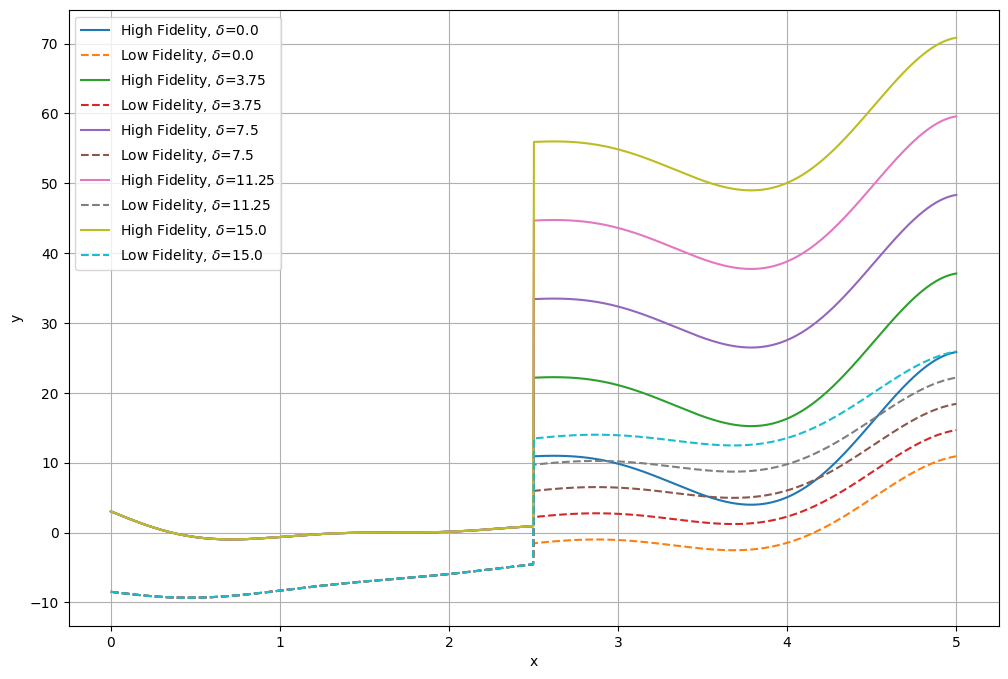

In [3]:
# Chosen example:
example="Discontinuous"
params = get_parameters(example)

x_values = np.linspace(0, 5, 1000)
# parameters 
deltas=params["deltas"]


plt.figure(figsize=(12, 8))
for delta in deltas:
    y_highfid = params["modified_highfid"](x_values,delta)
    y_lowfid = params["modified_lowfid"](x_values,delta)
    plt.plot(x_values, y_highfid, label=fr'High Fidelity, $\delta$={delta}')
    plt.plot(x_values, y_lowfid, label=fr'Low Fidelity, $\delta$={delta}', linestyle='--')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

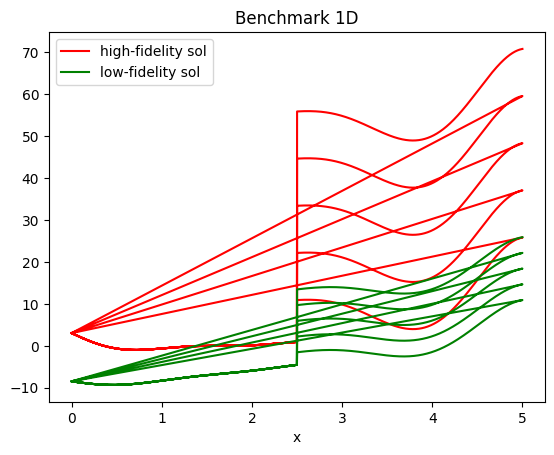

In [3]:
datahf= np.array(np.meshgrid(params["xhf"],deltas)).T.reshape(-1, 2)
ord_index = np.lexsort((datahf[:, 0], datahf[:, 1]))
datahf = datahf[ord_index]

datalf= np.array(np.meshgrid(params["xlf"],deltas)).T.reshape(-1, 2)
ord_index = np.lexsort((datalf[:, 0], datalf[:, 1]))
datalf = datalf[ord_index]

x_test = np.linspace(0,5,10000)
datatest= np.array(np.meshgrid(x_test,deltas)).T.reshape(-1, 2)
ord_index = np.lexsort((datatest[:, 0], datatest[:, 1]))
datatest = datatest[ord_index]

plt.figure()
plt.plot(datatest[:,0],params["modified_highfid"](datatest[:,0],datatest[:,1]),'r', label = 'high-fidelity sol')
plt.plot(datatest[:,0],params["modified_lowfid"](datatest[:,0],datatest[:,1]),'g', label = 'low-fidelity sol')
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

# Low Fidelity model

First model built with the use of Low Fidelity data




The function training took 12.034061908721924 seconds.


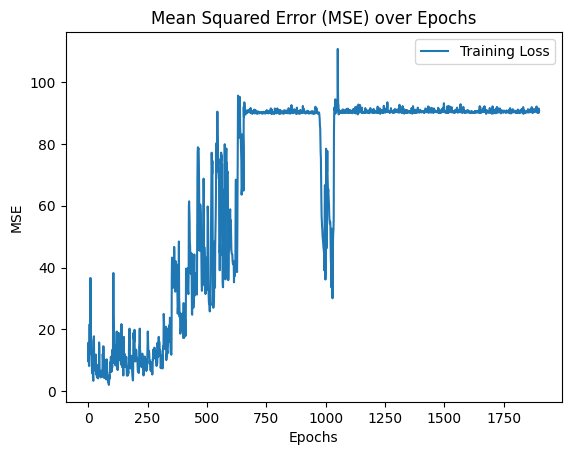

Test MSE: 697.3447278435988
R^2: -0.6470791638290372


Text(0.5, 1.0, 'Low fidelity model')

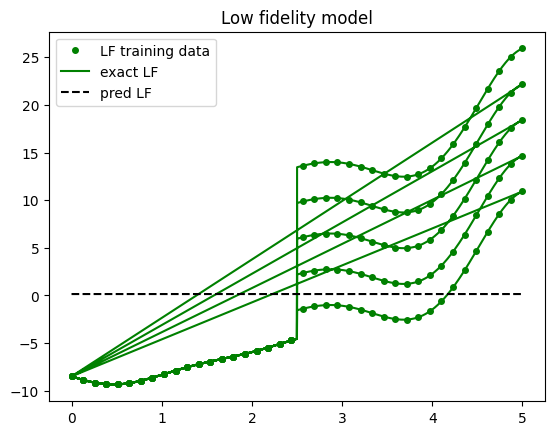

In [4]:
# parameters of the Neural Network
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
# building of the neural network
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=datalf,output_train=params["Ylf"],N=params["NepoLF"],n=params["Nlf"],train=True,do_HPO=False,verbose=False)
# prediction step
yLF=modelLF.prediction(datatest)
(mse_LF,R2_LF)=modelLF.performance(datatest,params["modified_highfid"](datatest[:,0],datatest[:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(datalf[:,0],params["Ylf"],'go', label = 'LF training data', markersize = 4)
plt.plot(datatest[:,0],params["modified_lowfid"](datatest[:,0],datatest[:,1]),'g', label = 'exact LF') 
plt.plot(datatest[:,0],yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

# High Fidelity model

Model built with the use of High Fidelity data

The function training took 30.871331453323364 seconds.


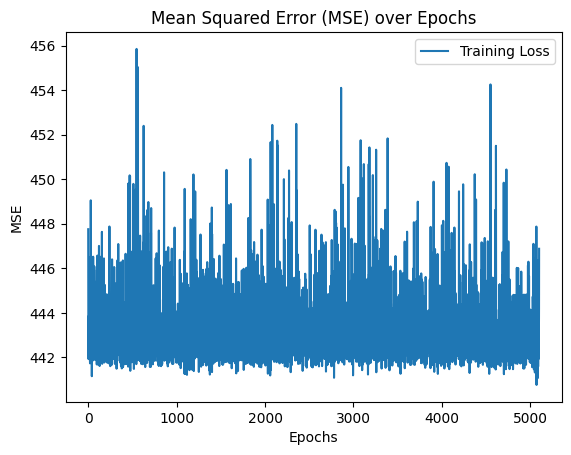

Test MSE: 423.3853328848127
R^2: -6.355854744732881e-06


Text(0.5, 1.0, 'High fidelity model - single-fidelity')

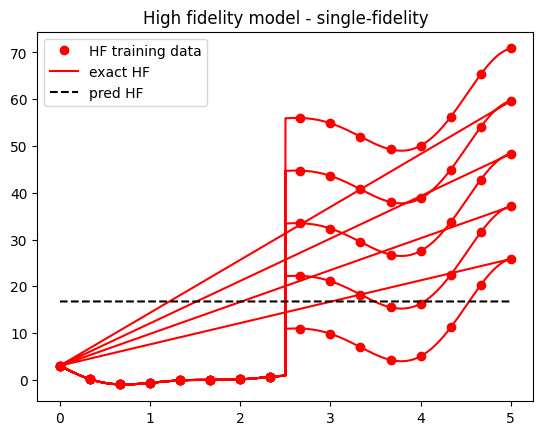

In [5]:
# parameters of the Neural Network
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
# building of the neural network
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=datahf,output_train=params["Yhf"],N=params["NepoHF"],n=params["Nhf"],train=True,do_HPO=False,verbose=False)
# prediction step
yHF=modelHF.prediction(datatest)
(mse_HF,R2_HF)=modelHF.performance(datatest,params["modified_highfid"](datatest[:,0],datatest[:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(datahf[:,0],params["Yhf"],'ro', label = 'HF training data')
plt.plot(datatest[:,0],params["modified_highfid"](datatest[:,0],datatest[:,1]),'-r', label = 'exact HF')
plt.plot(datatest[:,0],yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

# 2 step model

Here the Low fidelity and High fidelity data are use together subsequently 

The function training took 12.029802799224854 seconds.


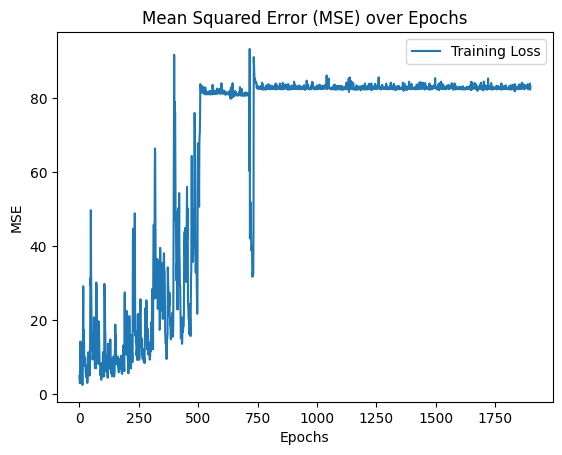

The function training took 23.585343599319458 seconds.


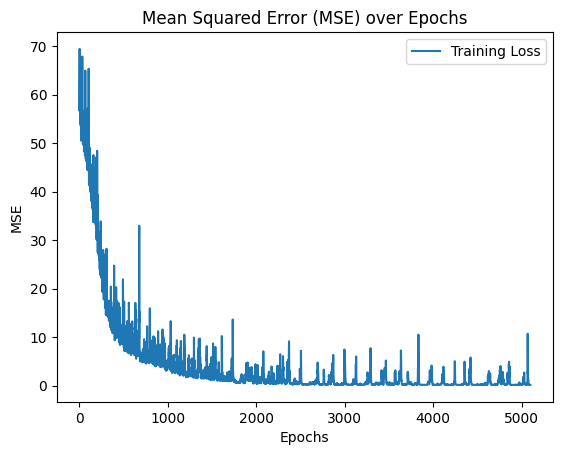

Test MSE: 7.523664246666331
R^2: 0.982229634610346


Text(0.5, 1.0, 'High fidelity model - 2-step')

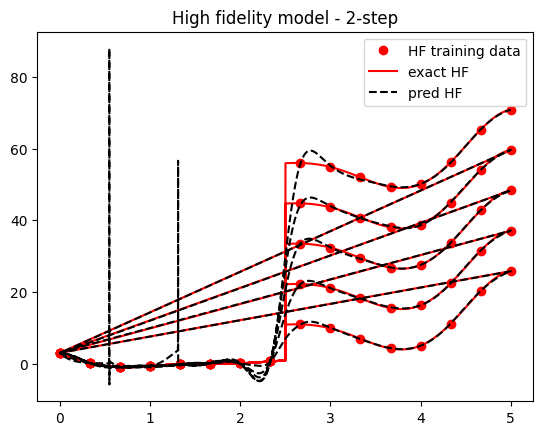

In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}

# The same epochs and training set size is used
N=[params["NepoLF"],params["NepoHF"]]
n=[params["Nlf"],params["Nhf"]]
names=['LF','HF']

params_2_step=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params_2_step,data_train=[datalf,datahf],output_train=[params["Ylf"],params["Yhf"]],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(datatest)

input_HF = np.concatenate(
                    (datatest,  final_model.model_list[0].prediction(datatest).reshape(-1,1)),axis=1
                ) 
(mse_MF,R2_MF)=final_model.model_list[1].performance(input_HF,params["modified_highfid"](datatest[:,0],datatest[:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(datahf[:,0],params["Yhf"],'ro', label = 'HF training data')
plt.plot(datatest[:,0],params["modified_highfid"](datatest[:,0],datatest[:,1]),'-r', label = 'exact HF')
plt.plot(datatest[:,0],y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# Inverse problem

Given the forward model provided by the neural newtork, stochastic methods are used to estimate the original parameter starting from the output

Noise: 0.1
Number of data: 30
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [02:16<00:00, 22.03it/s]


Sampling chain 2/2


Running chain, α = 0.32: 100%|██████████| 3000/3000 [02:19<00:00, 21.45it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [6.999]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.999  0.976   5.209    8.642      0.049    0.035     391.0     373.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [8.001]



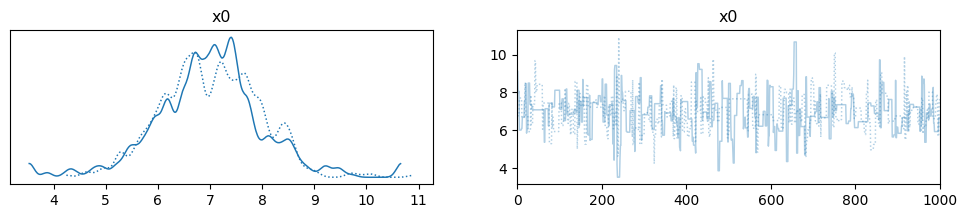

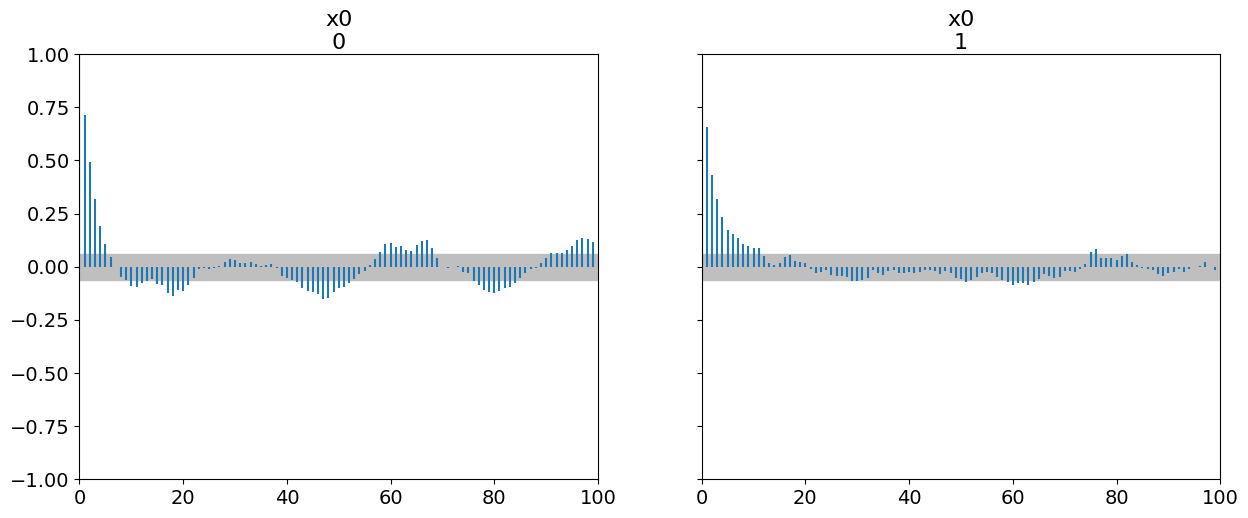

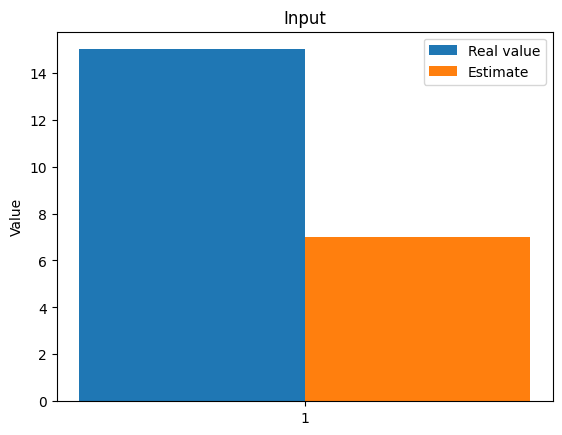

The function param_inverse took 276.55175614356995 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.20: 100%|█████████▉| 2985/3000 [02:29<00:00, 19.85it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.20: 100%|██████████| 3000/3000 [02:29<00:00, 20.00it/s]


Sampling chain 2/2


Running chain, α = 0.03: 100%|██████████| 3000/3000 [02:35<00:00, 19.29it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-4.465]
     mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -4.465  11.265 -15.772    8.193      7.844    6.602       3.0       9.0   

    r_hat  
x0   1.89  
Autocorrelation...
the difference between estimated values [19.465]



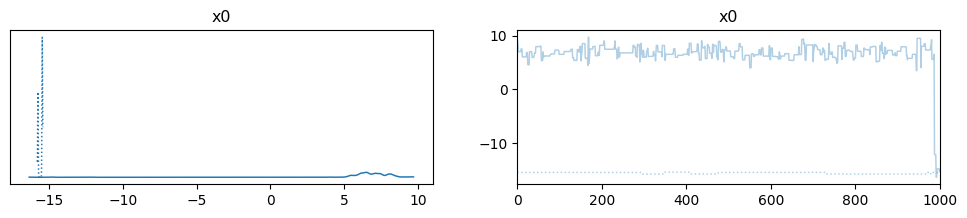

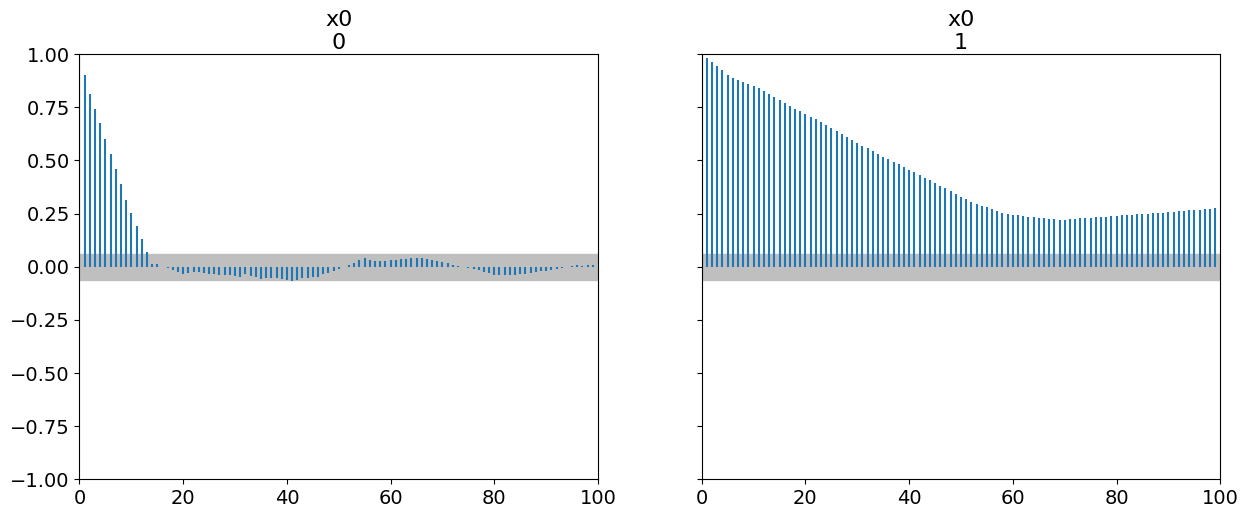

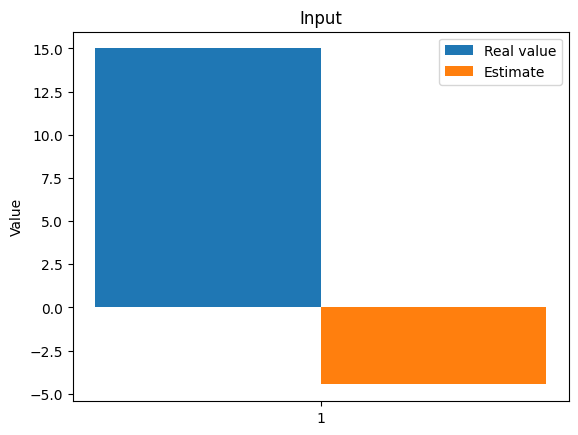

The function param_inverse took 306.11158752441406 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.28:  46%|████▌     | 1366/3000 [01:10<01:29, 18.18it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.12: 100%|██████████| 3000/3000 [02:35<00:00, 19.24it/s]


Sampling chain 2/2


Running chain, α = 0.04: 100%|██████████| 3000/3000 [02:35<00:00, 19.28it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-15.534]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -15.534  0.138 -15.763  -15.418      0.018    0.013      49.0      27.0   

    r_hat  
x0   1.04  
Autocorrelation...
the difference between estimated values [30.534]



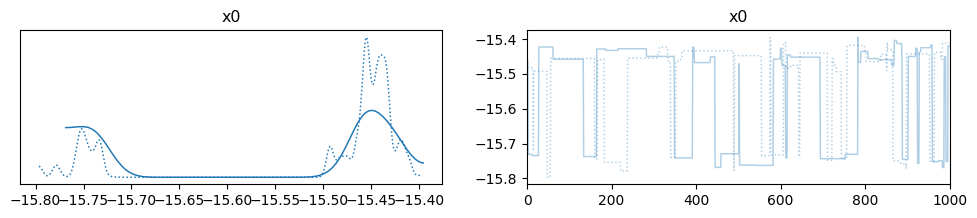

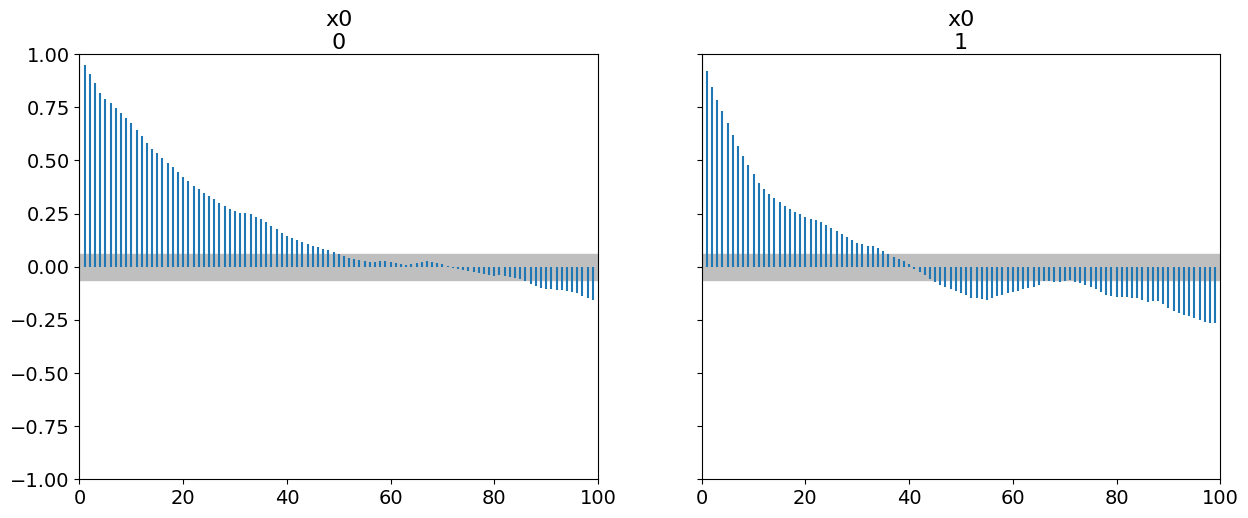

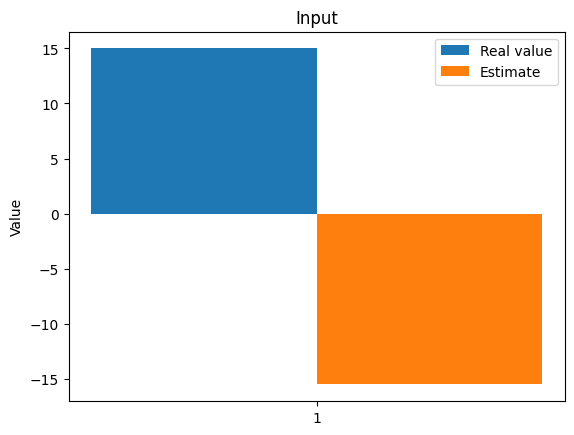

The function param_inverse took 312.19545459747314 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [03:21<00:00, 14.90it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [04:43<00:00, 10.57it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [7.004]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.004  0.938   5.333     8.66      0.055    0.039     292.0     366.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [7.996]



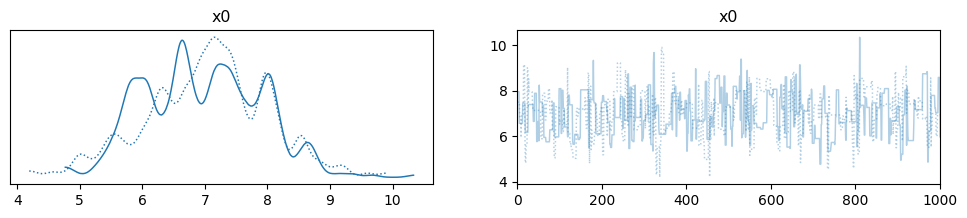

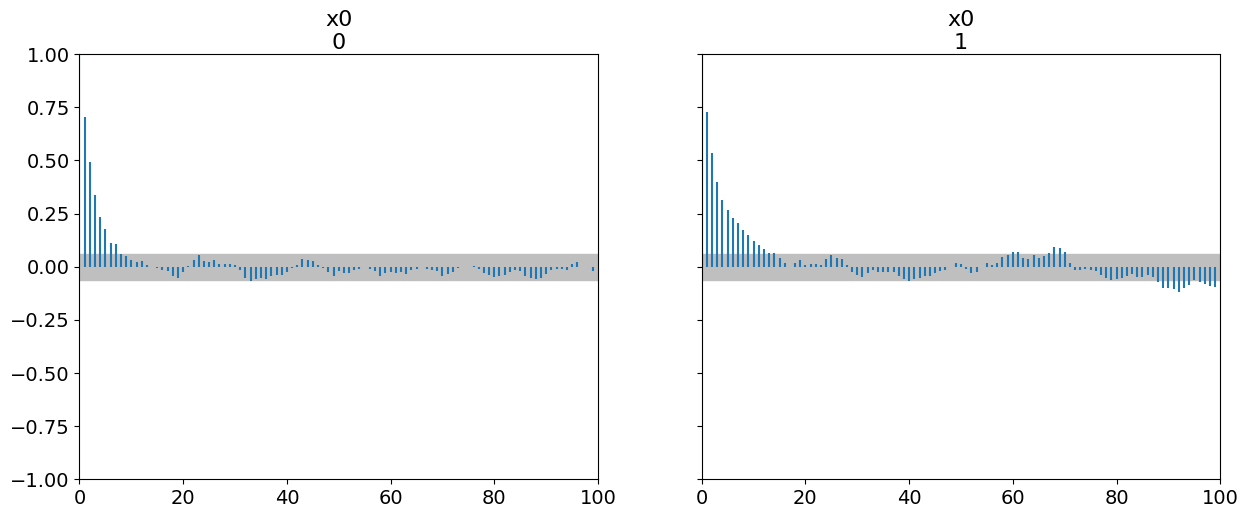

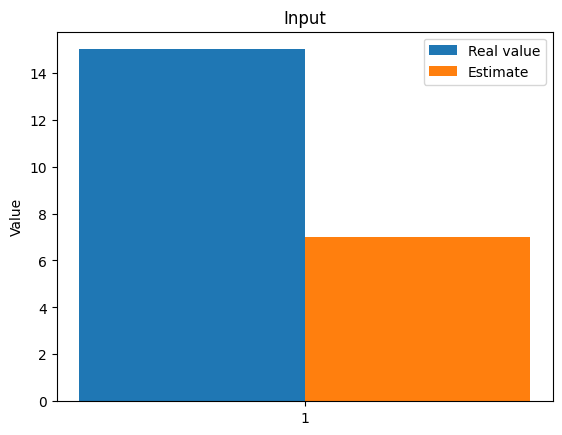

The function param_inverse took 486.3641939163208 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:31<00:00, 11.06it/s]


Sampling chain 2/2


Running chain, α = 0.11: 100%|██████████| 3000/3000 [04:26<00:00, 11.26it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [7.064]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.064  1.044   4.903    8.862      0.058    0.041     327.0     328.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [7.936]



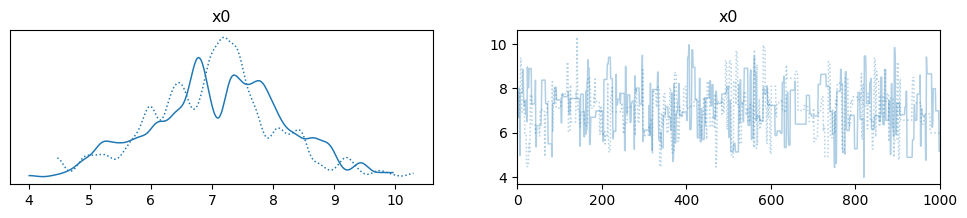

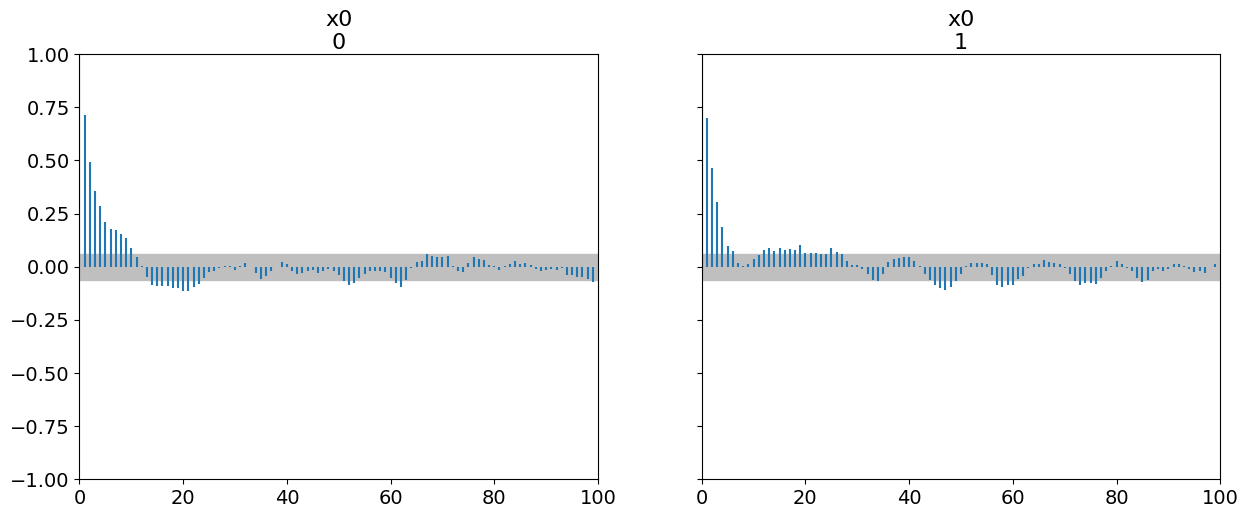

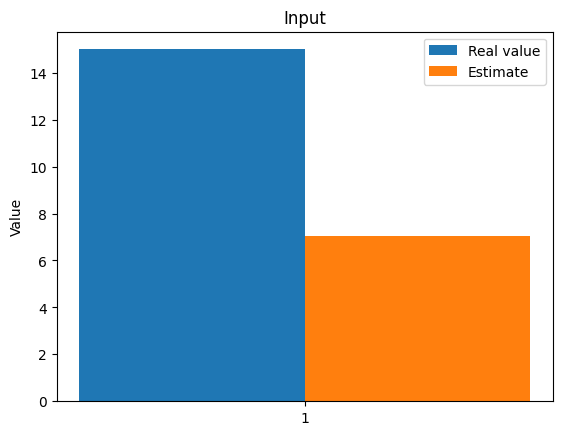

The function param_inverse took 538.5960416793823 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [04:26<00:00, 11.25it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [04:25<00:00, 11.28it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [6.936]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.936  1.045   5.171    8.997      0.058    0.041     319.0     383.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [8.064]



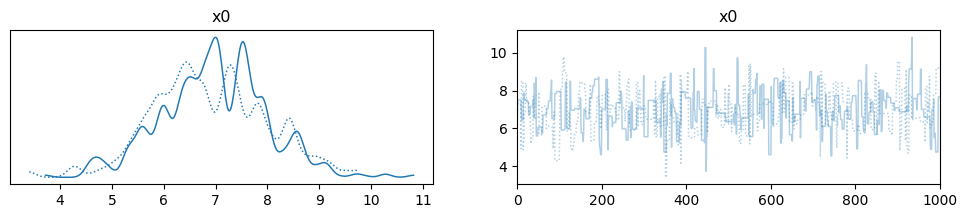

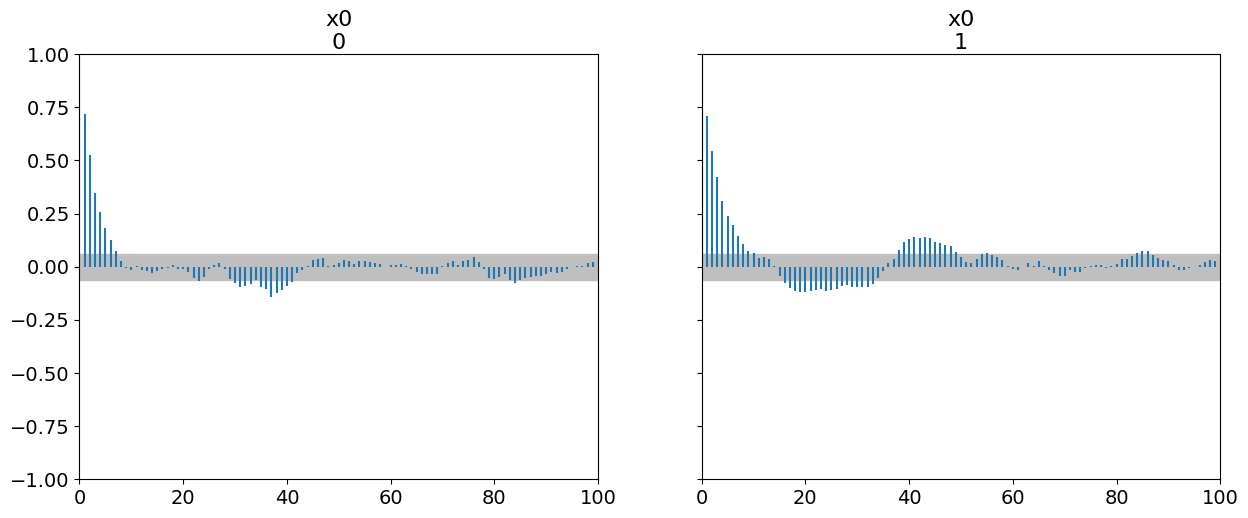

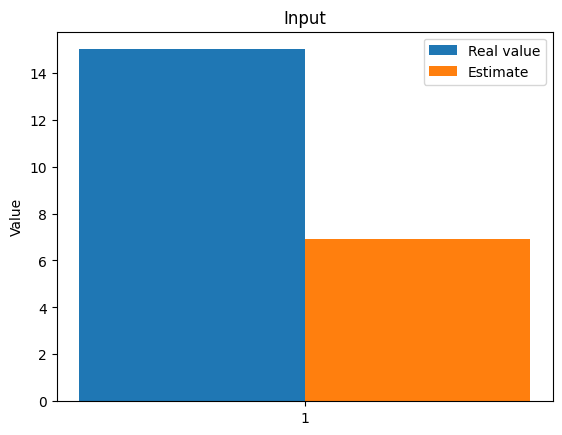

The function param_inverse took 533.5887229442596 seconds.
Number of data: 50
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:45<00:00, 10.51it/s]


Sampling chain 2/2


Running chain, α = 0.21:  96%|█████████▌| 2867/3000 [04:29<00:12, 11.04it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.02: 100%|██████████| 3000/3000 [04:42<00:00, 10.63it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [5.556]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.556  5.684 -15.483    8.695      1.965    1.441      36.0      10.0   

    r_hat  
x0   1.06  
Autocorrelation...
the difference between estimated values [9.444]



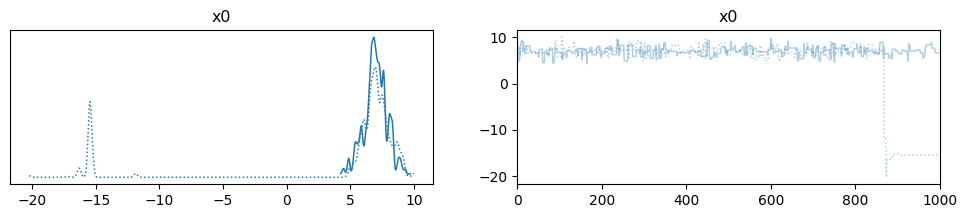

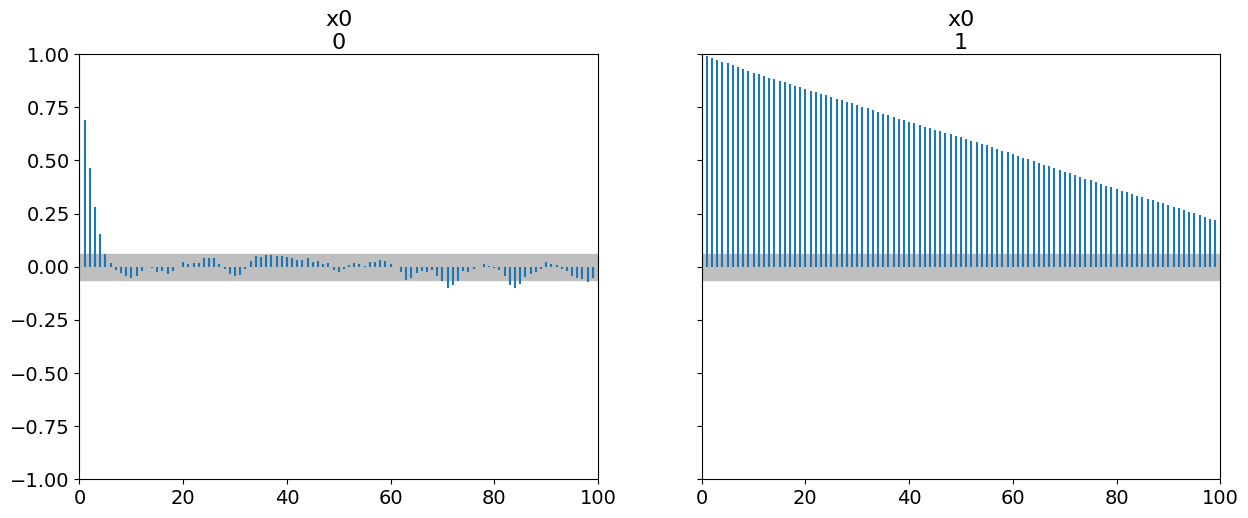

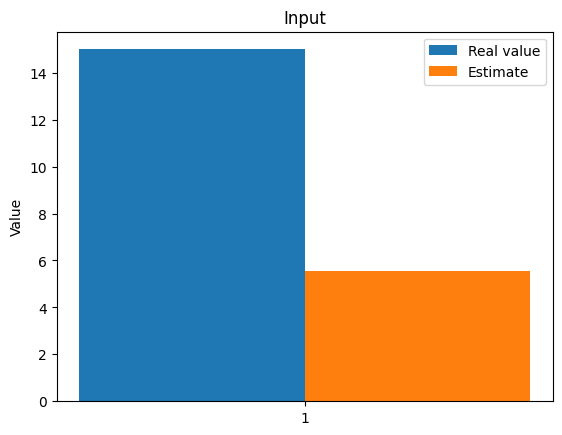

The function param_inverse took 569.0087900161743 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [04:40<00:00, 10.70it/s]


Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [04:40<00:00, 10.68it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [6.928]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.928  1.032   4.889    8.754      0.055    0.039     357.0     214.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [8.072]



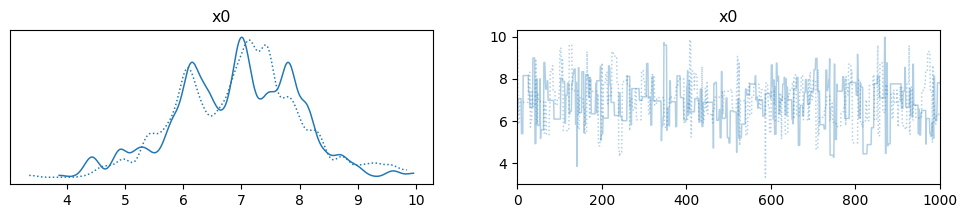

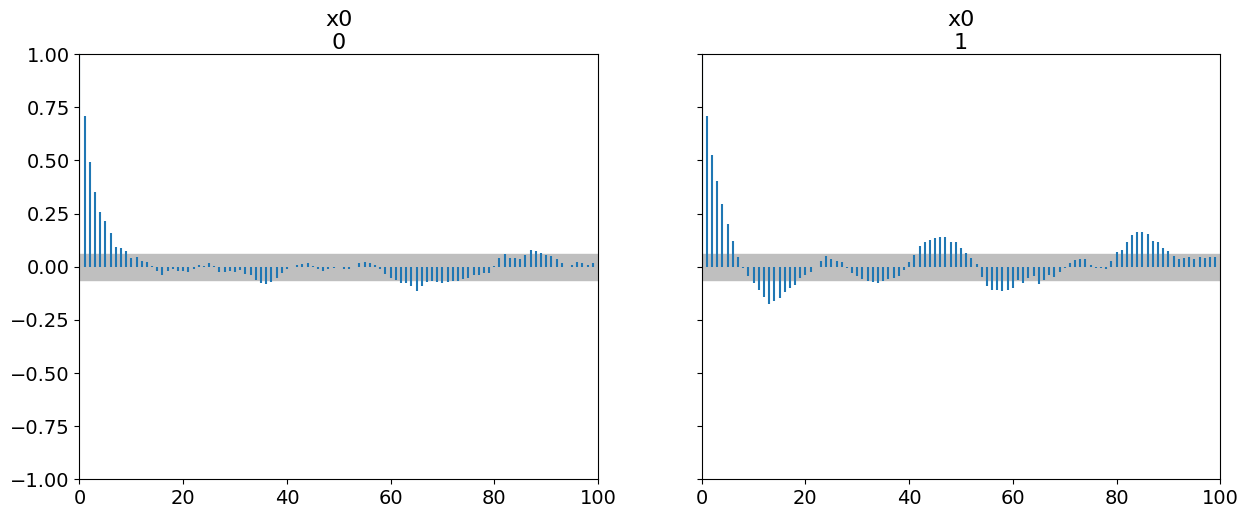

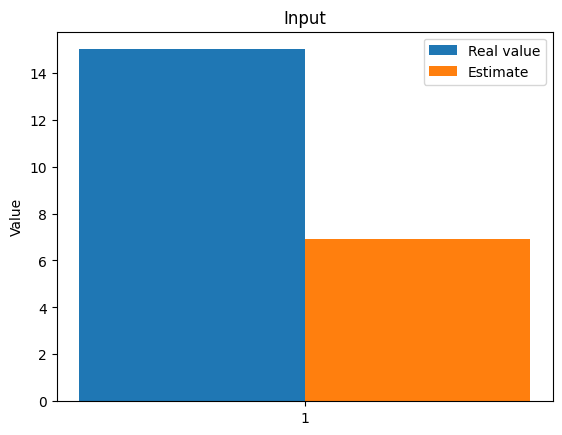

The function param_inverse took 562.4413957595825 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24:  98%|█████████▊| 2938/3000 [04:35<00:06, 10.12it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.17: 100%|██████████| 3000/3000 [04:42<00:00, 10.63it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [04:41<00:00, 10.66it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [6.28]
    mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
x0  6.28  3.99   5.016    9.245      0.965    0.694     106.0      31.0   1.05
Autocorrelation...
the difference between estimated values [8.72]



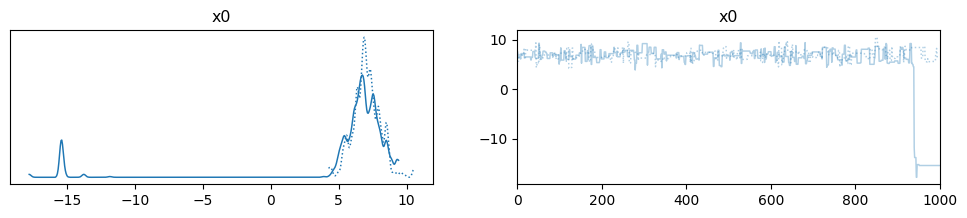

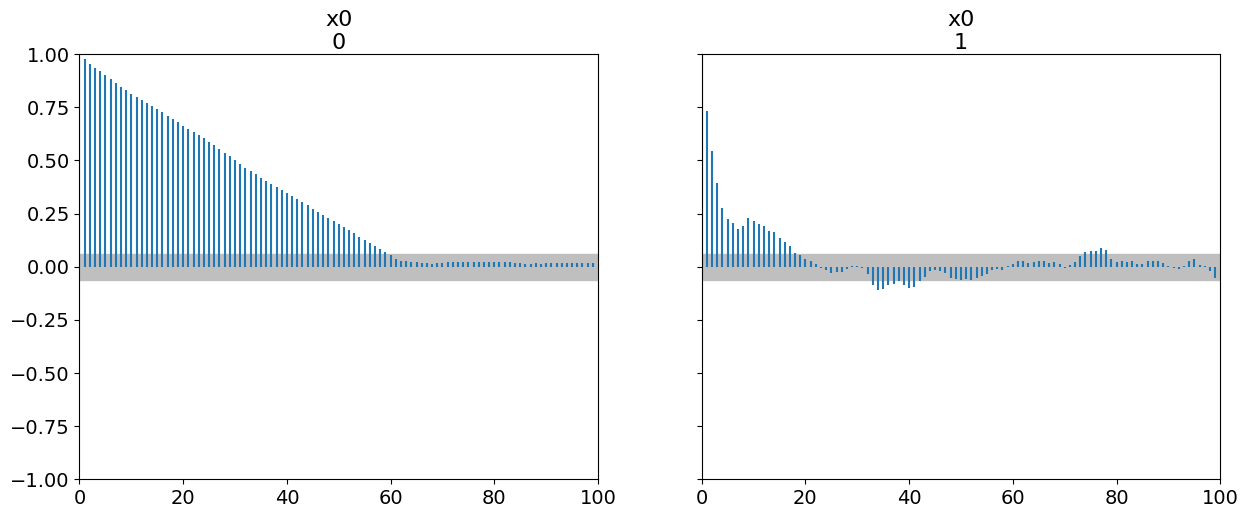

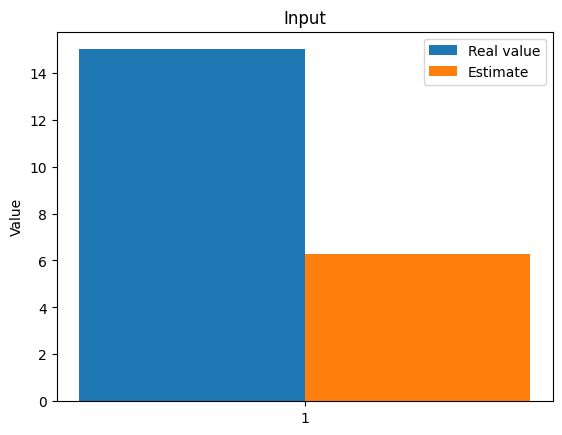

The function param_inverse took 564.6167917251587 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.20:  66%|██████▌   | 1972/3000 [03:04<01:34, 10.89it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.12: 100%|██████████| 3000/3000 [04:40<00:00, 10.68it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:40<00:00, 10.70it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-4.198]
     mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -4.198  11.141  -15.46    7.865      7.834    6.623       3.0      11.0   

    r_hat  
x0   1.85  
Autocorrelation...
the difference between estimated values [19.198]



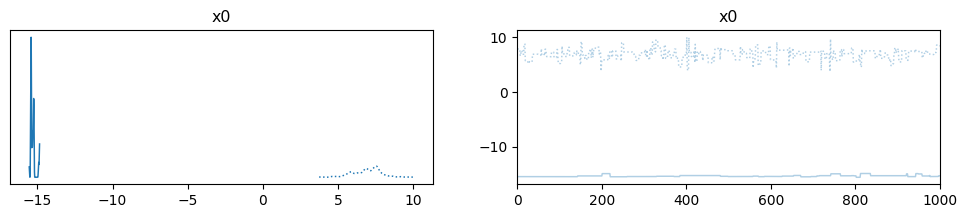

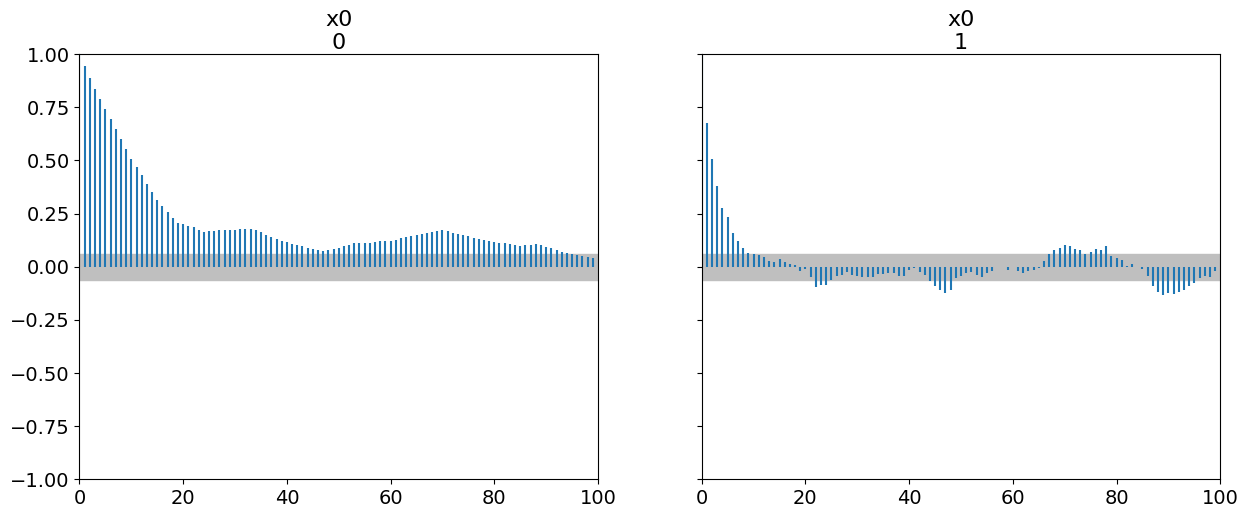

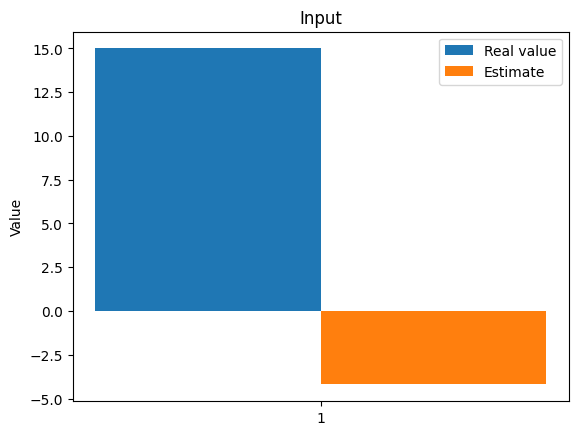

The function param_inverse took 562.1987609863281 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [04:41<00:00, 10.68it/s]


Sampling chain 2/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [04:40<00:00, 10.71it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [7.078]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.078  0.962   5.297    8.895      0.053    0.038     332.0     252.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [7.922]



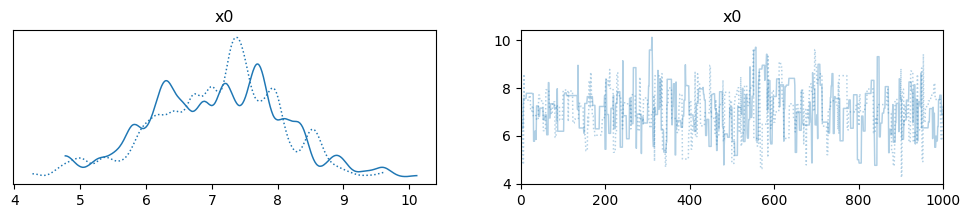

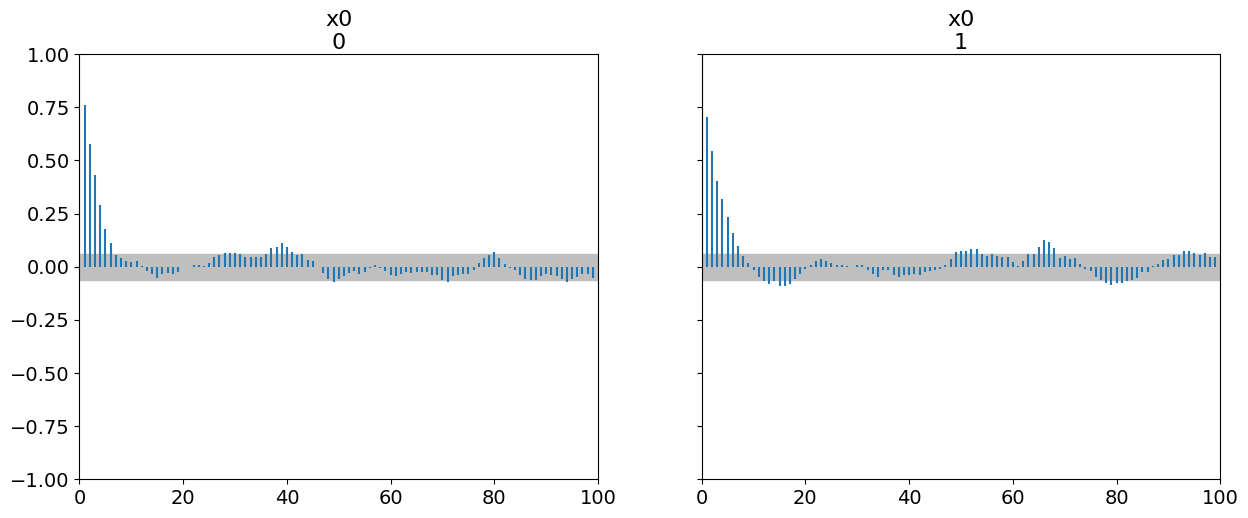

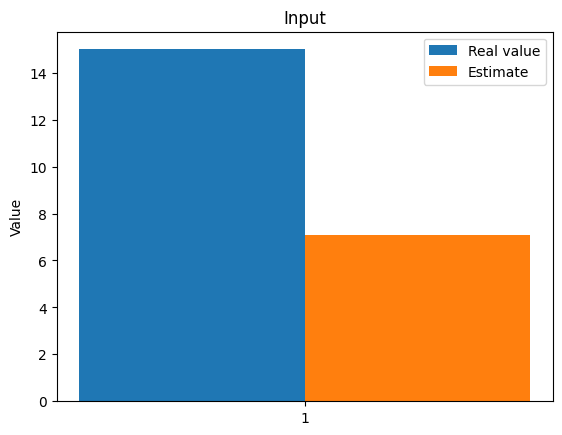

The function param_inverse took 562.2376620769501 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:38<00:00, 10.77it/s]


Sampling chain 2/2


Running chain, α = 0.14: 100%|██████████| 3000/3000 [04:39<00:00, 10.74it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [7.041]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.041  1.017   5.175     8.96      0.061    0.043     281.0     400.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [7.959]



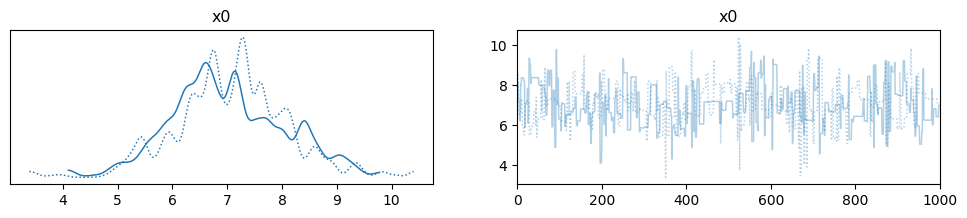

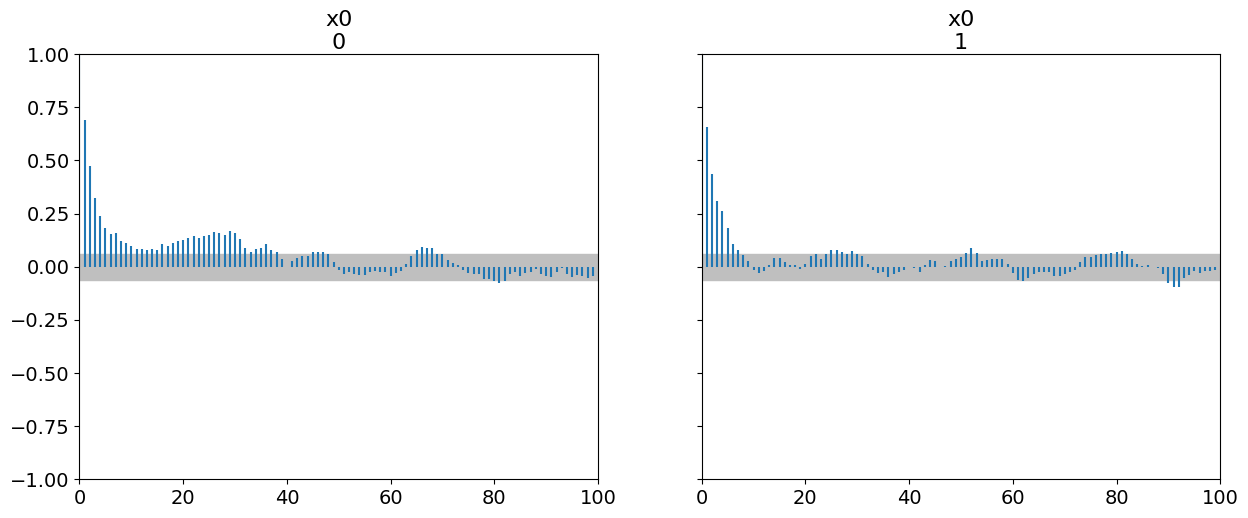

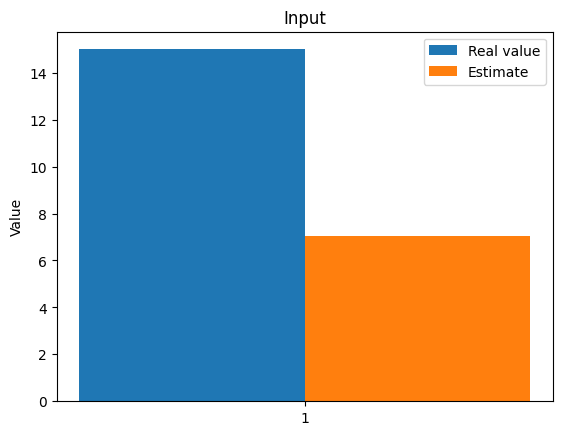

The function param_inverse took 558.7272069454193 seconds.
The best estimate is given by: sigma_noise=0.05, number of data= 30, sigma=2.0, rmwh_scaling=0.5
Noise: 0.05
Number of data: 30
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:25<00:00, 11.31it/s]


Sampling chain 2/2


Running chain, α = 0.28:  25%|██▍       | 748/3000 [01:06<03:16, 11.46it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.16: 100%|██████████| 3000/3000 [04:36<00:00, 10.86it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-4.24]
    mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -4.24  11.314 -15.772    8.304      7.952    6.721       3.0     101.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [19.24]



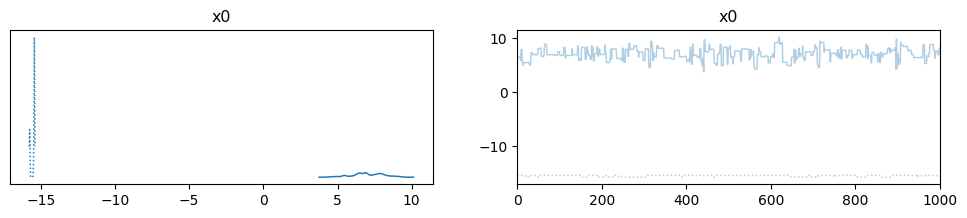

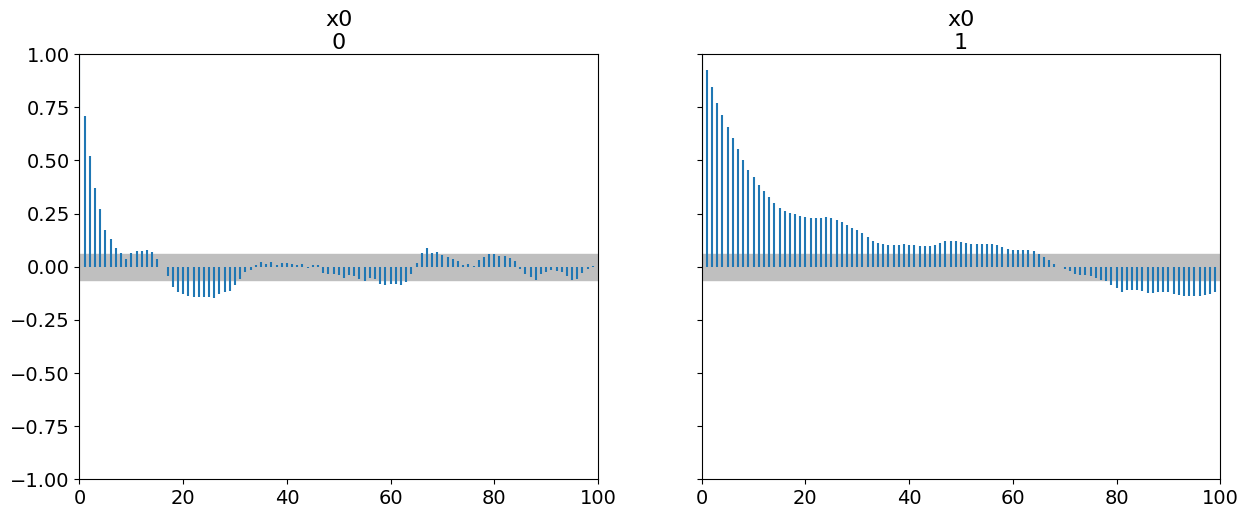

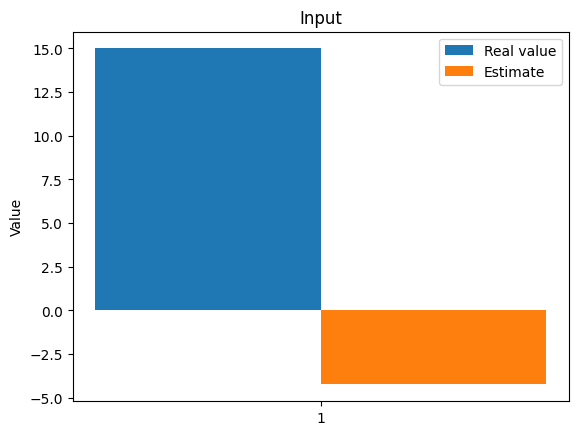

The function param_inverse took 542.6881997585297 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:44<00:00, 10.56it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:39<00:00, 10.72it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [7.02]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.02  1.002   5.166    8.799      0.053    0.038     344.0     296.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [7.98]



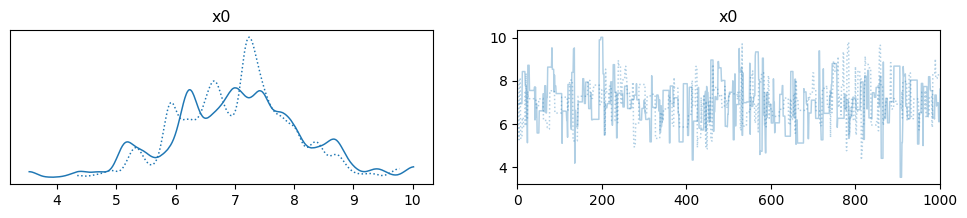

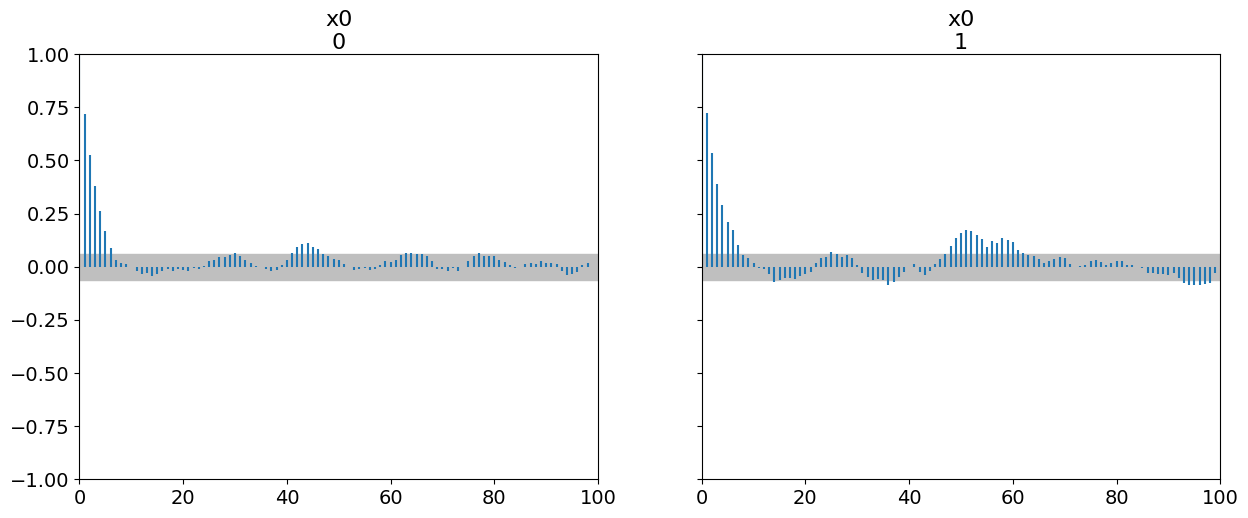

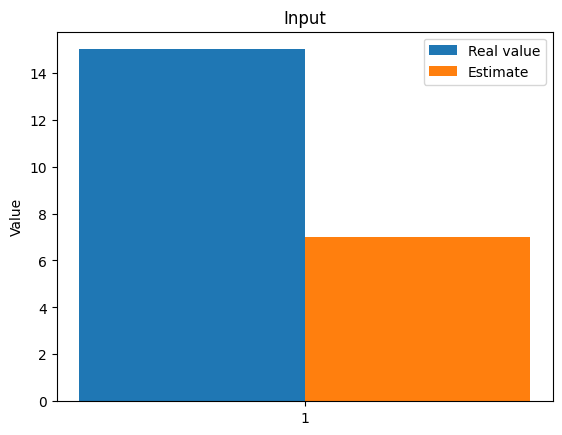

The function param_inverse took 565.0924301147461 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21:  87%|████████▋ | 2599/3000 [03:54<00:35, 11.30it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.00: 100%|██████████| 3000/3000 [04:31<00:00, 11.04it/s]


Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 3000/3000 [04:36<00:00, 10.84it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.559]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.559  9.121 -15.941    8.481      5.702    4.609       6.0       9.0   

    r_hat  
x0   1.32  
Autocorrelation...
the difference between estimated values [12.441]



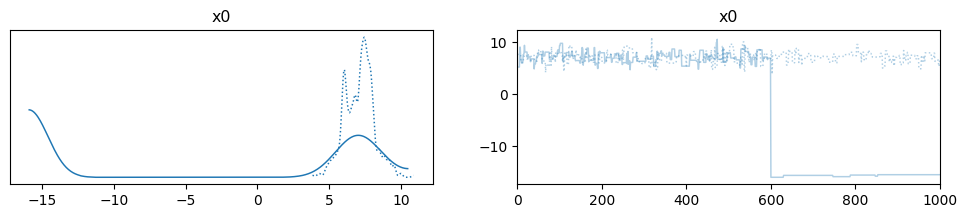

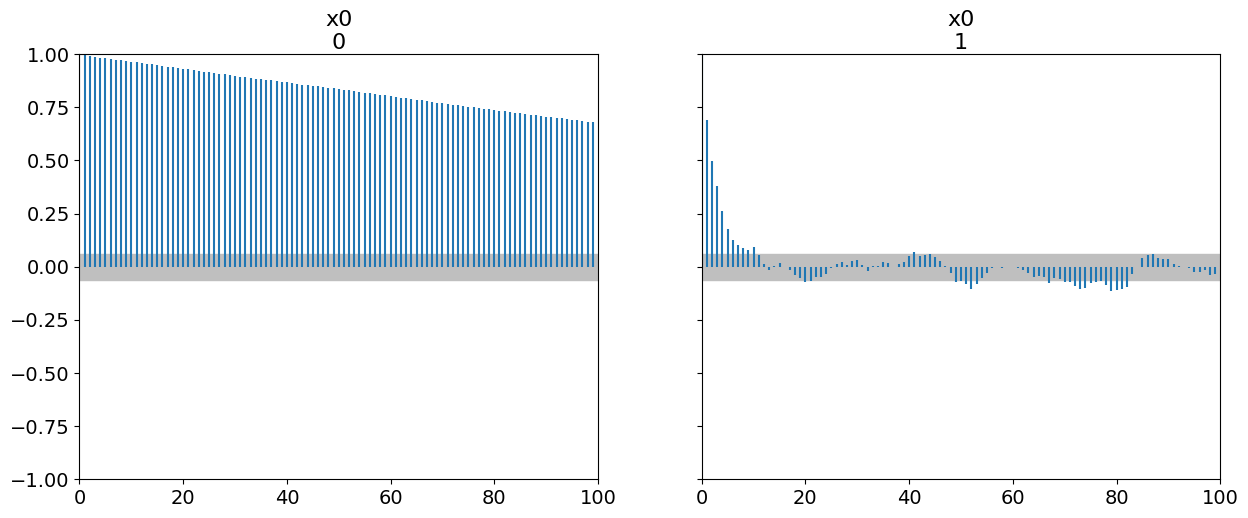

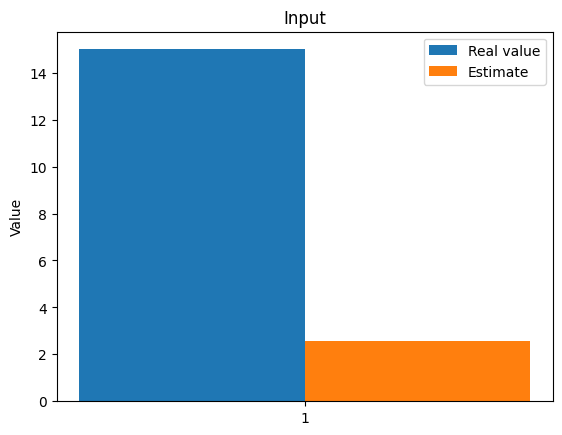

The function param_inverse took 549.8489277362823 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.26: 100%|██████████| 3000/3000 [04:32<00:00, 11.01it/s]


Sampling chain 2/2


Running chain, α = 0.32: 100%|██████████| 3000/3000 [04:27<00:00, 11.21it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [6.992]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.992  0.953   5.505    9.037      0.054    0.039     315.0     367.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [8.008]



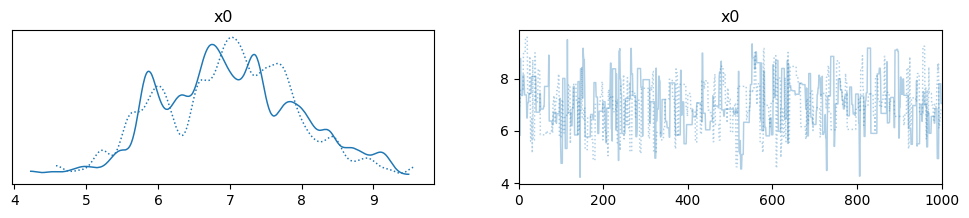

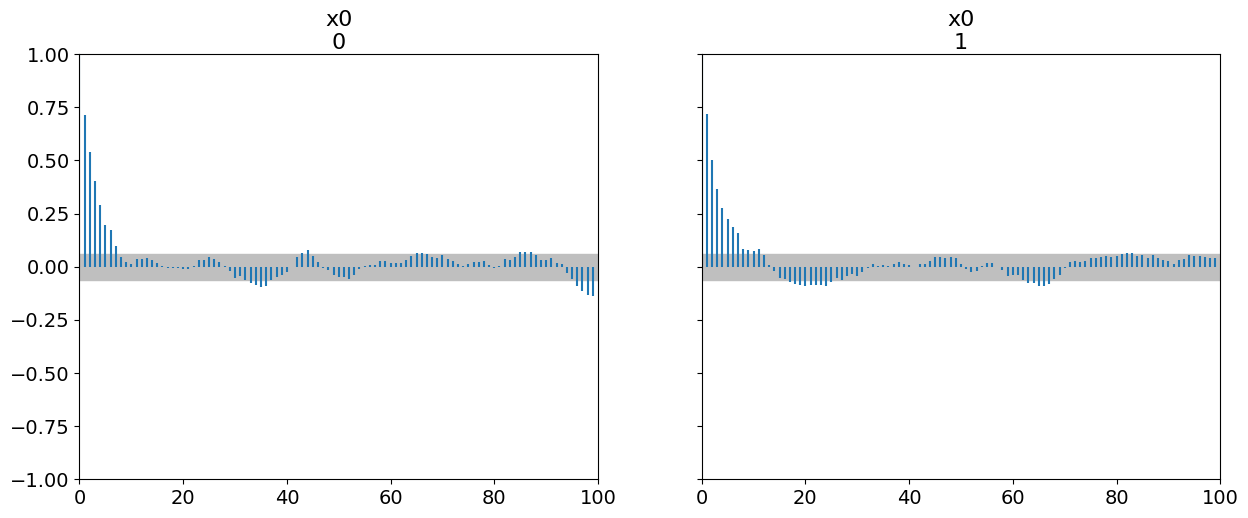

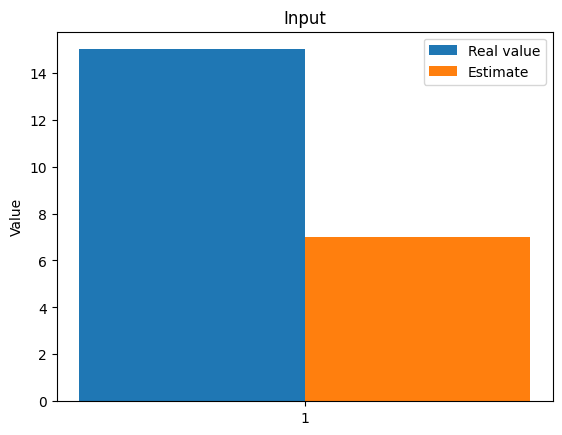

The function param_inverse took 541.3199918270111 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.22:  85%|████████▌ | 2562/3000 [03:48<00:40, 10.87it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.06: 100%|██████████| 3000/3000 [04:26<00:00, 11.24it/s]


Sampling chain 2/2


Running chain, α = 0.31: 100%|██████████| 3000/3000 [04:27<00:00, 11.20it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.171]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.171  9.046 -15.112    8.821      5.908    4.847       4.0      12.0   

    r_hat  
x0   1.45  
Autocorrelation...
the difference between estimated values [12.829]



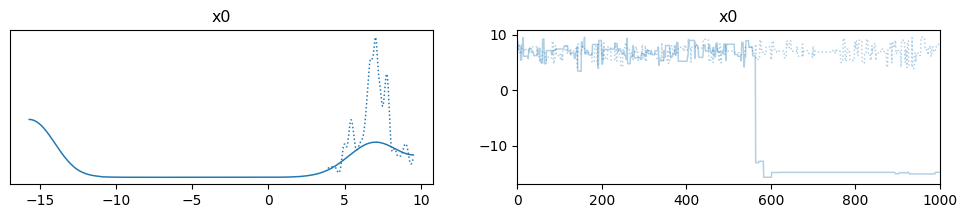

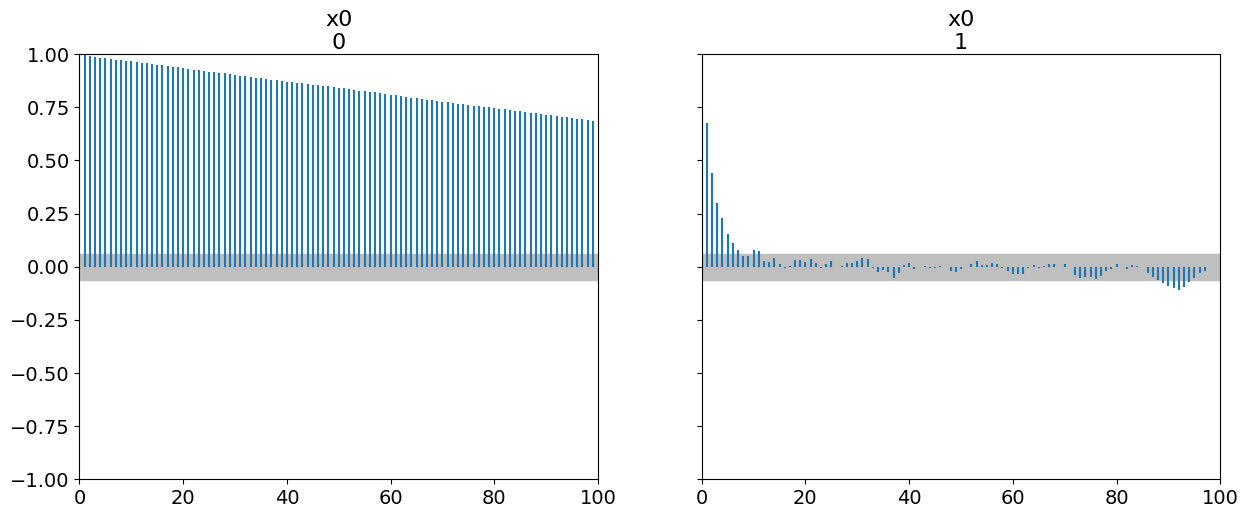

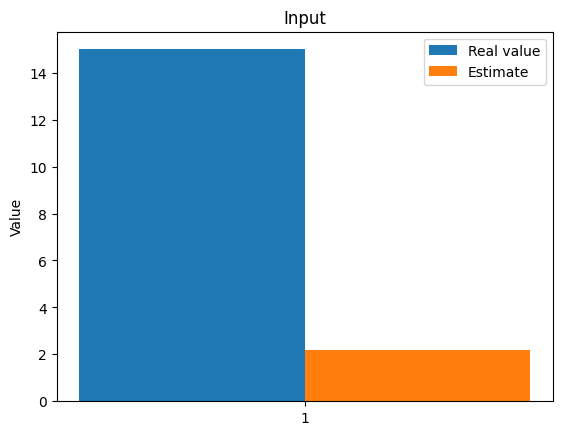

The function param_inverse took 536.0750317573547 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.10: 100%|██████████| 3000/3000 [04:27<00:00, 11.22it/s]


Sampling chain 2/2


Running chain, α = 0.17:  97%|█████████▋| 2903/3000 [04:19<00:08, 10.96it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.04: 100%|██████████| 3000/3000 [04:28<00:00, 11.17it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-5.116]
     mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -5.116  10.901 -15.482    7.915      7.161    5.888       4.0     116.0   

    r_hat  
x0   1.83  
Autocorrelation...
the difference between estimated values [20.116]



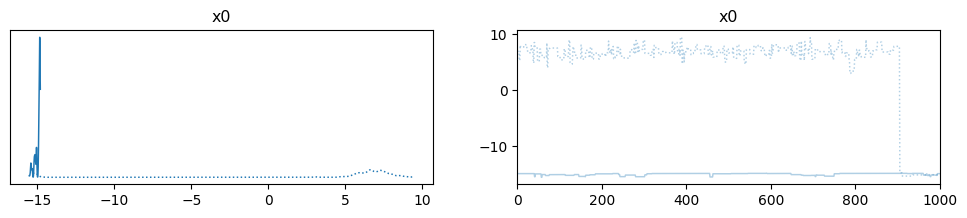

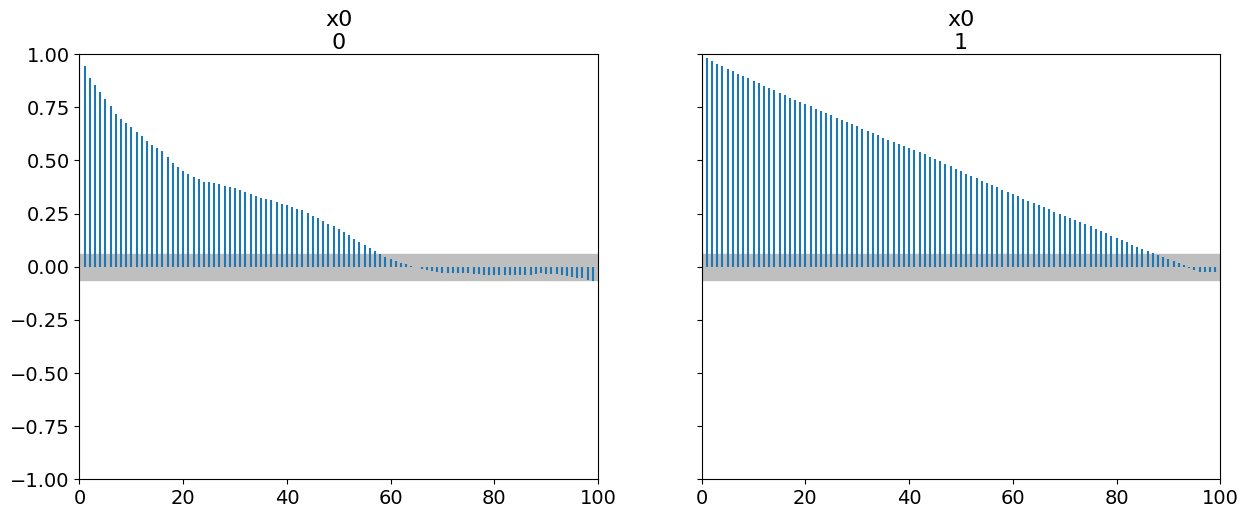

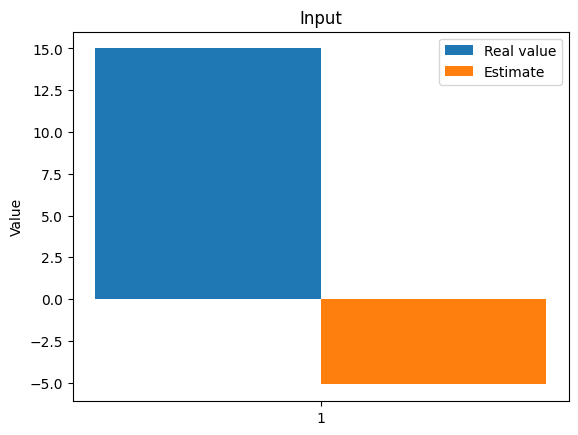

The function param_inverse took 536.8992419242859 seconds.
Number of data: 50
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [04:56<00:00, 10.10it/s]


Sampling chain 2/2


Running chain, α = 0.22:  53%|█████▎    | 1583/3000 [02:38<02:17, 10.29it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.02: 100%|██████████| 3000/3000 [04:37<00:00, 10.80it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-4.2]
    mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  -4.2  11.257 -15.497    8.096      7.916    6.692       3.0      12.0   

    r_hat  
x0   1.99  
Autocorrelation...
the difference between estimated values [19.2]



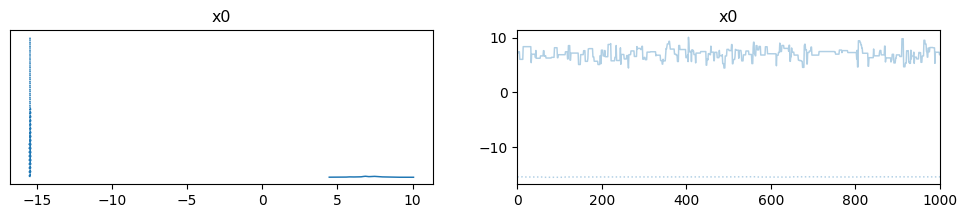

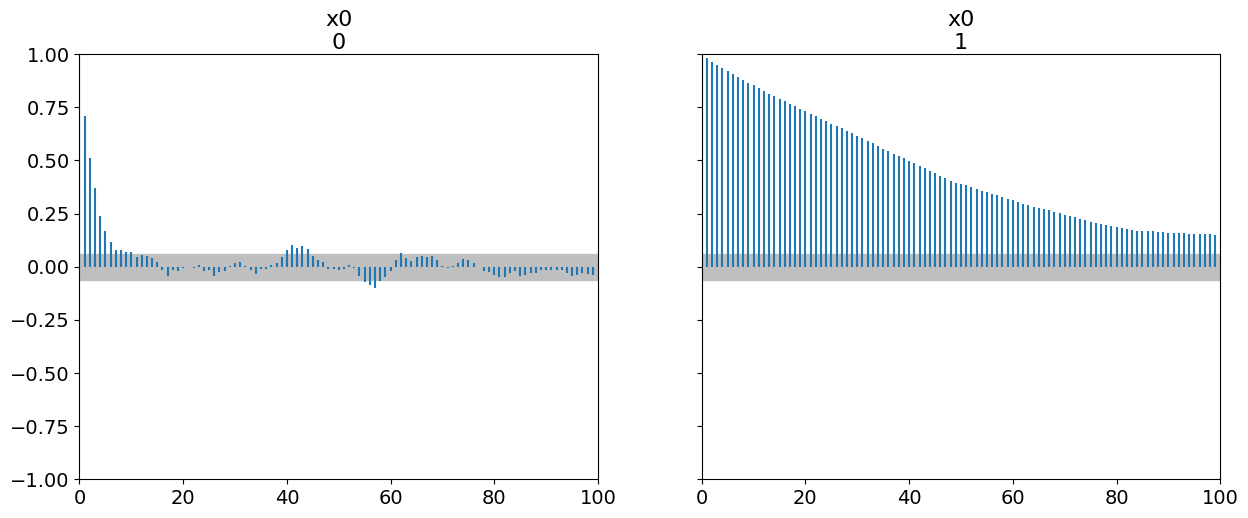

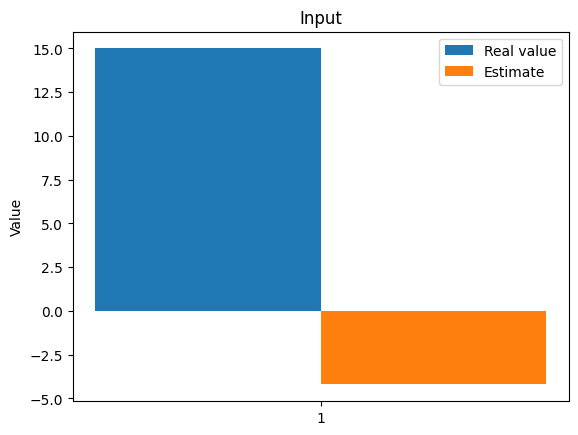

The function param_inverse took 575.9533758163452 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.26: 100%|██████████| 3000/3000 [04:44<00:00, 10.53it/s]


Sampling chain 2/2


Running chain, α = 0.33:  96%|█████████▌| 2873/3000 [04:24<00:11, 10.87it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.01: 100%|██████████| 3000/3000 [04:37<00:00, 10.83it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [5.613]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.613  5.533 -15.419    8.684      1.794    1.357      60.0       9.0   

    r_hat  
x0   1.04  
Autocorrelation...
the difference between estimated values [9.387]



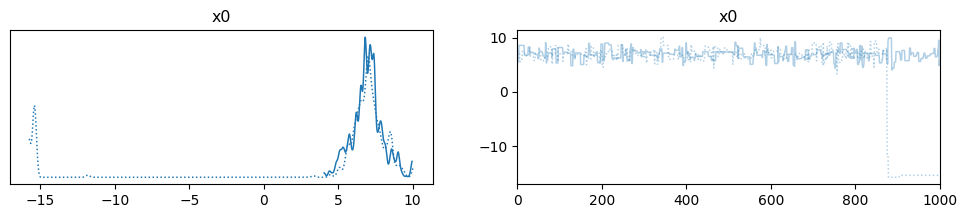

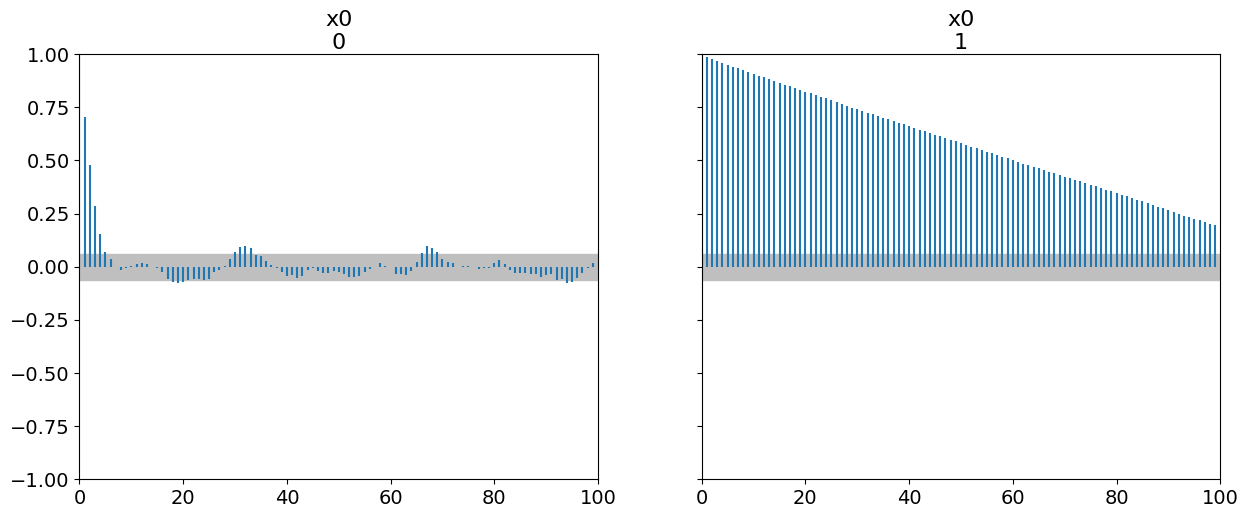

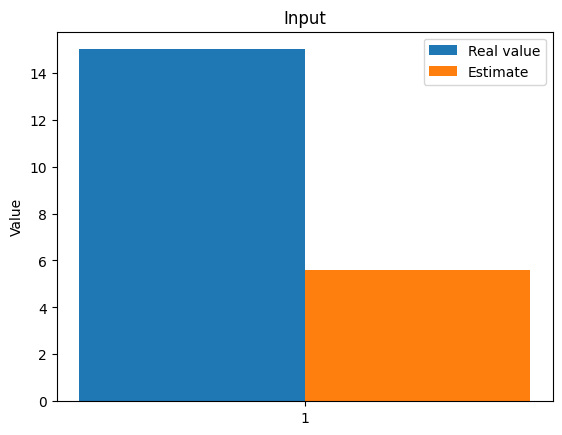

The function param_inverse took 563.0730838775635 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.28:  81%|████████  | 2429/3000 [03:43<00:49, 11.59it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.01: 100%|██████████| 3000/3000 [04:37<00:00, 10.82it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [04:36<00:00, 10.87it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.652]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.652  10.19  -15.44    8.607      6.725    5.538       4.0      13.0   

    r_hat  
x0   1.56  
Autocorrelation...
the difference between estimated values [14.348]



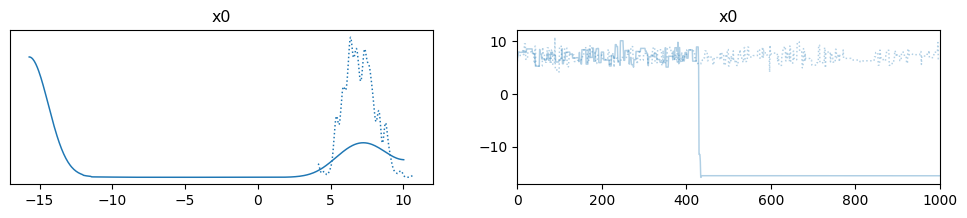

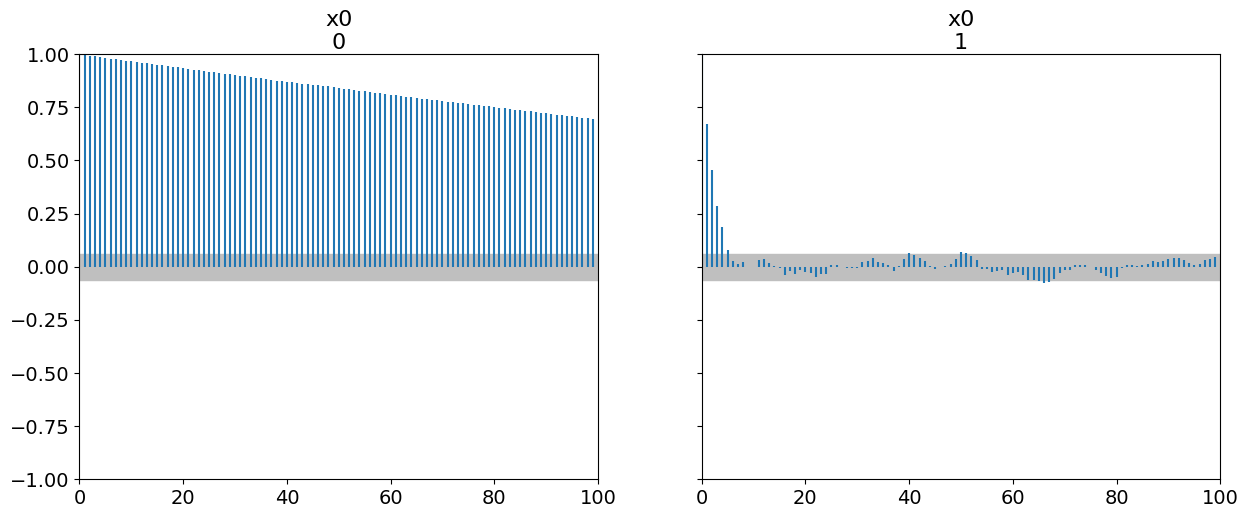

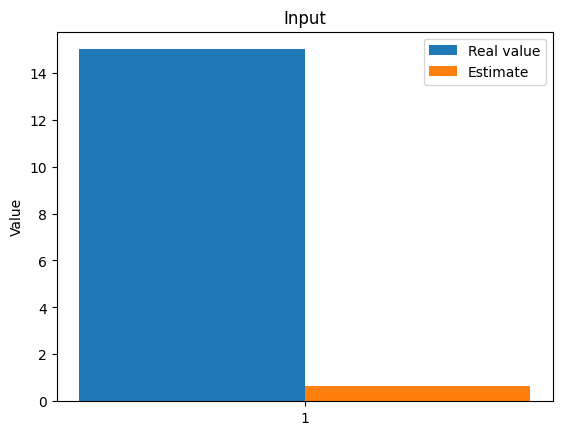

The function param_inverse took 554.5606842041016 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:35<00:00, 10.88it/s]


Sampling chain 2/2


Running chain, α = 0.28: 100%|██████████| 3000/3000 [04:35<00:00, 10.88it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [6.959]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.959  0.991   5.077    8.643      0.059    0.042     290.0     254.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [8.041]



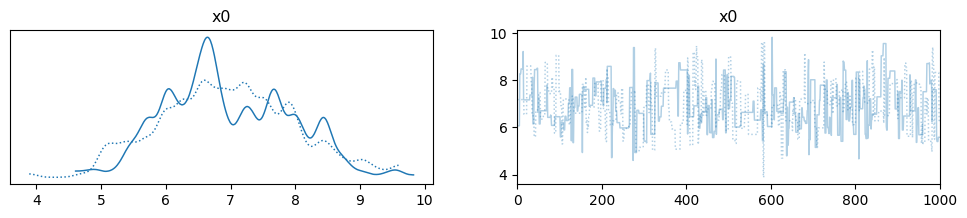

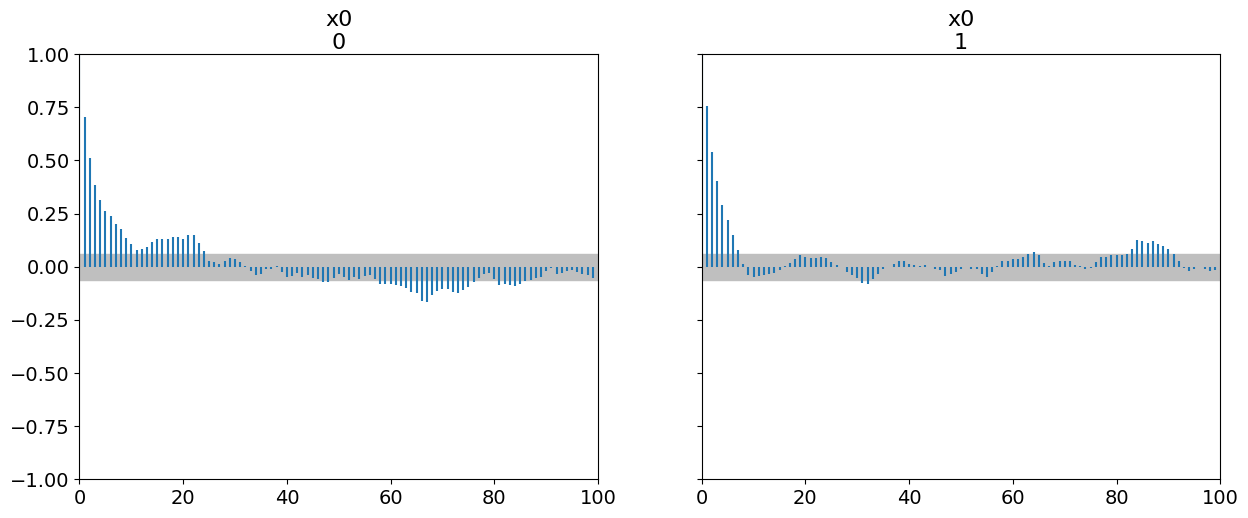

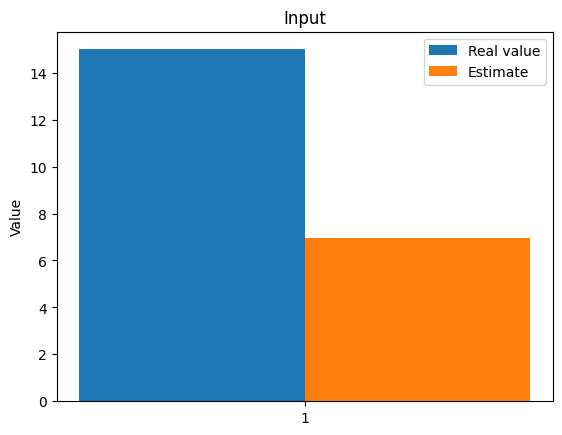

The function param_inverse took 552.5919773578644 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [04:36<00:00, 10.86it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:38<00:00, 10.77it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [7.008]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.008  0.924   5.405    8.771      0.051    0.036     328.0     364.0   

    r_hat  
x0   1.04  
Autocorrelation...
the difference between estimated values [7.992]



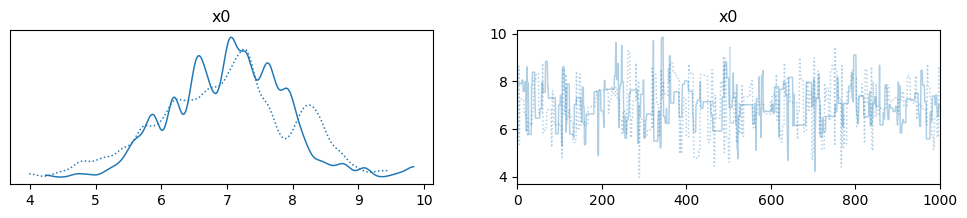

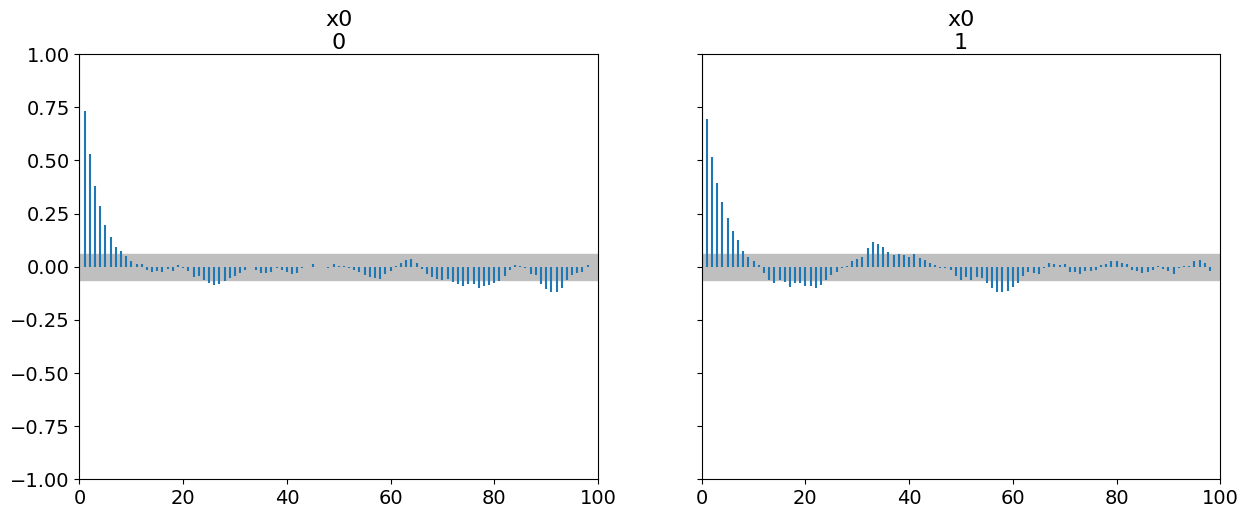

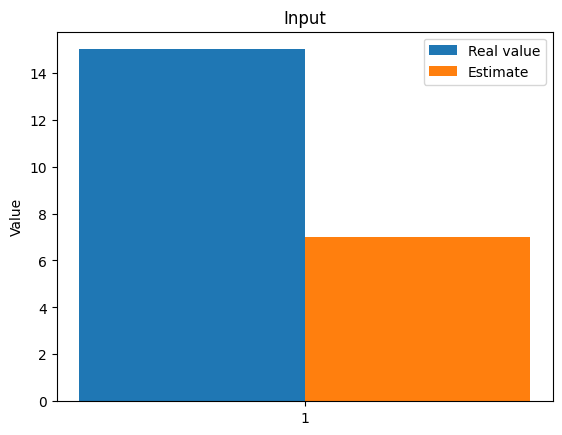

The function param_inverse took 556.5817046165466 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.29:  95%|█████████▌| 2864/3000 [04:22<00:13, 10.33it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.04: 100%|██████████| 3000/3000 [04:34<00:00, 10.92it/s]


Sampling chain 2/2


Running chain, α = 0.14: 100%|██████████| 3000/3000 [04:32<00:00, 10.99it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-5.58]
    mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -5.58  11.122 -15.501    8.253      7.135    5.816       4.0     170.0   

    r_hat  
x0   1.55  
Autocorrelation...
the difference between estimated values [20.58]



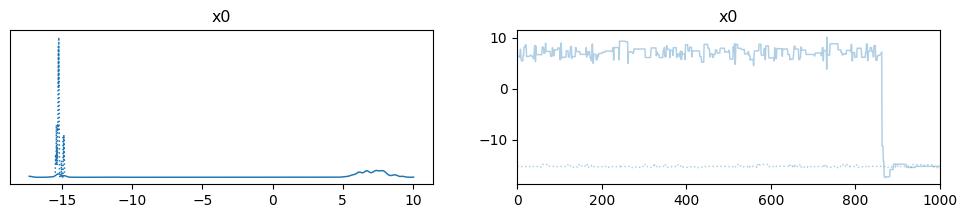

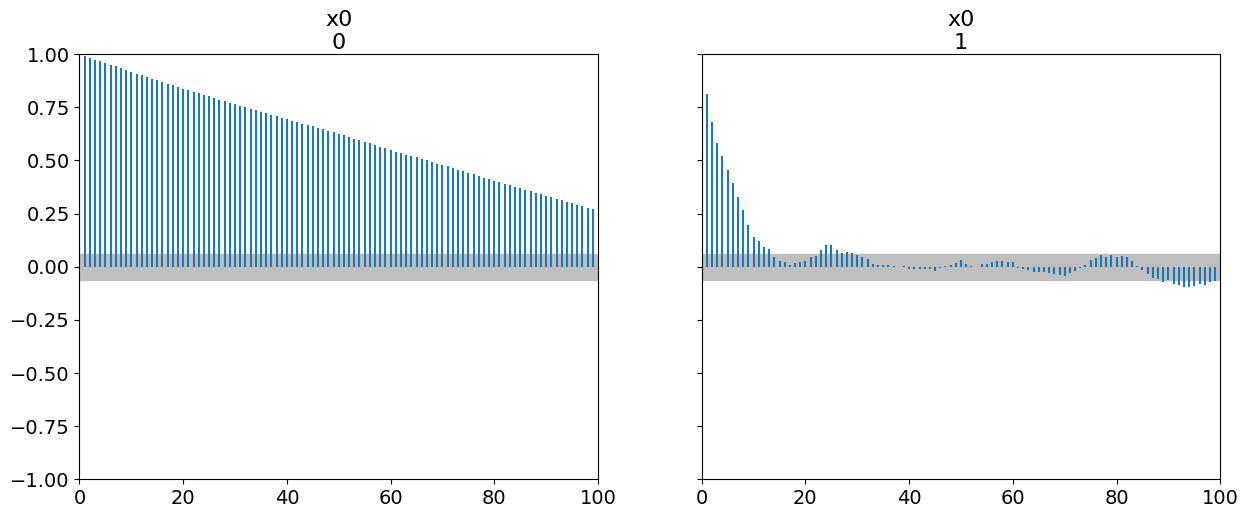

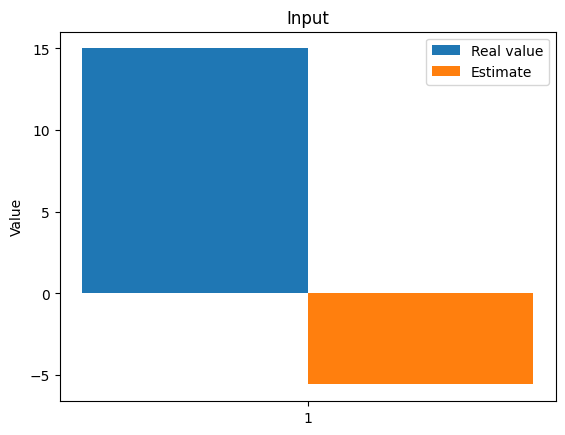

The function param_inverse took 548.7284097671509 seconds.
The best estimate is given by: sigma_noise=0.1, number of data= 50, sigma=4.0, rmwh_scaling=1.0
Noise: 0.1
Number of data: 30
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:10<00:00, 11.96it/s]


Sampling chain 2/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [04:20<00:00, 11.51it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.502]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.502  0.004  -3.507   -3.494        0.0      0.0     115.0     105.0   

    r_hat  
x0   1.03  
Autocorrelation...
the difference between estimated values [18.502]



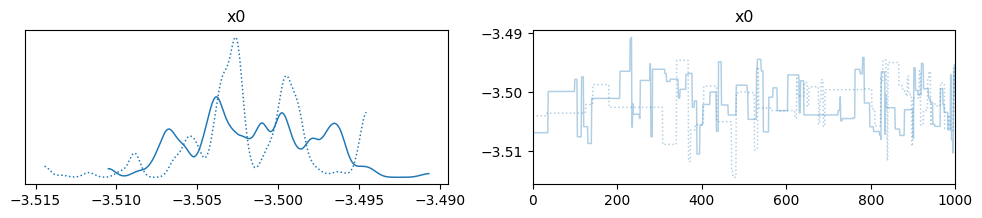

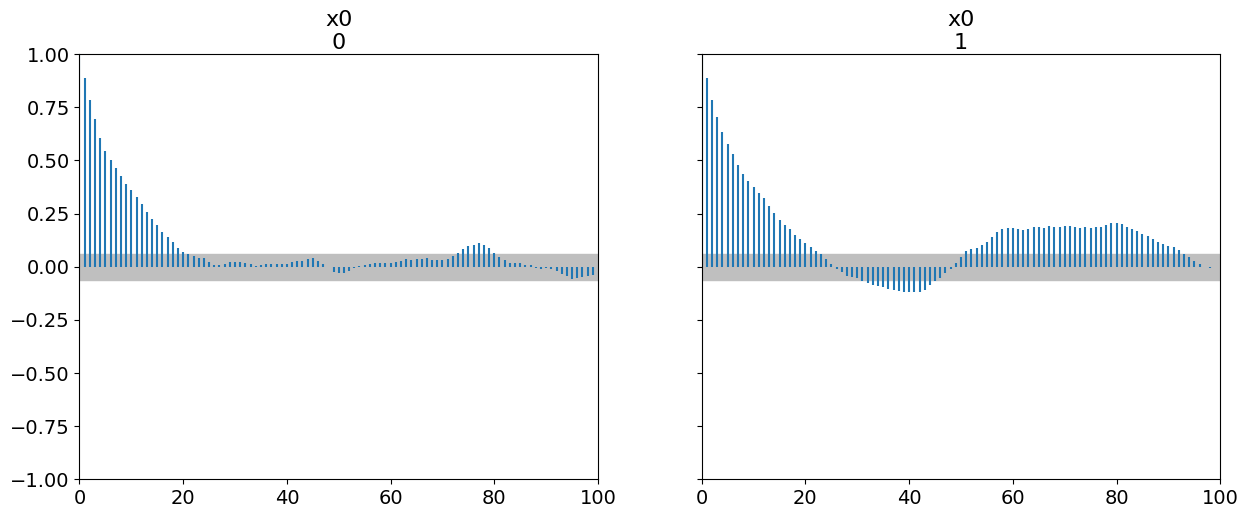

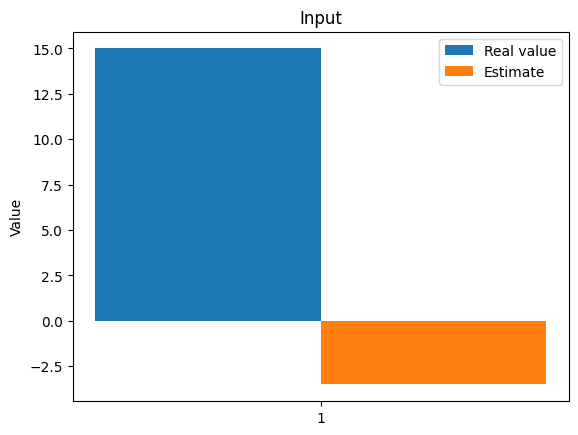

The function param_inverse took 512.5139009952545 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.14: 100%|██████████| 3000/3000 [04:19<00:00, 11.57it/s]


Sampling chain 2/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [04:21<00:00, 11.49it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.502]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.502  0.004  -3.509   -3.495        0.0      0.0     132.0     134.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [18.502]



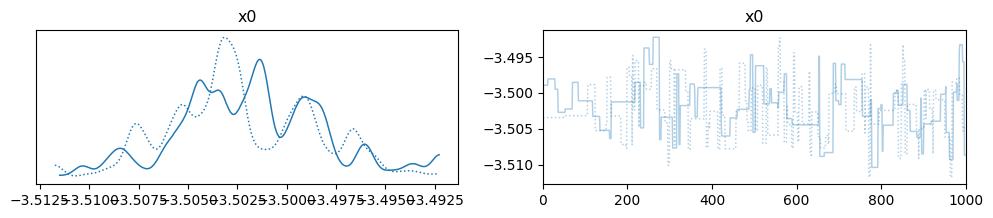

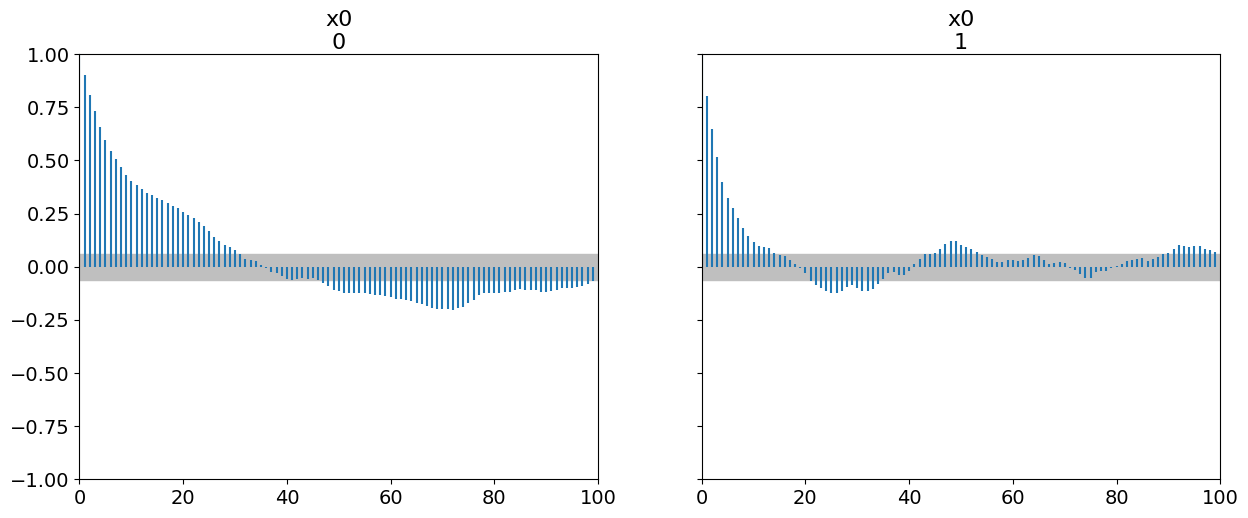

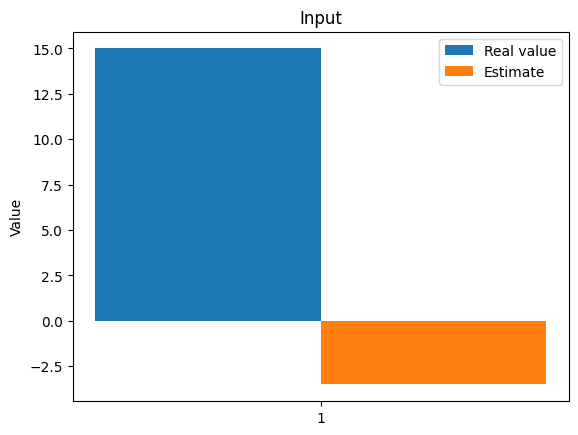

The function param_inverse took 521.5095794200897 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.11: 100%|██████████| 3000/3000 [04:22<00:00, 11.42it/s]


Sampling chain 2/2


Running chain, α = 0.10: 100%|██████████| 3000/3000 [04:21<00:00, 11.47it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.502]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.502  0.004  -3.508   -3.495        0.0      0.0     156.0     205.0   

    r_hat  
x0   1.03  
Autocorrelation...
the difference between estimated values [18.502]



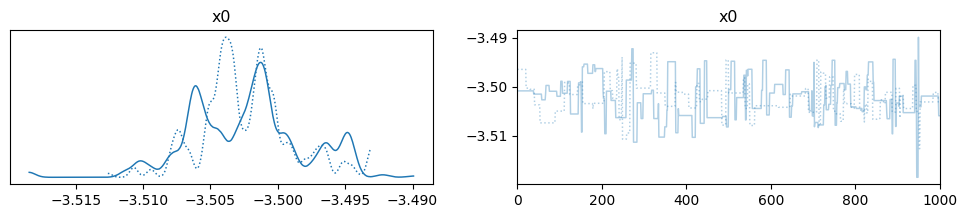

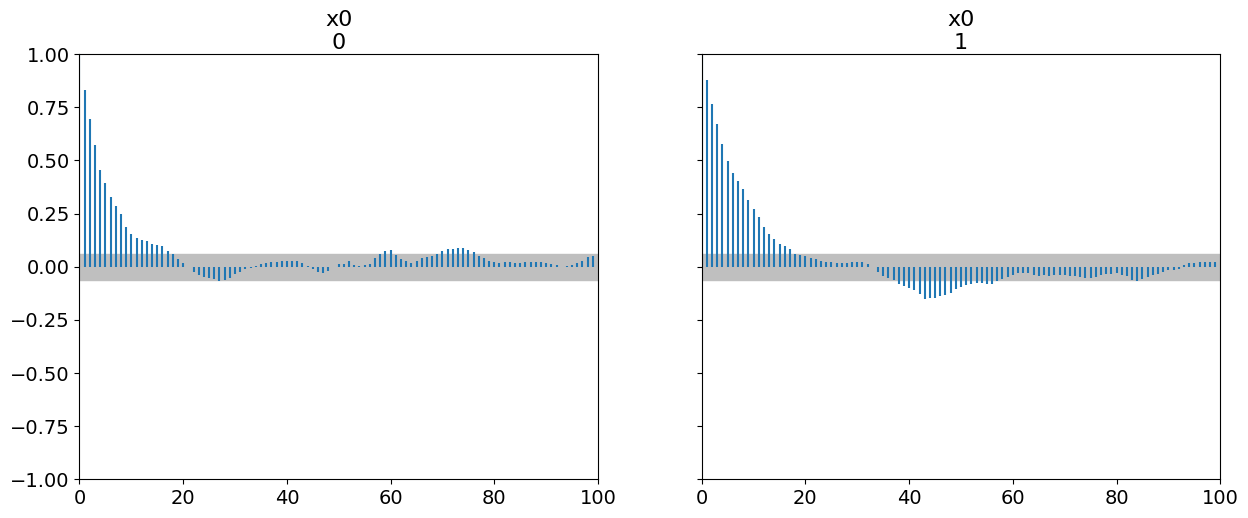

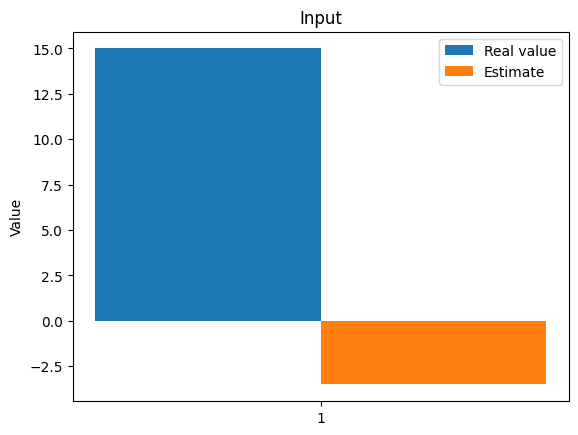

The function param_inverse took 525.3067631721497 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.14: 100%|██████████| 3000/3000 [04:20<00:00, 11.51it/s]


Sampling chain 2/2


Running chain, α = 0.13: 100%|██████████| 3000/3000 [04:24<00:00, 11.34it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.503]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.503  0.009  -3.519    -3.49      0.001    0.001     125.0     134.0   

    r_hat  
x0   1.03  
Autocorrelation...
the difference between estimated values [18.503]



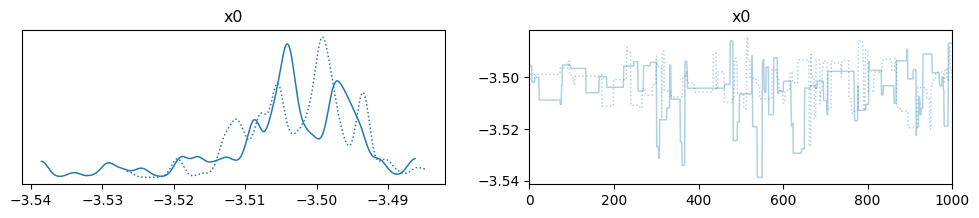

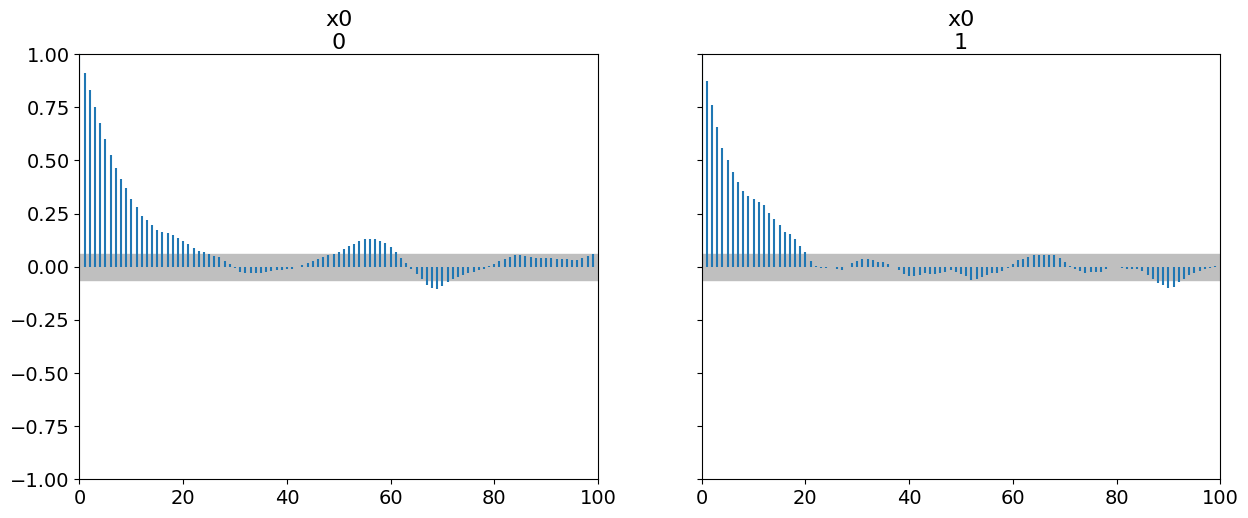

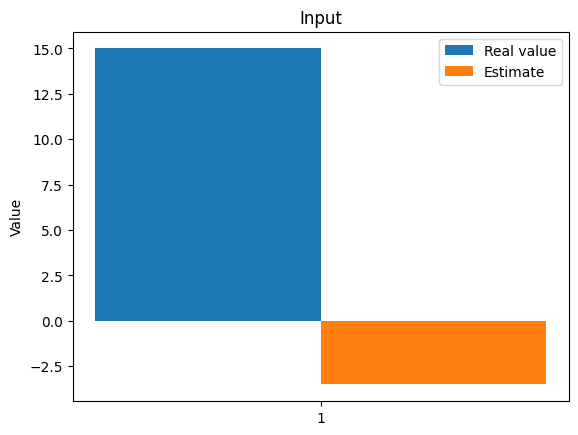

The function param_inverse took 526.0431272983551 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.13: 100%|██████████| 3000/3000 [04:20<00:00, 11.53it/s]


Sampling chain 2/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [04:20<00:00, 11.53it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.502]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.502  0.008  -3.519   -3.491      0.001    0.001     113.0     114.0   

    r_hat  
x0   1.08  
Autocorrelation...
the difference between estimated values [18.502]



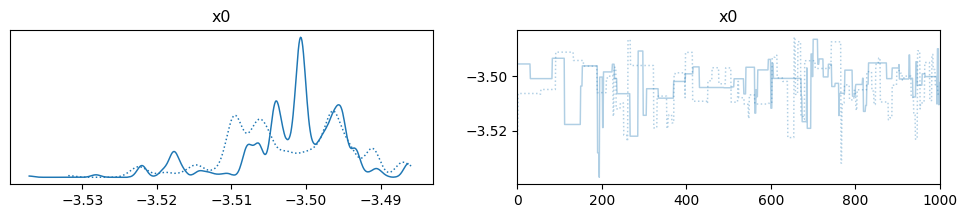

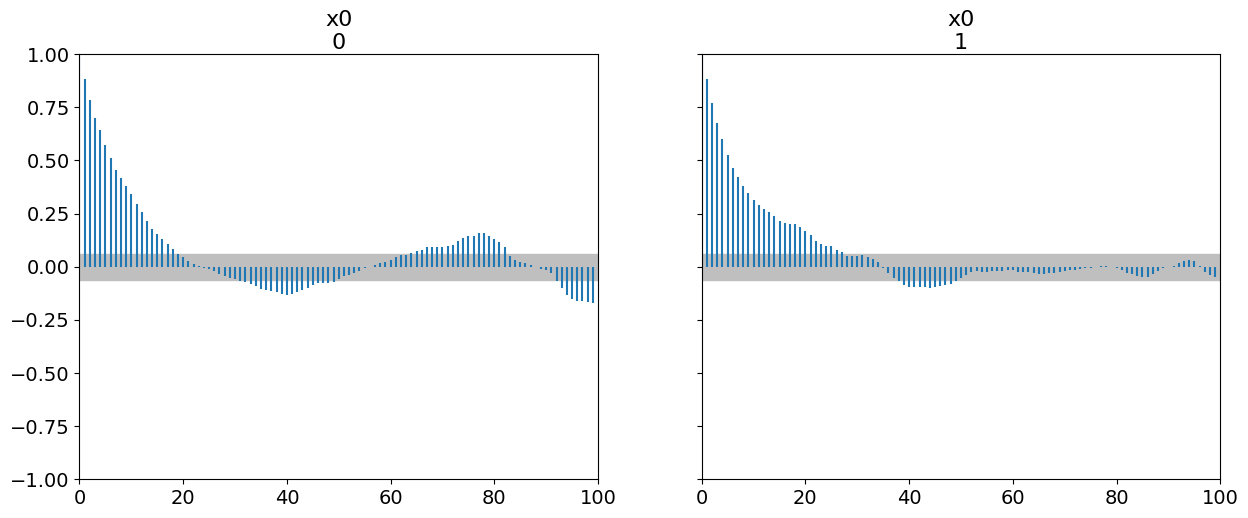

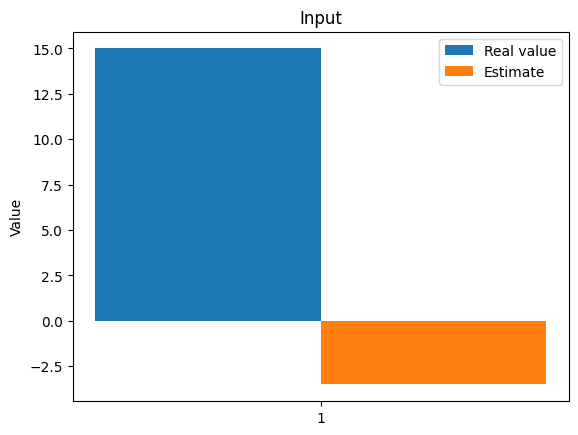

The function param_inverse took 521.3822498321533 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [04:20<00:00, 11.51it/s]


Sampling chain 2/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [04:21<00:00, 11.48it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.505]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.505  0.01  -3.524    -3.49      0.001    0.001      69.0      89.0   

    r_hat  
x0   1.06  
Autocorrelation...
the difference between estimated values [18.505]



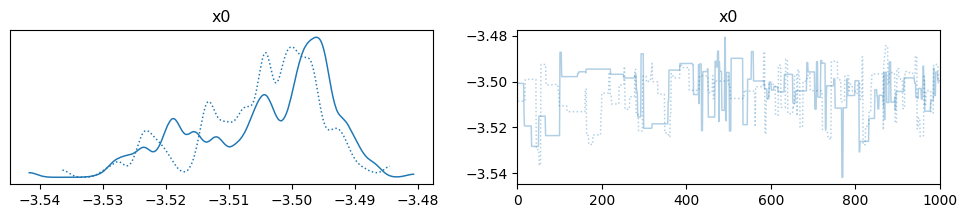

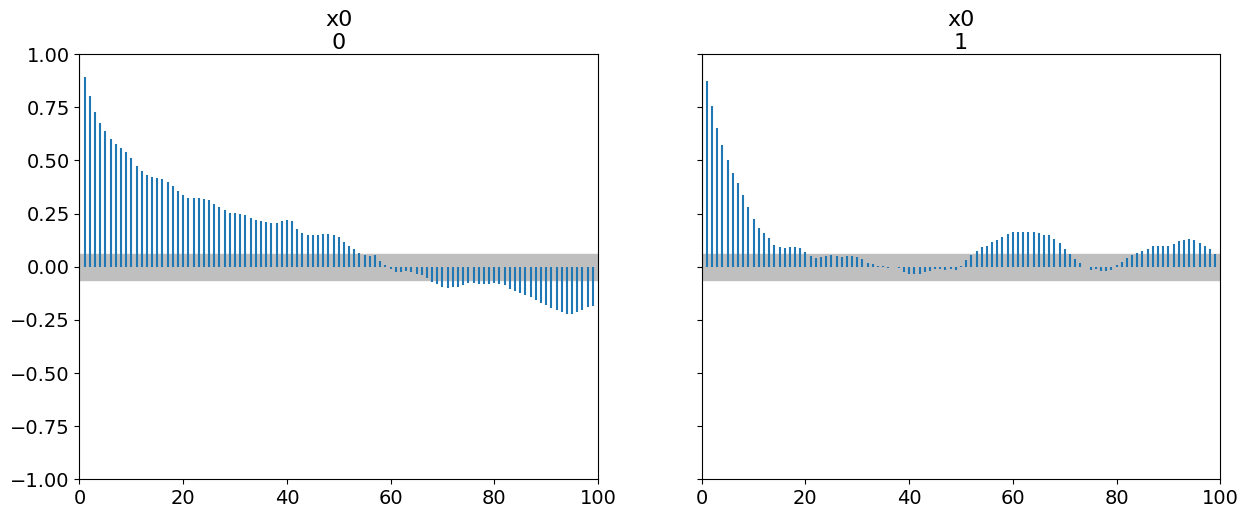

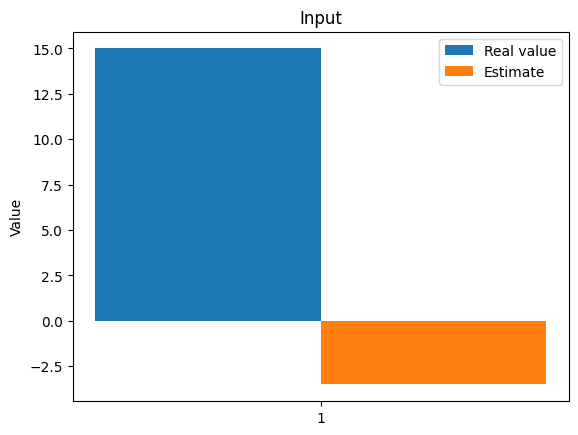

The function param_inverse took 523.0988893508911 seconds.
Number of data: 50
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [04:34<00:00, 10.93it/s]


Sampling chain 2/2


Running chain, α = 0.07: 100%|██████████| 3000/3000 [04:37<00:00, 10.80it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.468]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.468  0.004  -3.475   -3.462        0.0      0.0      85.0     105.0   

    r_hat  
x0   1.05  
Autocorrelation...
the difference between estimated values [18.468]



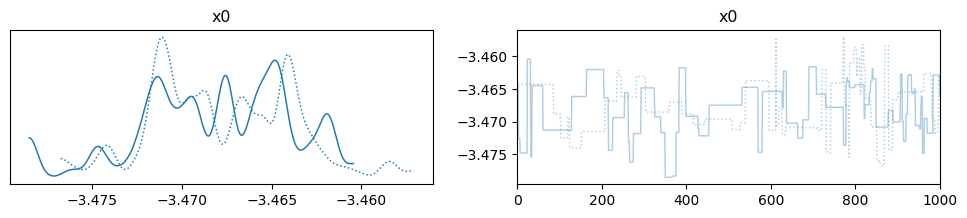

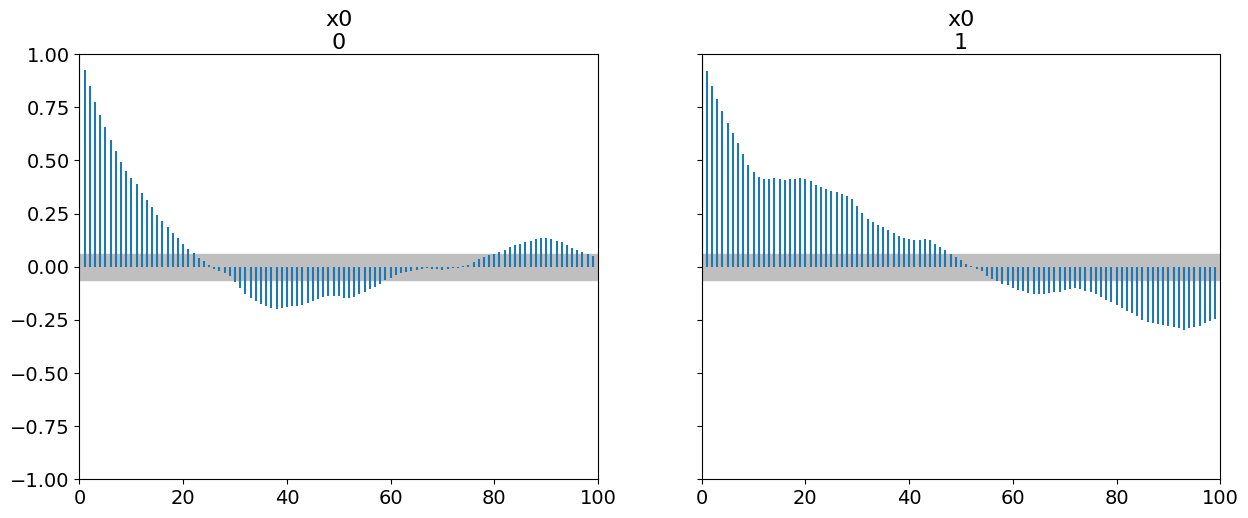

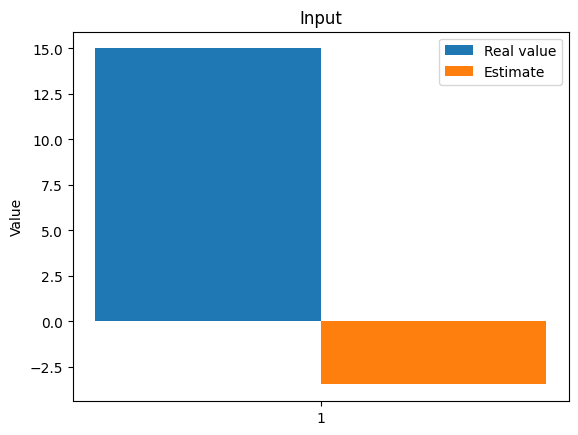

The function param_inverse took 553.3729727268219 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.11: 100%|██████████| 3000/3000 [04:35<00:00, 10.90it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:35<00:00, 10.90it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.466]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.466  0.004  -3.475   -3.461        0.0      0.0      88.0     125.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [18.466]



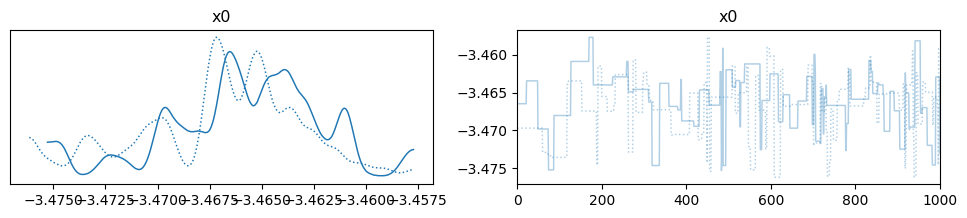

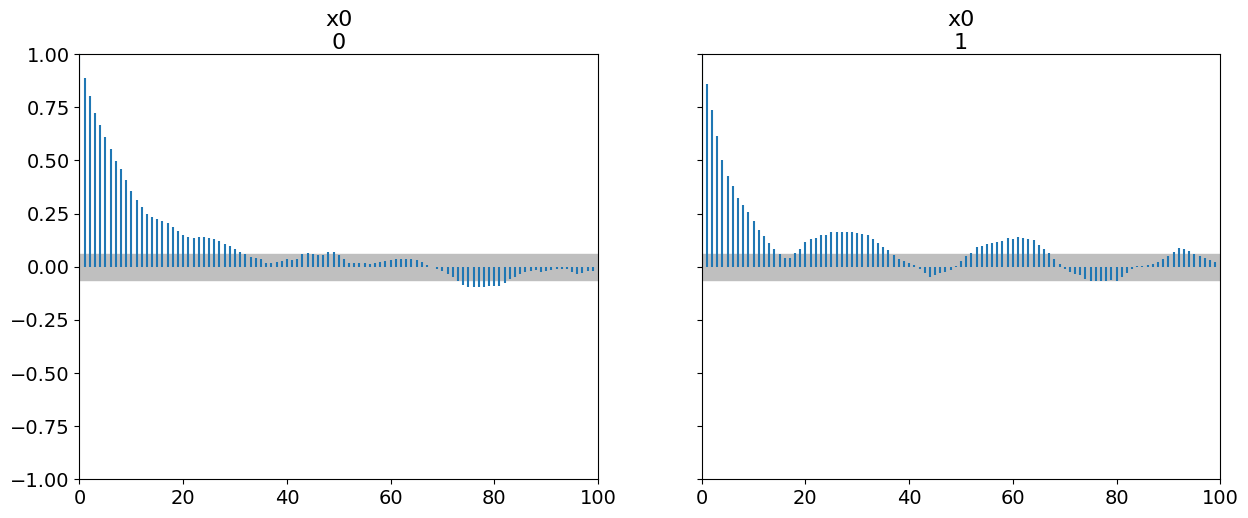

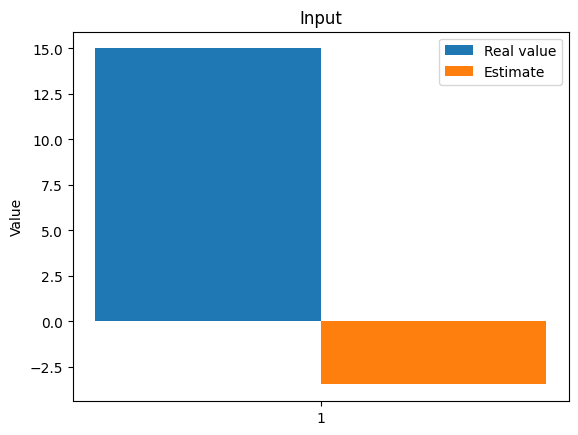

The function param_inverse took 551.503350019455 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:37<00:00, 10.82it/s]


Sampling chain 2/2


Running chain, α = 0.09: 100%|██████████| 3000/3000 [04:36<00:00, 10.87it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.466]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.466  0.004  -3.472   -3.459        0.0      0.0      73.0      87.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [18.466]



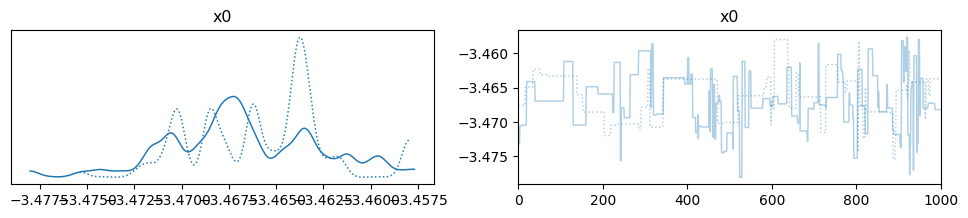

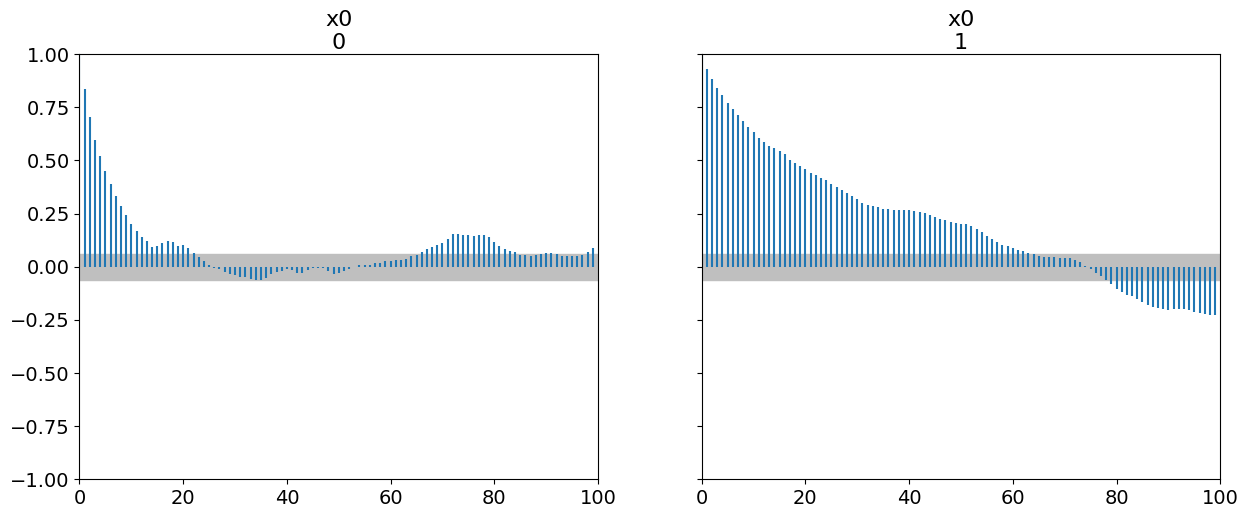

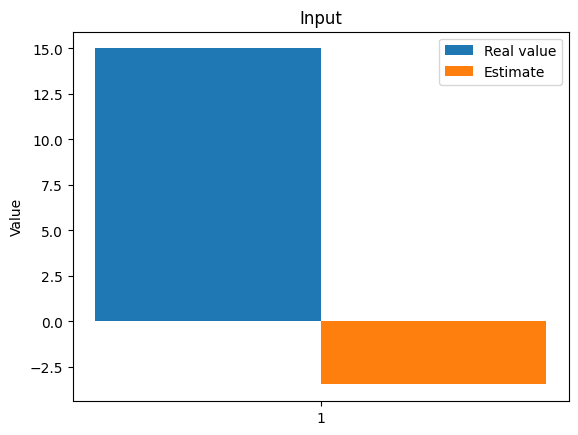

The function param_inverse took 554.6207838058472 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [04:33<00:00, 10.96it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [04:34<00:00, 10.93it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.468]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.468  0.015  -3.486   -3.453      0.002    0.001      81.0      89.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [18.468]



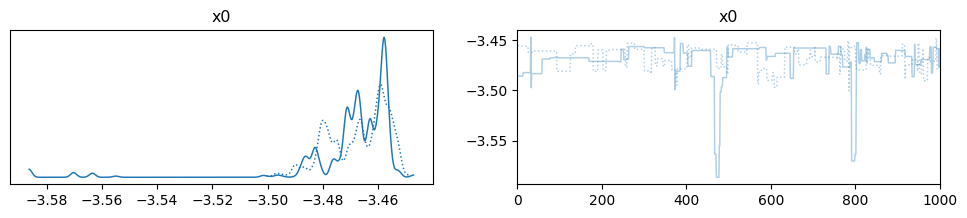

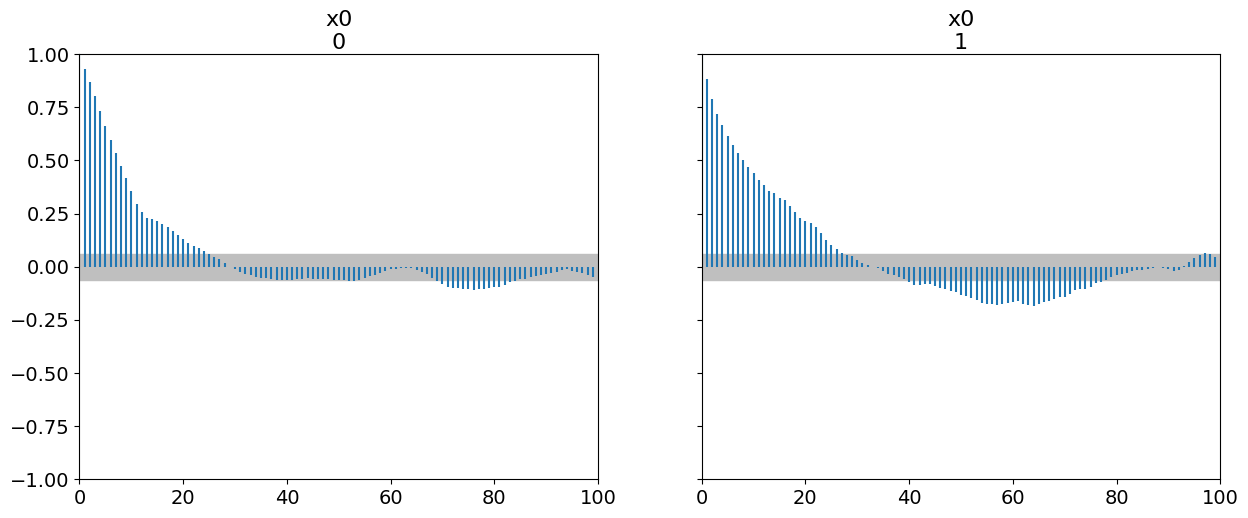

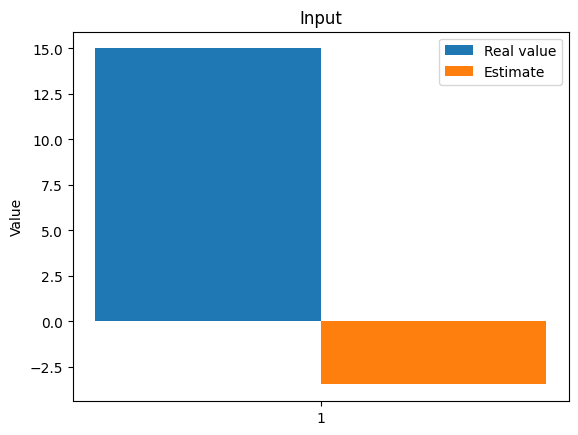

The function param_inverse took 549.3805513381958 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.22: 100%|██████████| 3000/3000 [04:33<00:00, 10.97it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [04:35<00:00, 10.88it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.469]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.469  0.012  -3.484   -3.455      0.001    0.001     110.0     133.0   

    r_hat  
x0   1.06  
Autocorrelation...
the difference between estimated values [18.469]



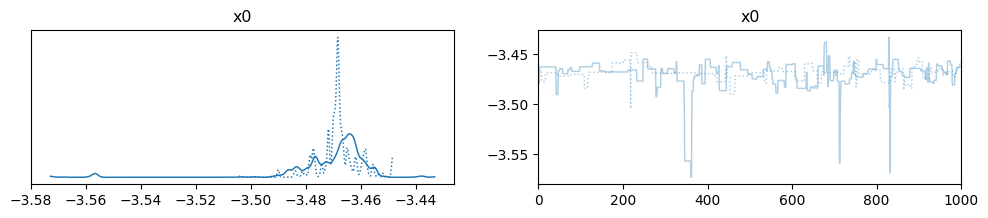

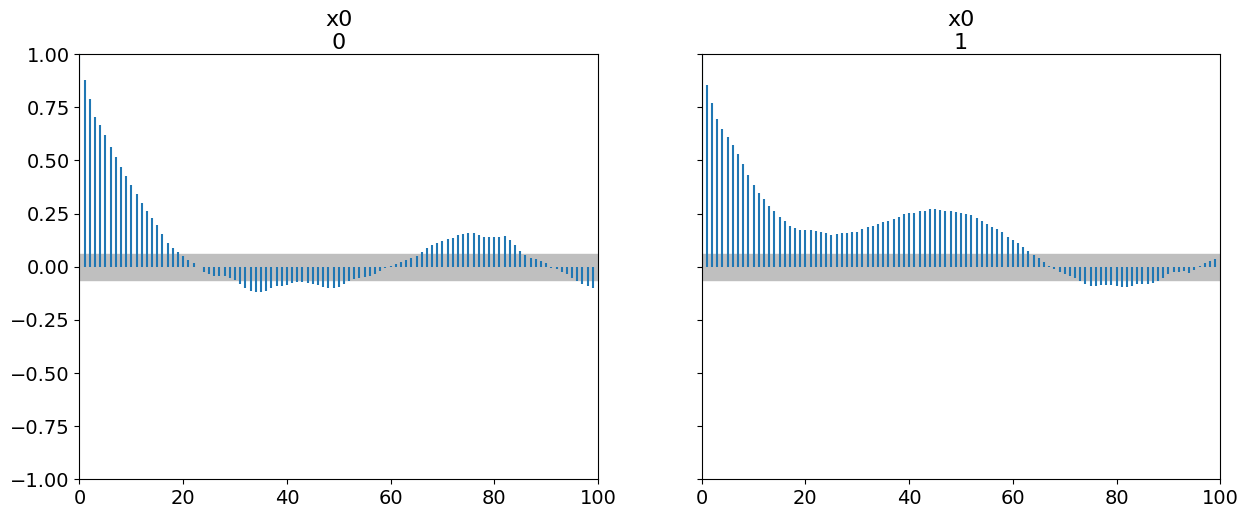

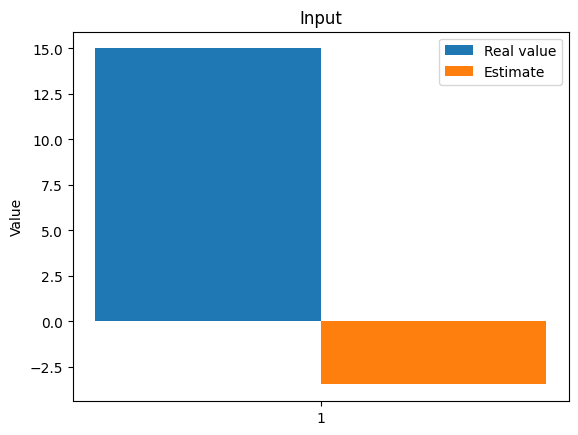

The function param_inverse took 550.3436090946198 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [04:34<00:00, 10.94it/s]


Sampling chain 2/2


Running chain, α = 0.08: 100%|██████████| 3000/3000 [04:36<00:00, 10.85it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.469]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.469  0.01  -3.481   -3.452      0.001      0.0     209.0     237.0   

    r_hat  
x0   1.03  
Autocorrelation...
the difference between estimated values [18.469]



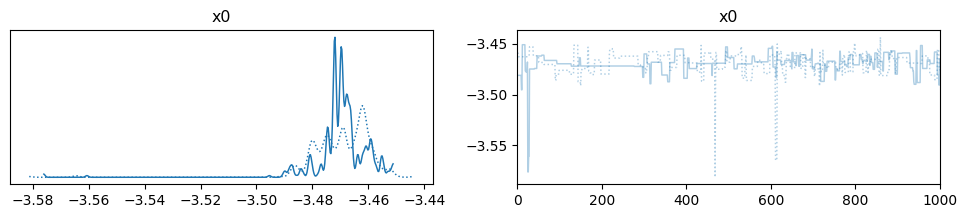

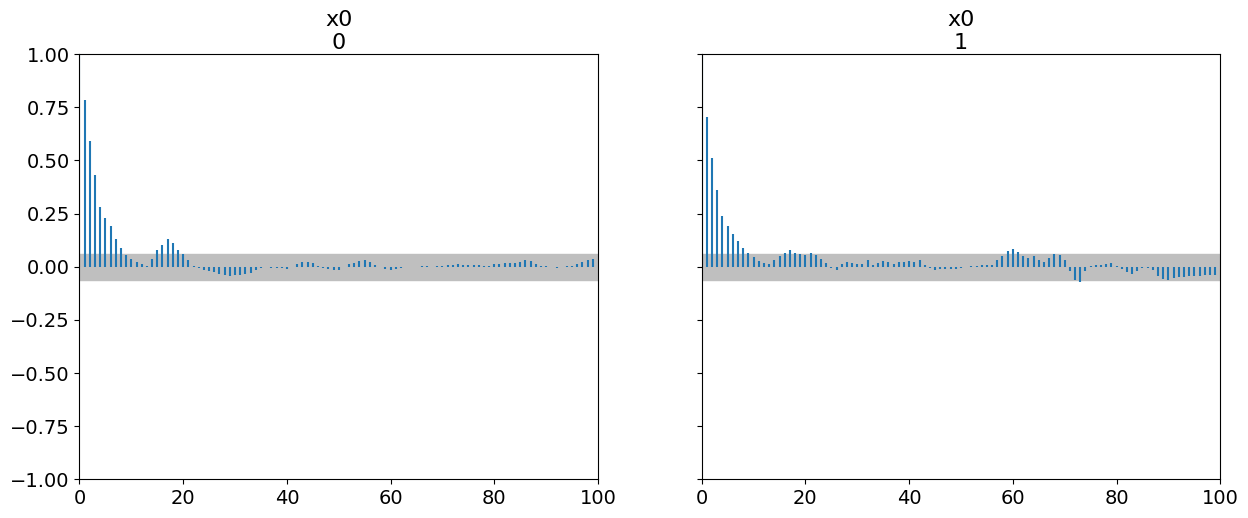

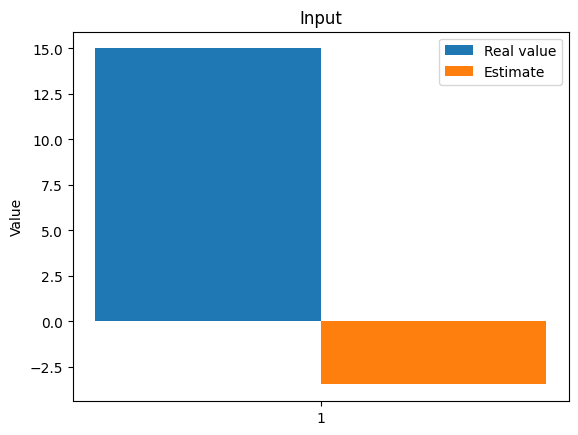

The function param_inverse took 551.5741517543793 seconds.
The best estimate is given by: sigma_noise=0.05, number of data= 30, sigma=2.0, rmwh_scaling=0.5
Noise: 0.05
Number of data: 30
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.08: 100%|██████████| 3000/3000 [04:21<00:00, 11.49it/s]


Sampling chain 2/2


Running chain, α = 0.03: 100%|██████████| 3000/3000 [04:22<00:00, 11.44it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.501]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.501  0.004   -3.51   -3.497        0.0      0.0      76.0      37.0   

    r_hat  
x0   1.05  
Autocorrelation...
the difference between estimated values [18.501]



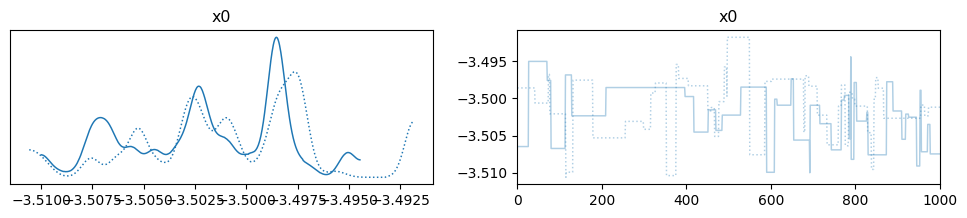

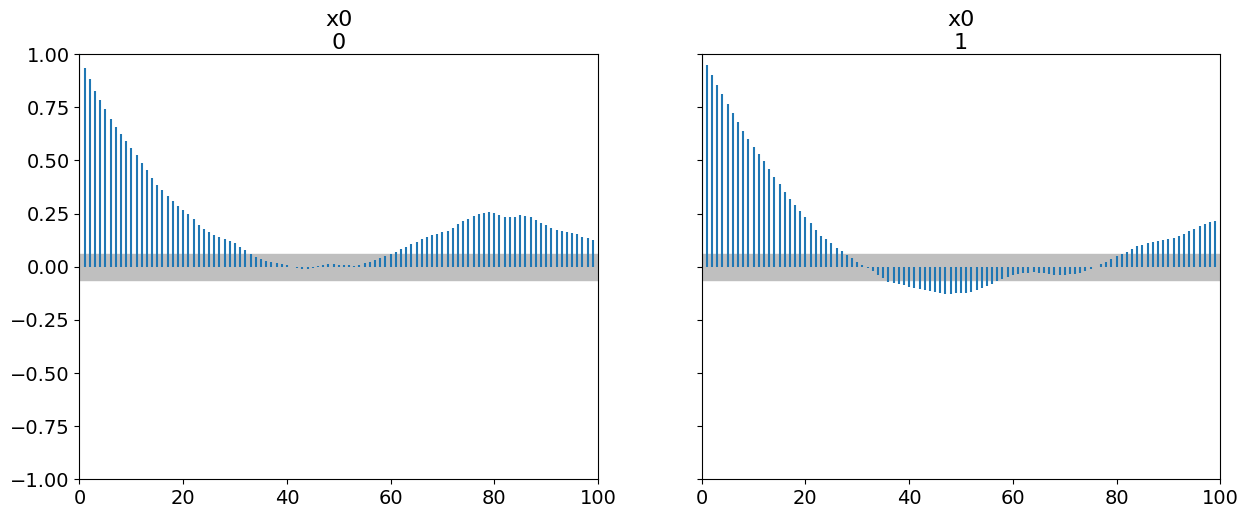

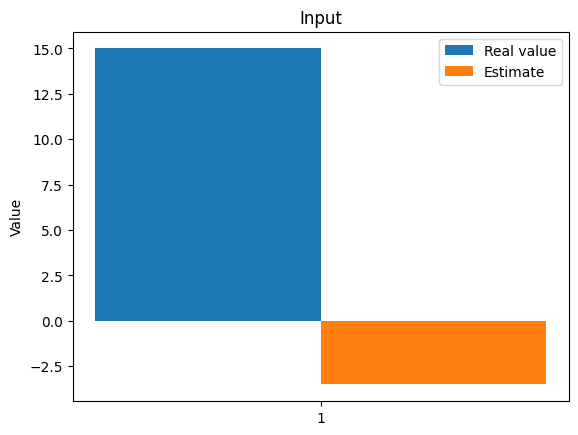

The function param_inverse took 524.5268802642822 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.09: 100%|██████████| 3000/3000 [04:20<00:00, 11.51it/s]


Sampling chain 2/2


Running chain, α = 0.07: 100%|██████████| 3000/3000 [04:21<00:00, 11.48it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.502]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.502  0.004  -3.509   -3.494        0.0      0.0      95.0      51.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [18.502]



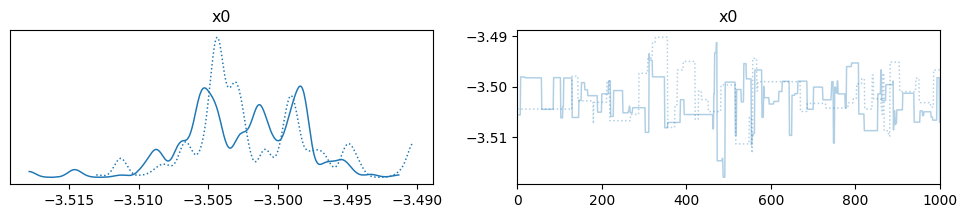

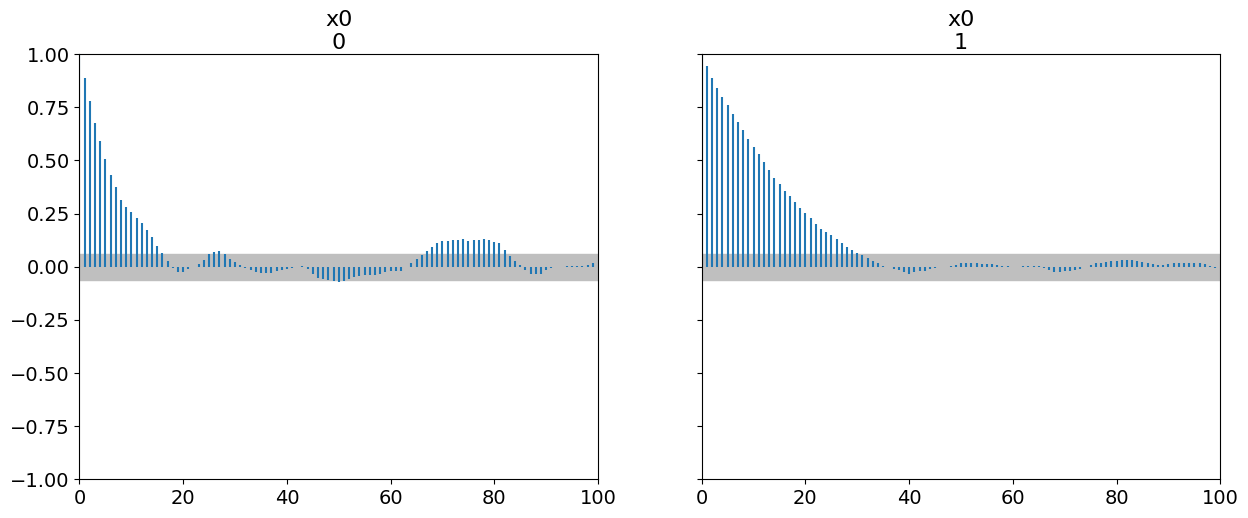

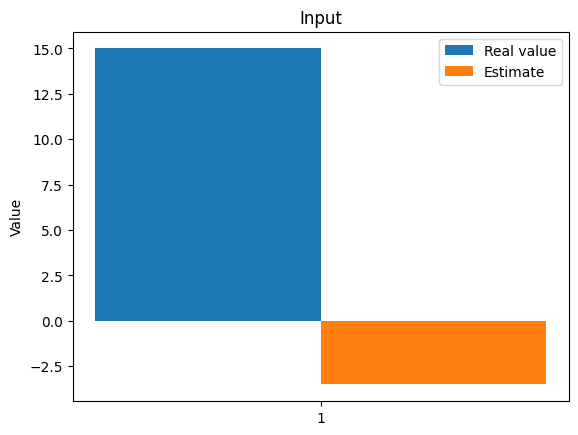

The function param_inverse took 523.169468164444 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.12: 100%|██████████| 3000/3000 [04:25<00:00, 11.30it/s]


Sampling chain 2/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [04:23<00:00, 11.37it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.502]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.502  0.004   -3.51   -3.496        0.0      0.0     110.0     103.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [18.502]



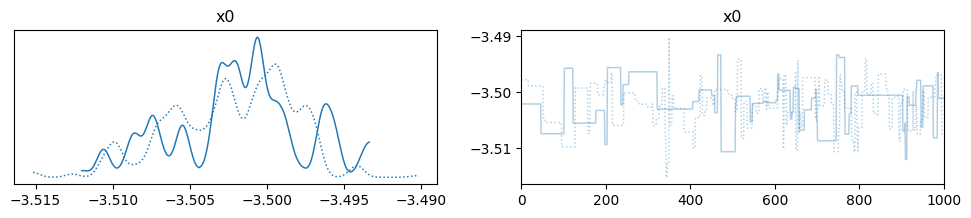

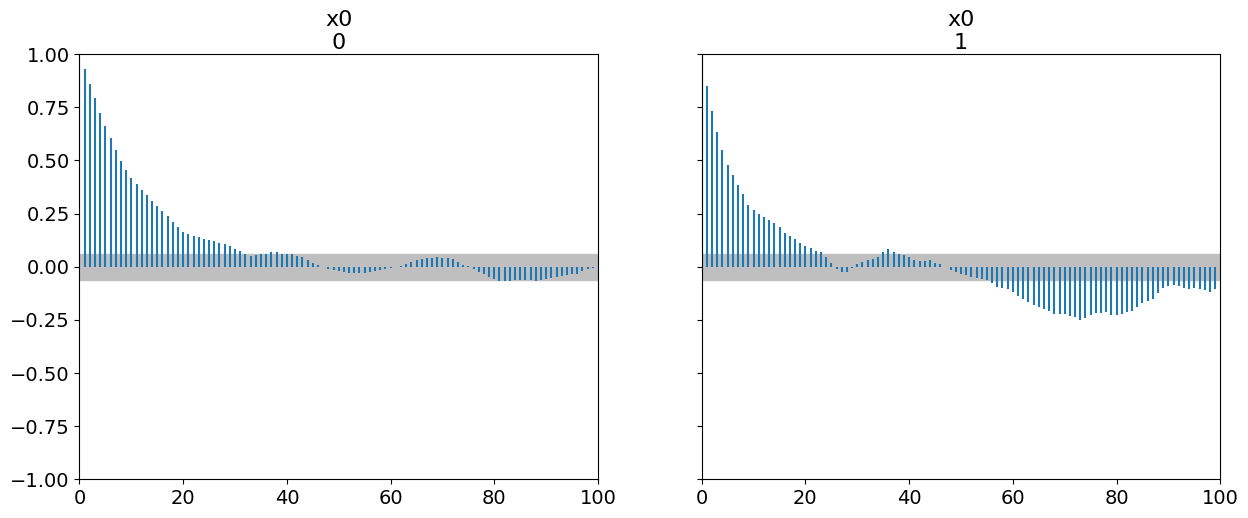

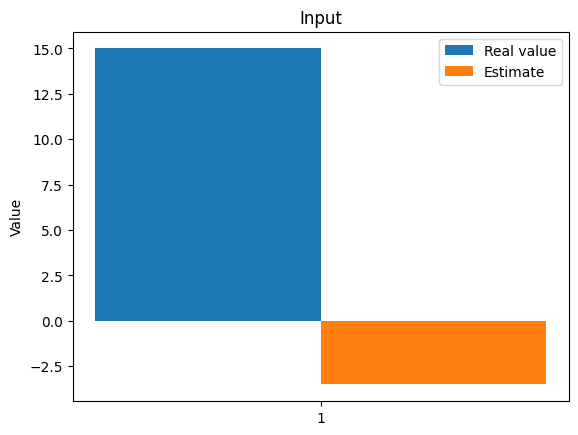

The function param_inverse took 531.1245167255402 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.12: 100%|██████████| 3000/3000 [04:31<00:00, 11.04it/s]


Sampling chain 2/2


Running chain, α = 0.10: 100%|██████████| 3000/3000 [03:26<00:00, 14.51it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.504]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.504  0.01  -3.524   -3.489      0.001    0.001      66.0      60.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [18.504]



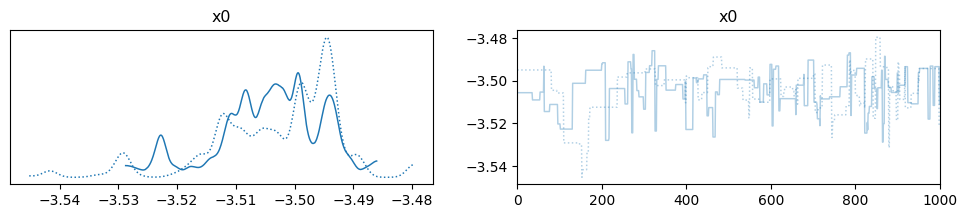

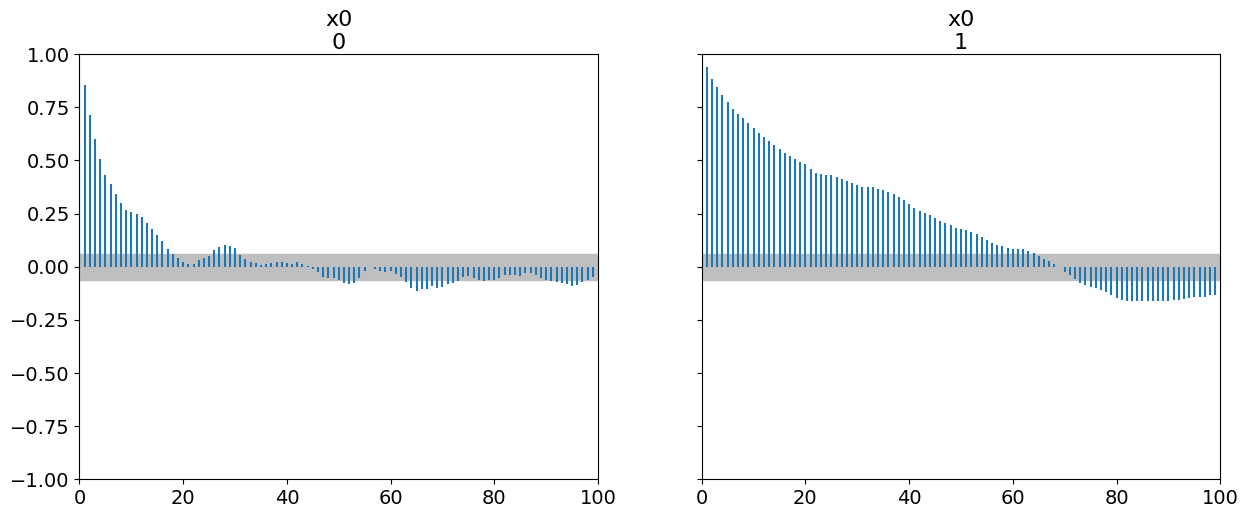

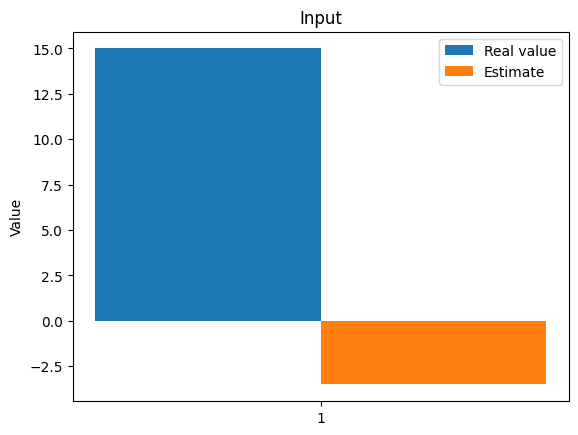

The function param_inverse took 479.5287299156189 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.13: 100%|██████████| 3000/3000 [02:37<00:00, 19.02it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [02:39<00:00, 18.86it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.504]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.504  0.01  -3.522   -3.489      0.001    0.001     147.0     107.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [18.504]



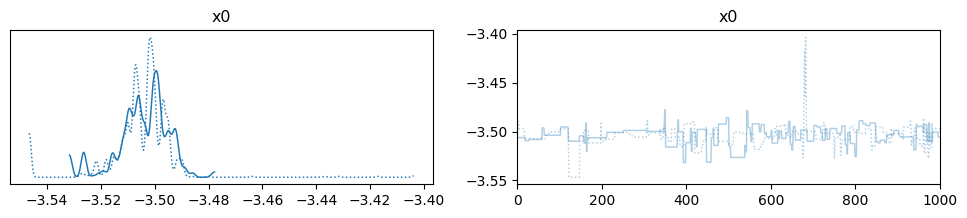

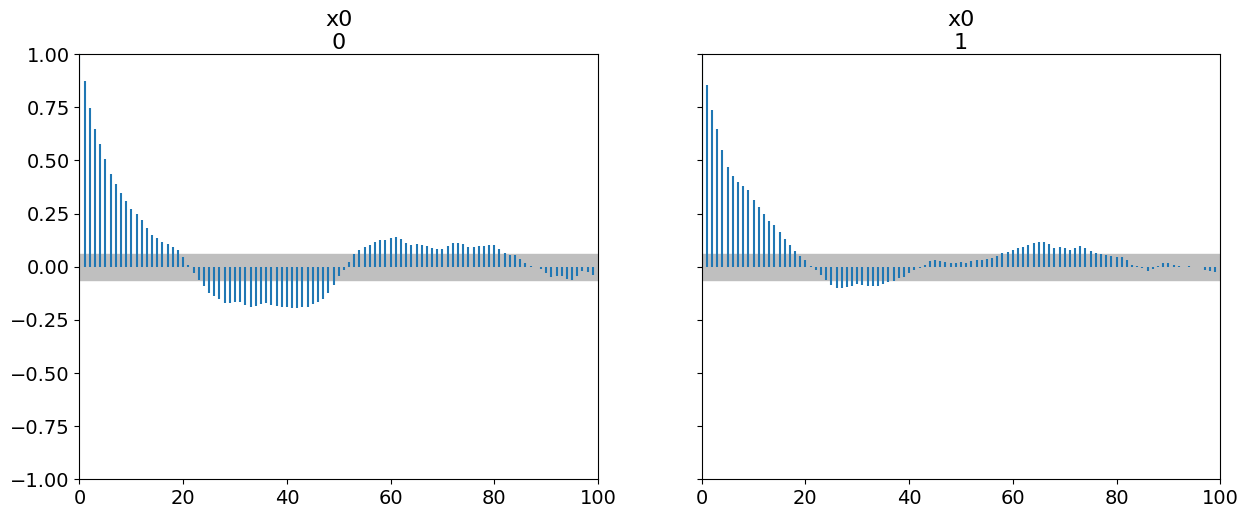

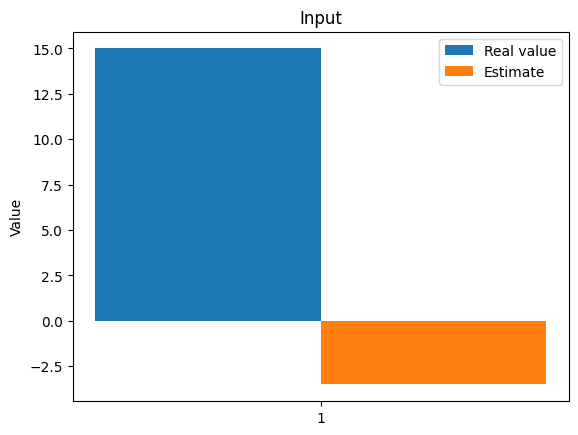

The function param_inverse took 317.57450008392334 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [02:37<00:00, 19.07it/s]


Sampling chain 2/2


Running chain, α = 0.18: 100%|██████████| 3000/3000 [02:40<00:00, 18.75it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.503]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.503  0.009   -3.52   -3.487      0.001    0.001     121.0     104.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [18.503]



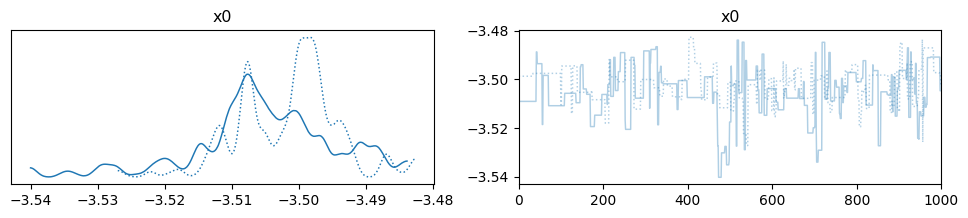

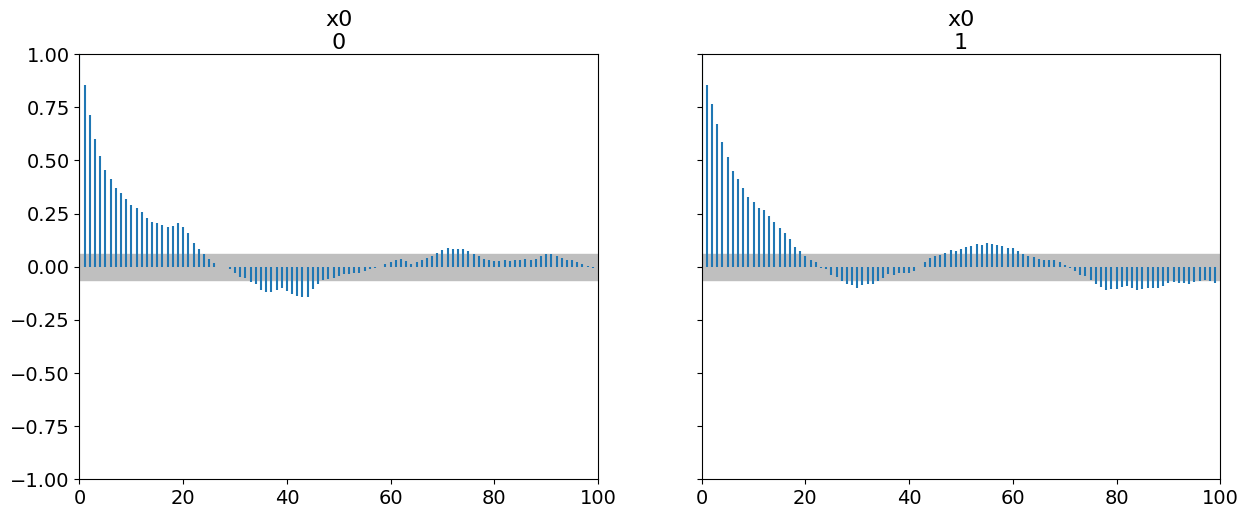

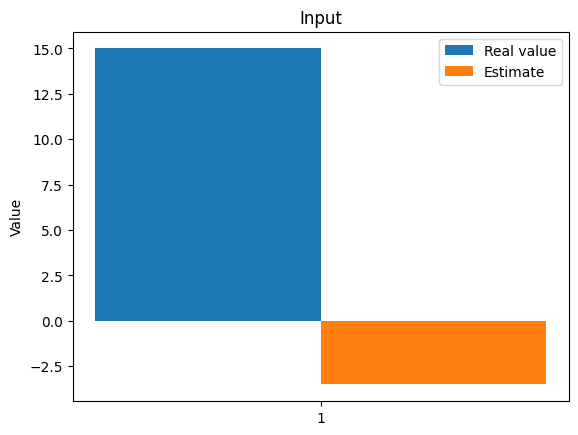

The function param_inverse took 318.0339922904968 seconds.
Number of data: 50
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.06: 100%|██████████| 3000/3000 [02:47<00:00, 17.93it/s]


Sampling chain 2/2


Running chain, α = 0.11: 100%|██████████| 3000/3000 [02:45<00:00, 18.12it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.467]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.467  0.004  -3.473    -3.46      0.001      0.0      38.0      54.0   

    r_hat  
x0   1.08  
Autocorrelation...
the difference between estimated values [18.467]



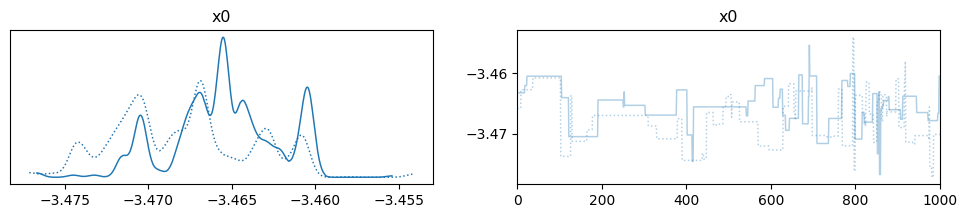

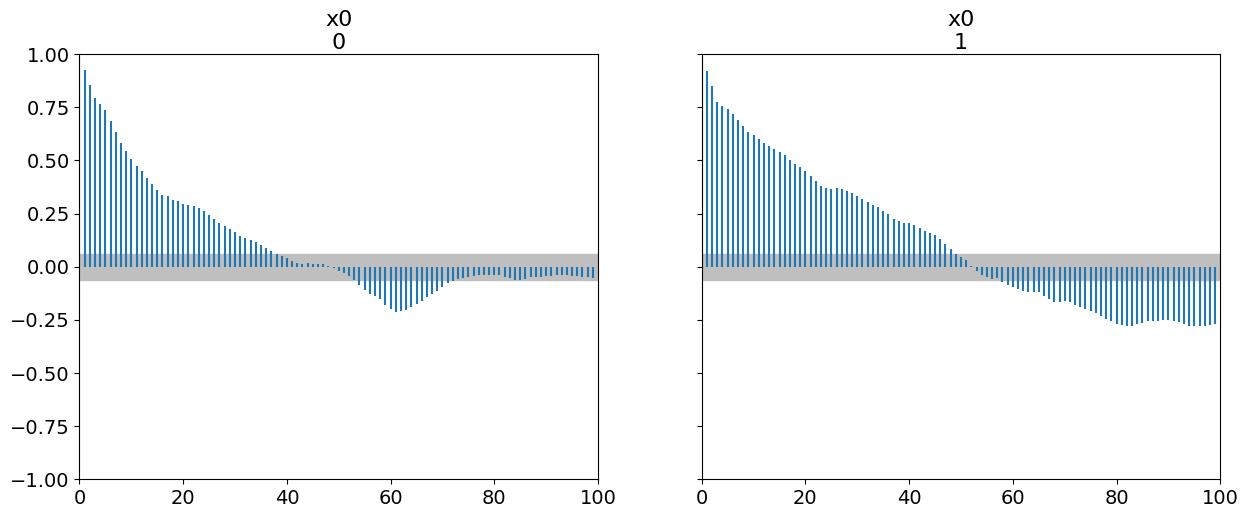

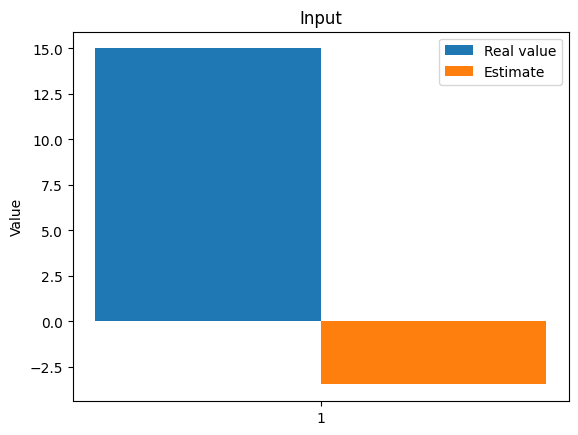

The function param_inverse took 333.5643563270569 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.05: 100%|██████████| 3000/3000 [02:45<00:00, 18.11it/s]


Sampling chain 2/2


Running chain, α = 0.13: 100%|██████████| 3000/3000 [02:45<00:00, 18.14it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.467]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.467  0.005  -3.475   -3.458      0.001    0.001      37.0      35.0   

    r_hat  
x0   1.04  
Autocorrelation...
the difference between estimated values [18.467]



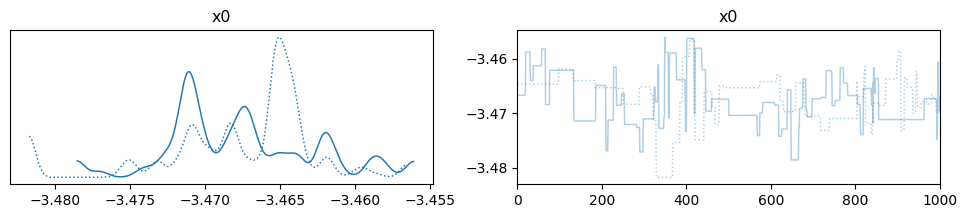

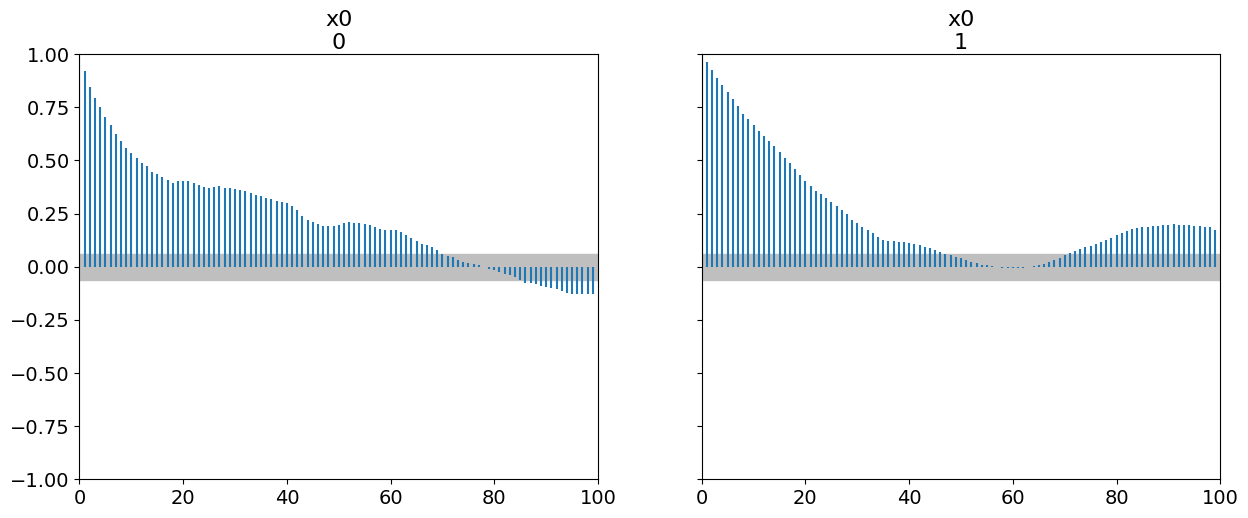

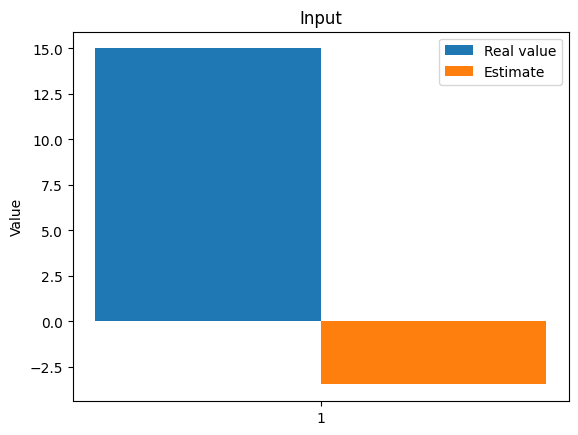

The function param_inverse took 331.6490921974182 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [02:45<00:00, 18.12it/s]


Sampling chain 2/2


Running chain, α = 0.14: 100%|██████████| 3000/3000 [02:46<00:00, 17.98it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.467]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.467  0.004  -3.474   -3.461        0.0      0.0     115.0      60.0   

    r_hat  
x0   1.03  
Autocorrelation...
the difference between estimated values [18.467]



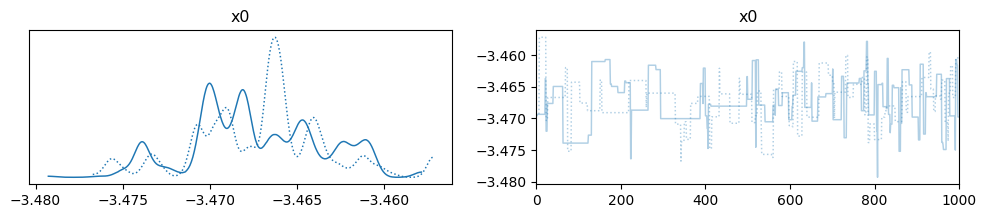

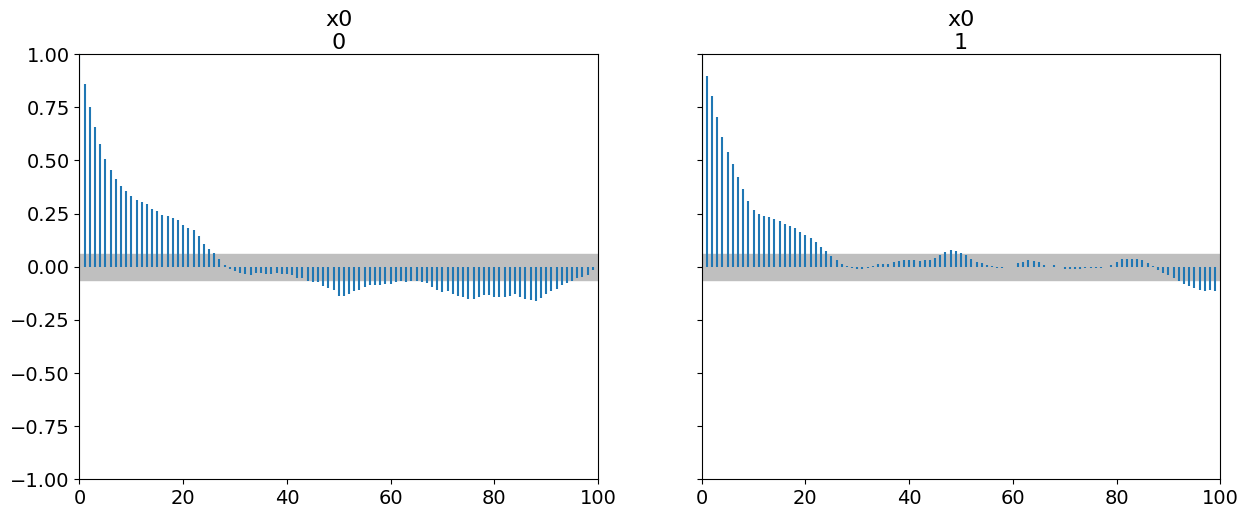

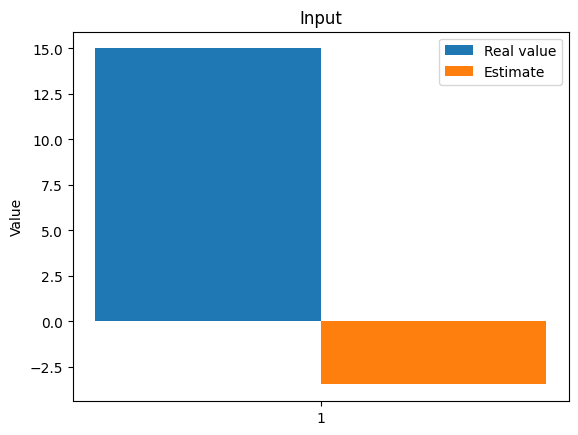

The function param_inverse took 333.2806603908539 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [02:46<00:00, 17.97it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [02:45<00:00, 18.08it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.469]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.469  0.012  -3.485   -3.453      0.001    0.001     153.0     141.0   

    r_hat  
x0   1.03  
Autocorrelation...
the difference between estimated values [18.469]



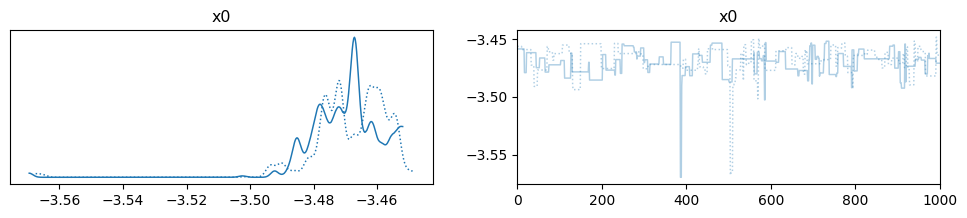

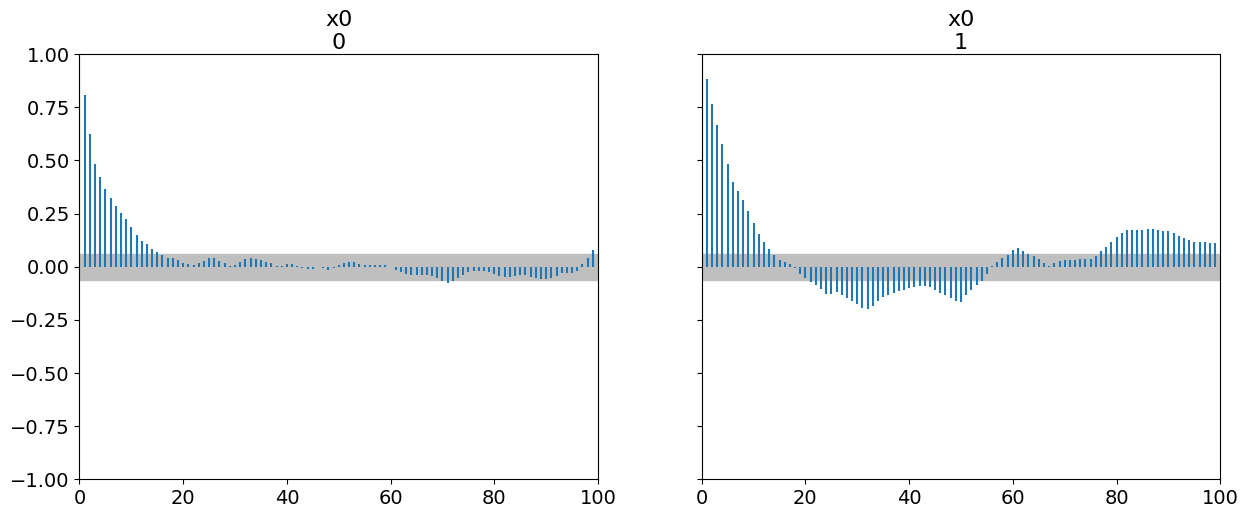

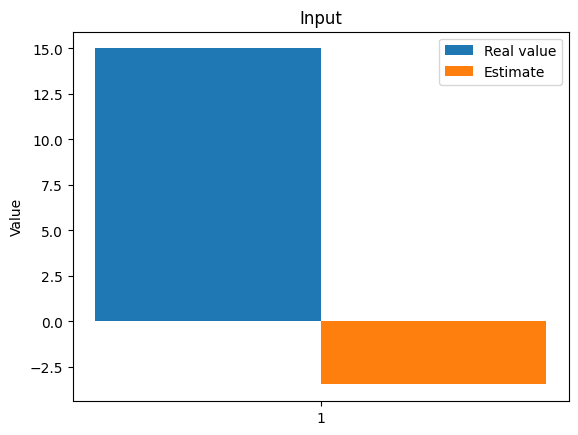

The function param_inverse took 333.6588580608368 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [02:46<00:00, 18.02it/s]


Sampling chain 2/2


Running chain, α = 0.11: 100%|██████████| 3000/3000 [02:46<00:00, 18.03it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.47]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.47  0.014  -3.487   -3.454      0.001    0.001      83.0     120.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [18.47]



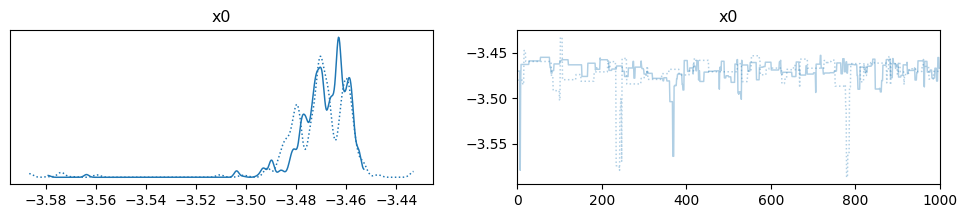

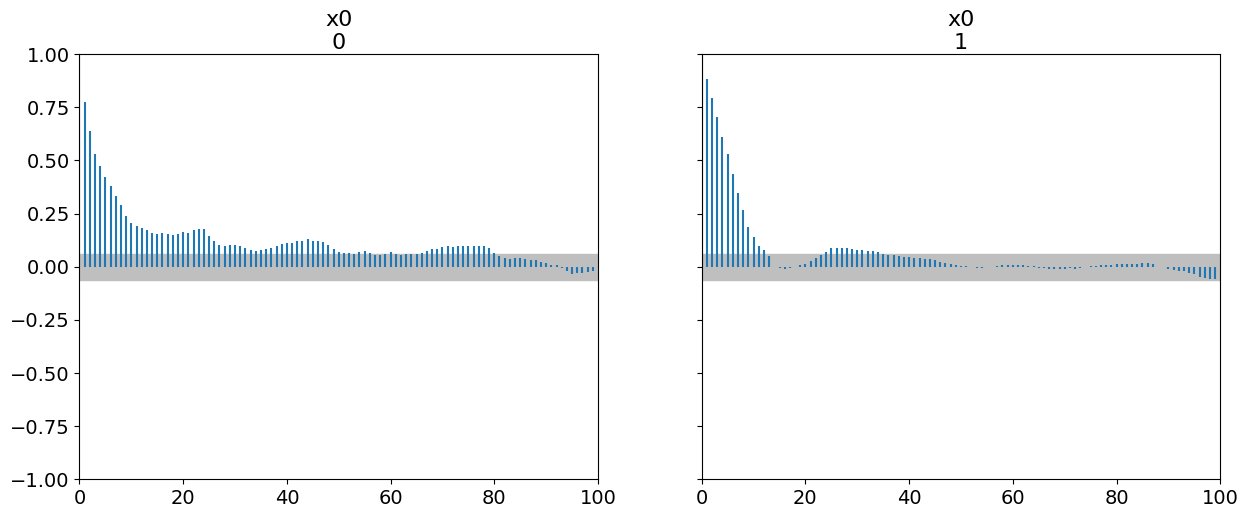

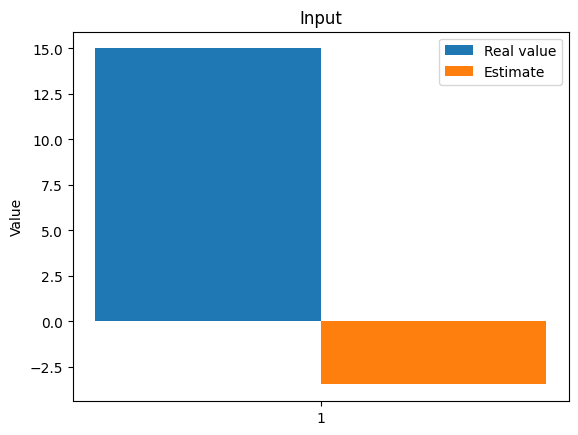

The function param_inverse took 333.6941750049591 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [02:48<00:00, 17.83it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [03:12<00:00, 15.62it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [-3.468]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -3.468  0.012  -3.483   -3.451      0.001      0.0     215.0     146.0   

    r_hat  
x0   1.06  
Autocorrelation...
the difference between estimated values [18.468]



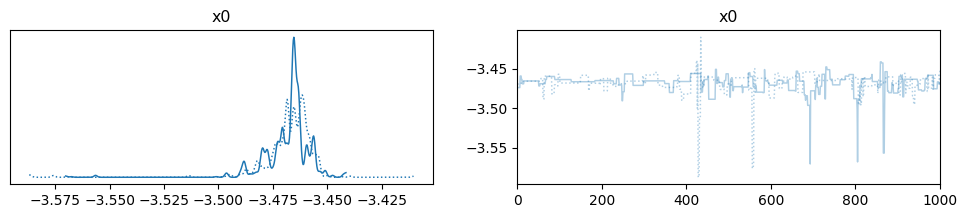

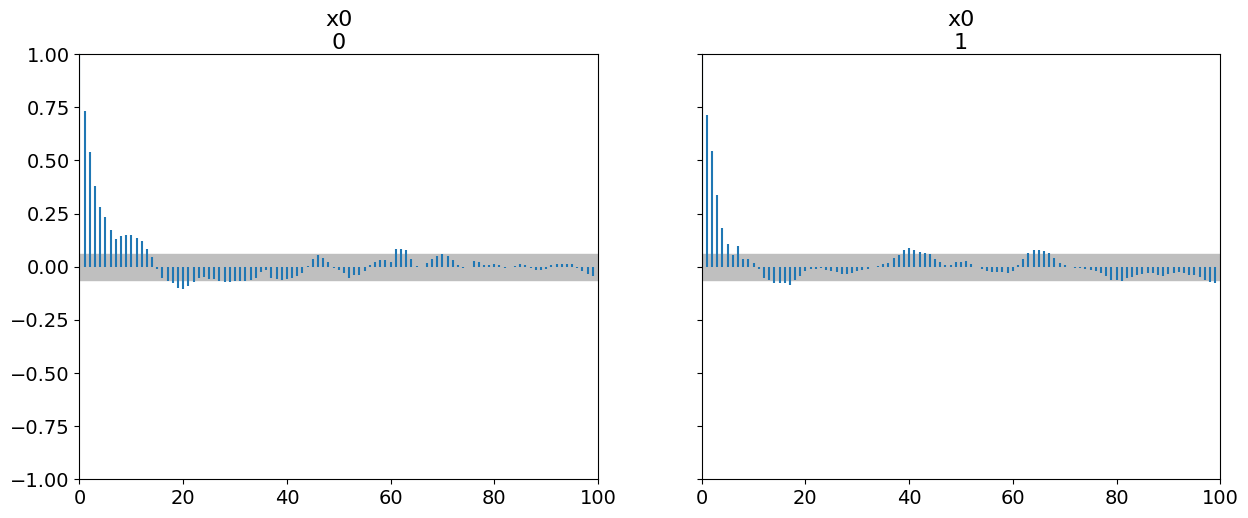

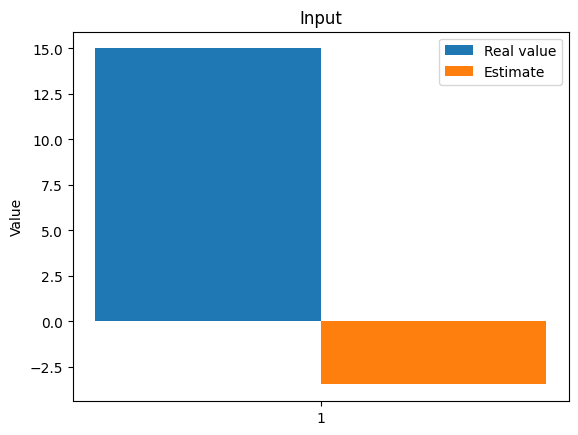

The function param_inverse took 361.4290397167206 seconds.
The best estimate is given by: sigma_noise=0.1, number of data= 50, sigma=2.0, rmwh_scaling=1.0
Noise: 0.1
Number of data: 30
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.28: 100%|██████████| 3000/3000 [08:41<00:00,  5.75it/s]


Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 3000/3000 [08:28<00:00,  5.89it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.758]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.758  0.191  14.394   15.085       0.01    0.007     337.0     297.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.242]



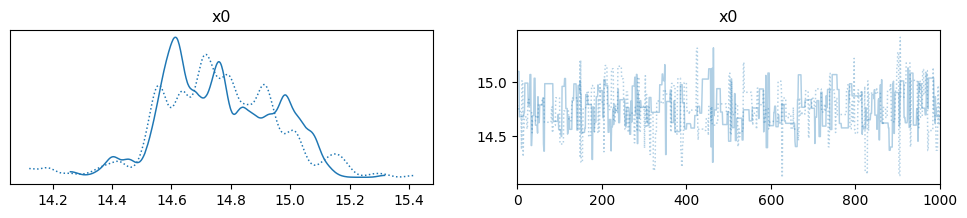

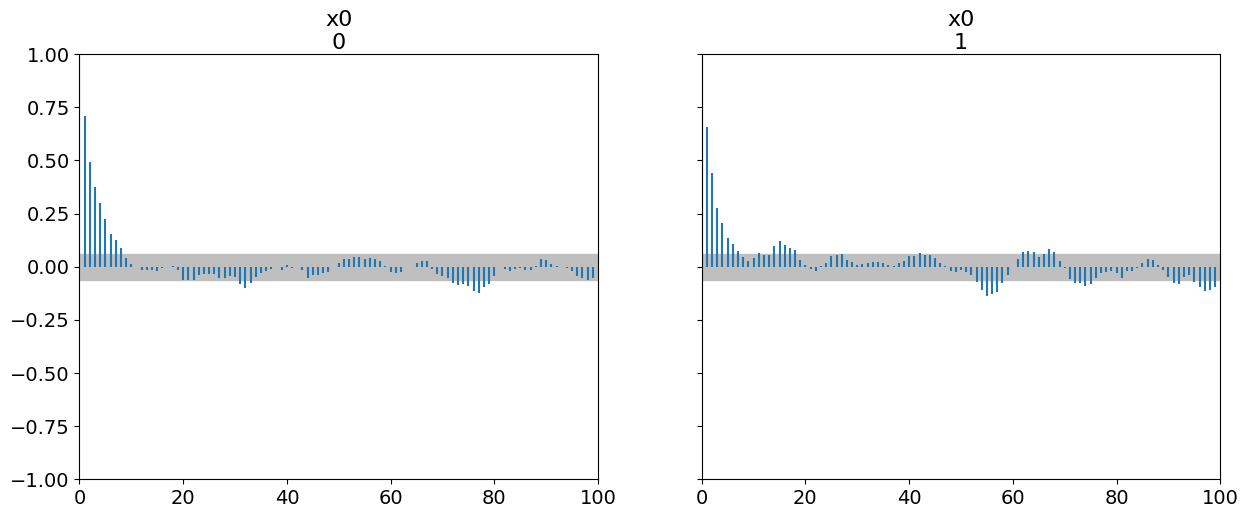

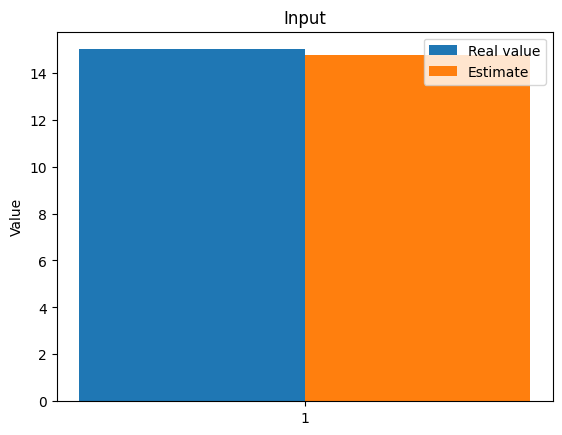

The function param_inverse took 1032.0001845359802 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [08:41<00:00,  5.75it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [08:33<00:00,  5.84it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.729]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.729  0.188  14.332   15.034      0.012    0.008     262.0     274.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.271]



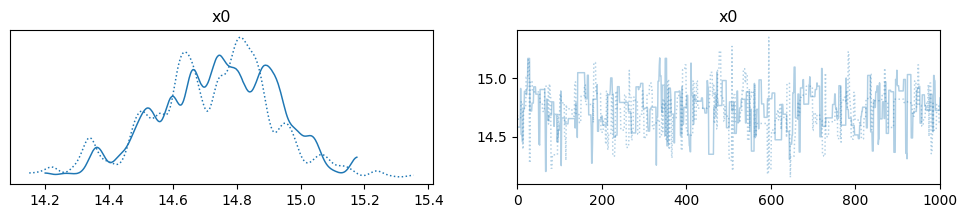

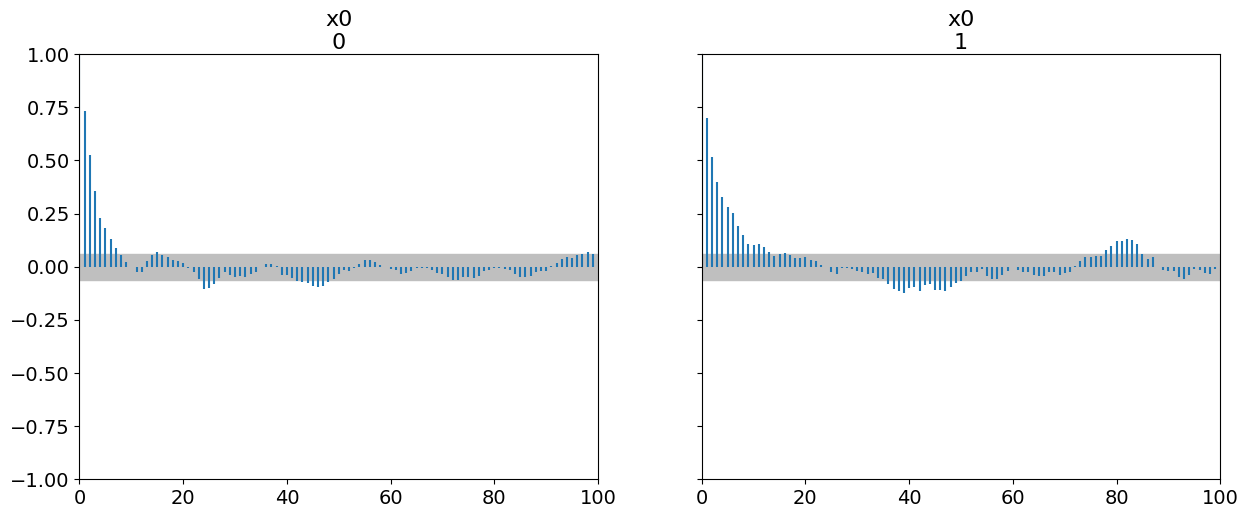

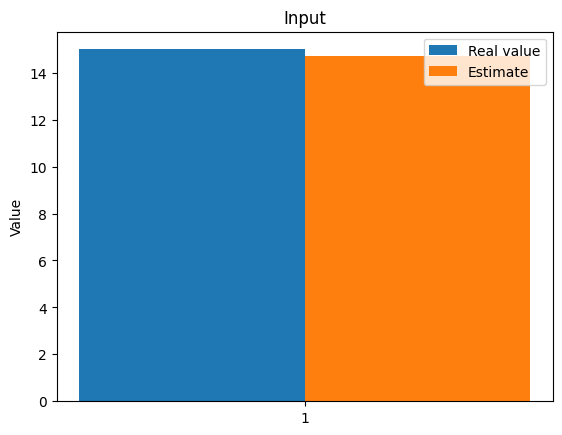

The function param_inverse took 1037.0904257297516 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [08:29<00:00,  5.89it/s]


Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 3000/3000 [08:31<00:00,  5.86it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.742]
      mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.742  0.2  14.379   15.109      0.011    0.008     351.0     230.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.258]



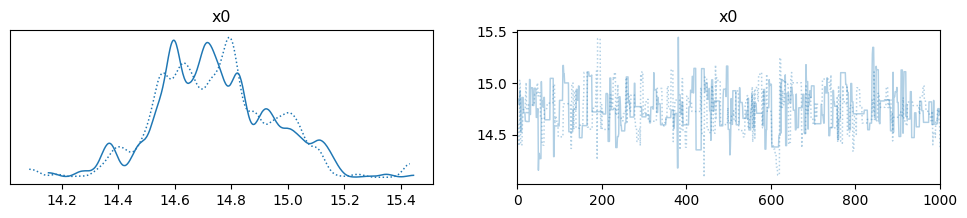

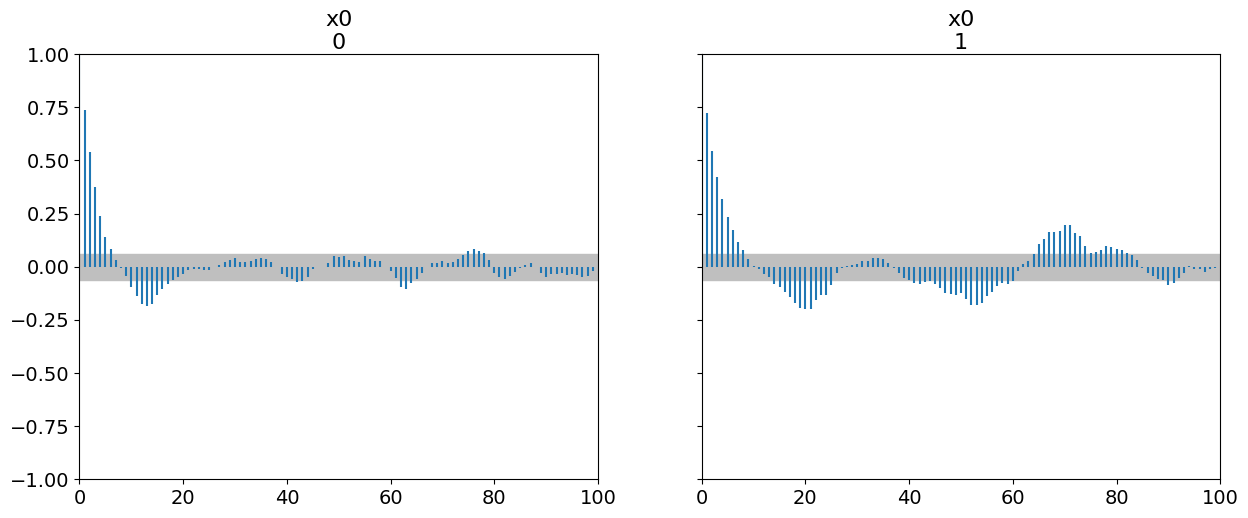

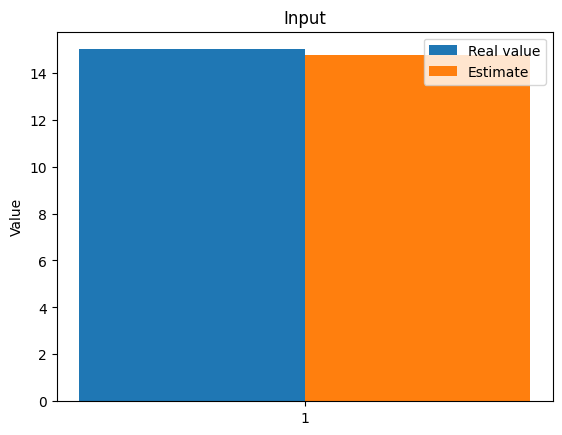

The function param_inverse took 1022.4821774959564 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [08:35<00:00,  5.82it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 3000/3000 [08:34<00:00,  5.83it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [13.963]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  13.963  0.376  13.321   14.772      0.023    0.016     266.0     335.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.037]



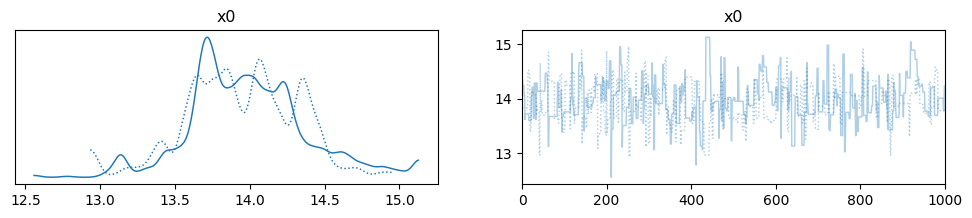

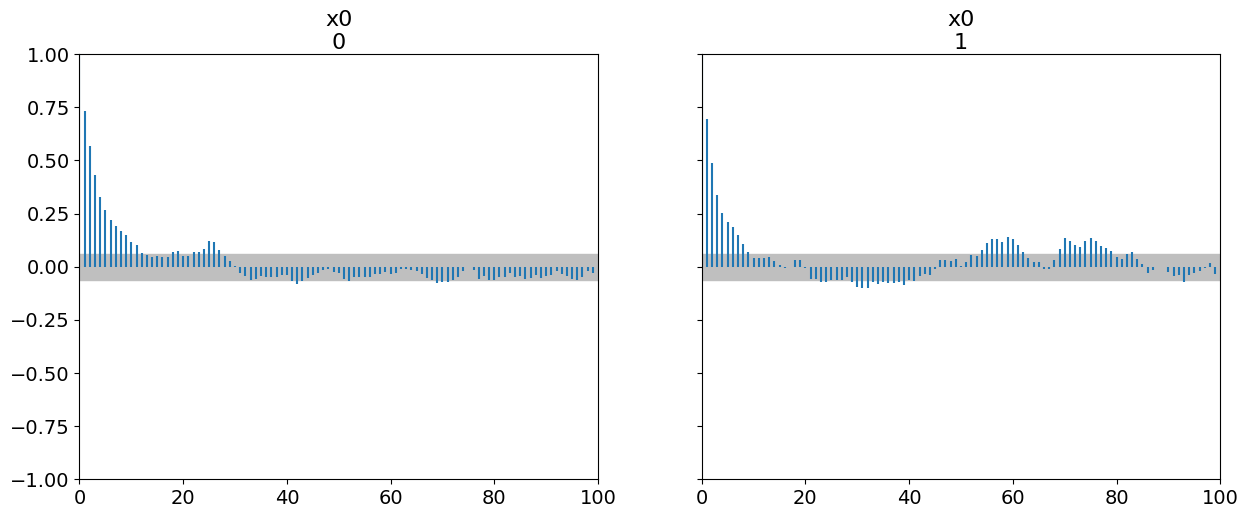

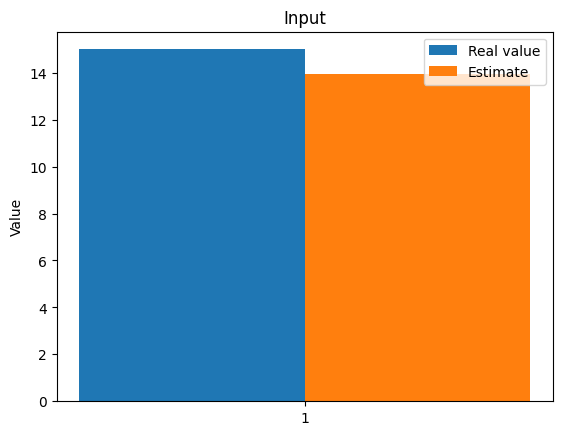

The function param_inverse took 1031.2187173366547 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [08:33<00:00,  5.85it/s]


Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [08:35<00:00,  5.82it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [13.941]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  13.941  0.396  13.205   14.628      0.023    0.017     296.0     246.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.059]



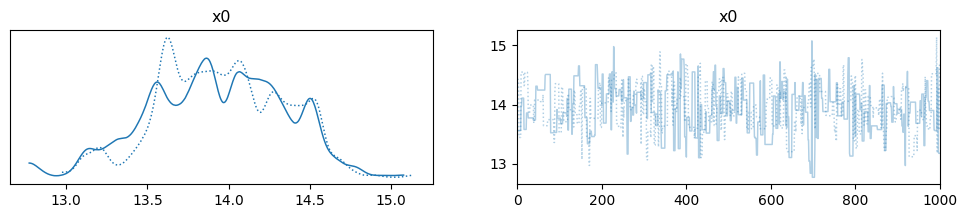

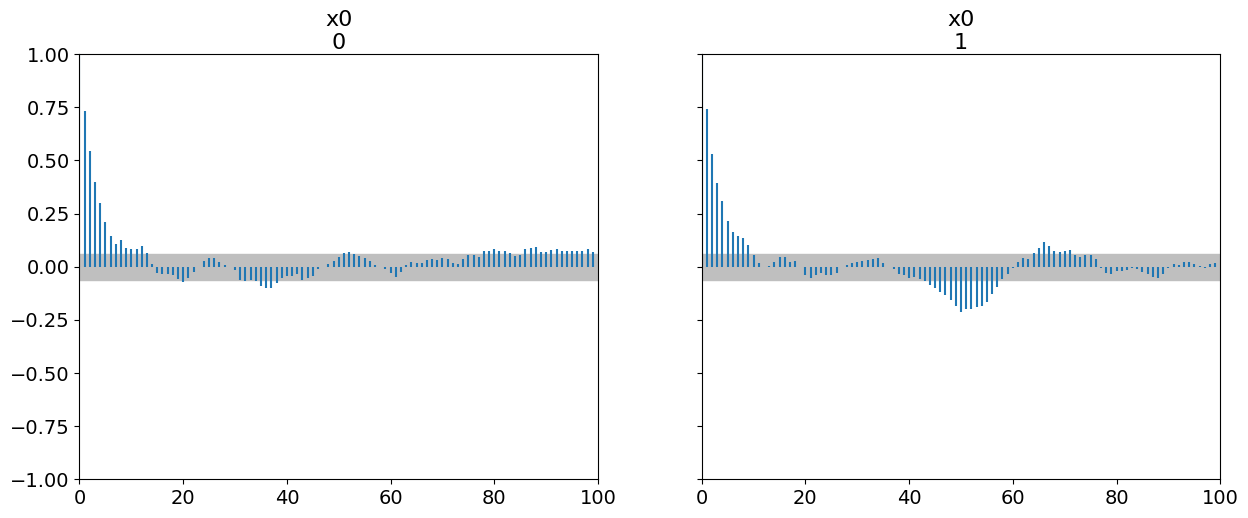

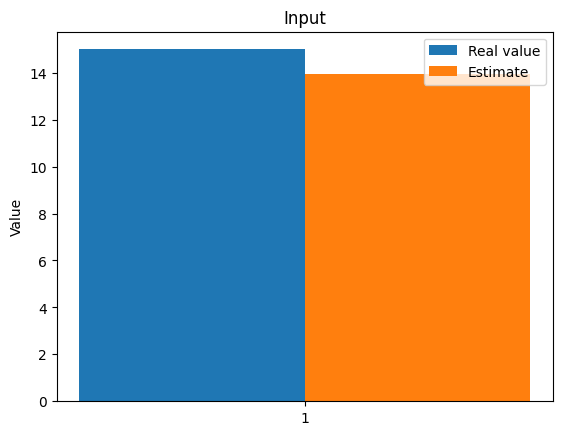

The function param_inverse took 1029.9887807369232 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.34: 100%|██████████| 3000/3000 [08:59<00:00,  5.56it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [08:56<00:00,  5.59it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [13.918]
      mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  13.918  0.39  13.219   14.626      0.022    0.015     320.0     386.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [1.082]



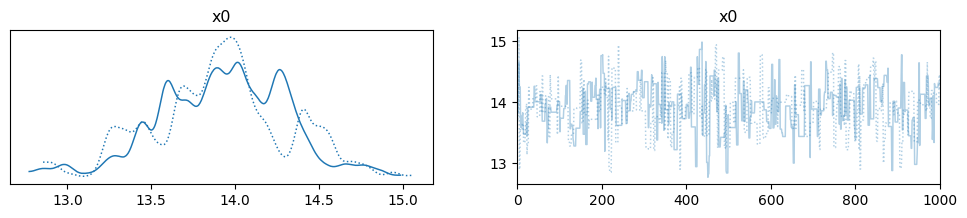

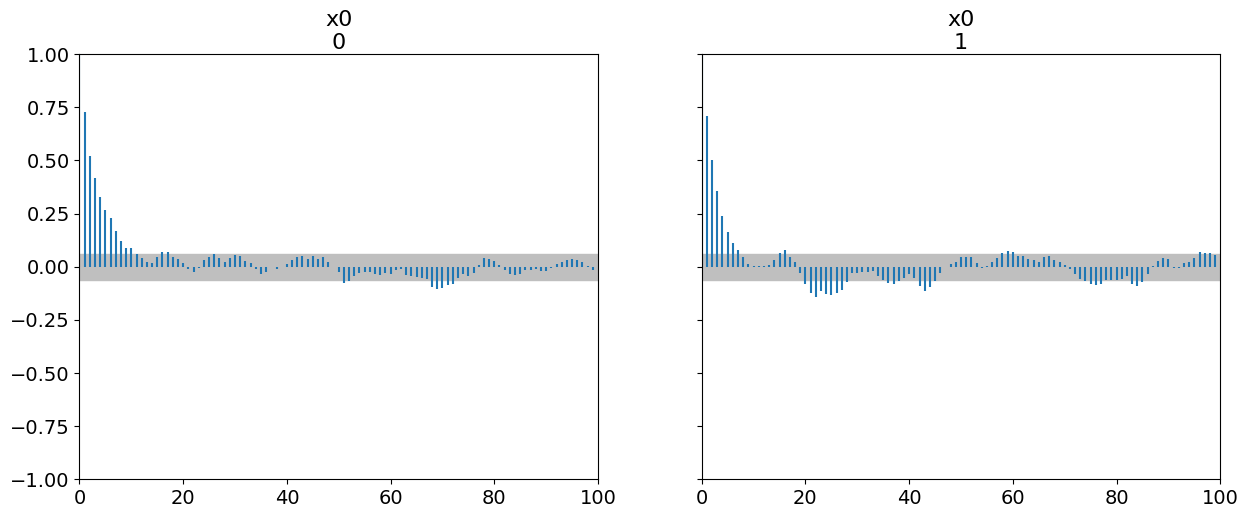

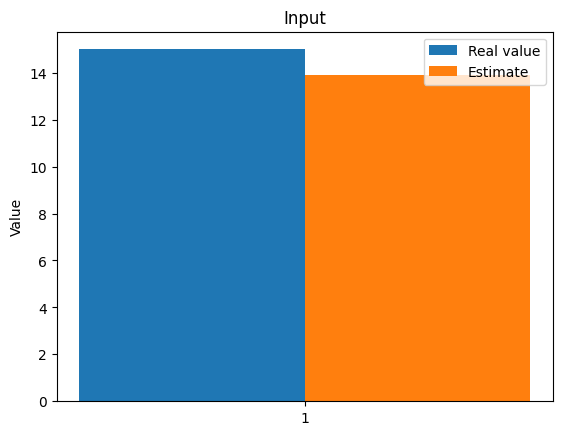

The function param_inverse took 1077.4977700710297 seconds.
Number of data: 50
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [05:22<00:00,  9.30it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 3000/3000 [06:10<00:00,  8.09it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.844]
      mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.844  0.15  14.585   15.125      0.009    0.006     308.0     380.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.156]



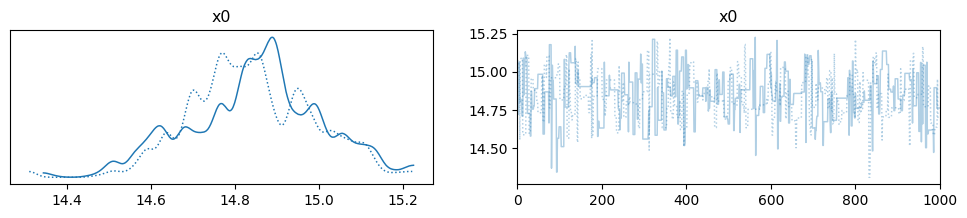

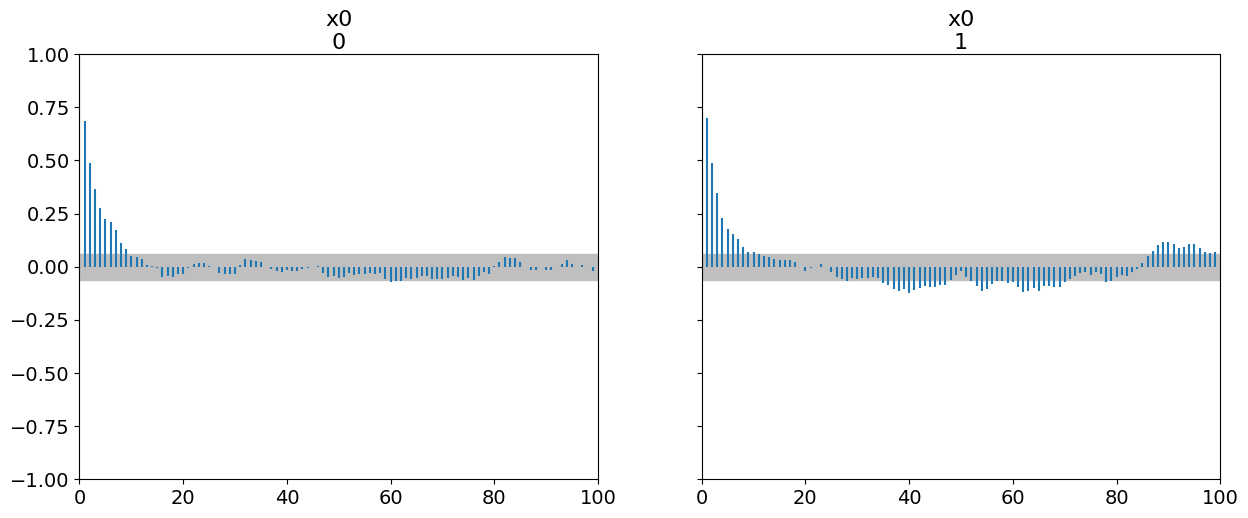

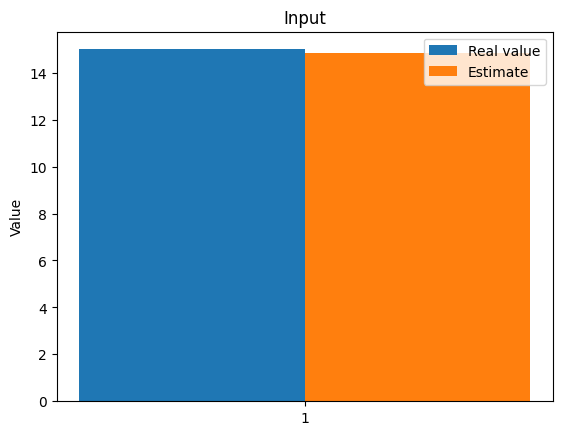

The function param_inverse took 694.2863862514496 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:53<00:00, 10.21it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:52<00:00, 10.27it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.835]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.835  0.148   14.55    15.09       0.01    0.007     217.0     355.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [0.165]



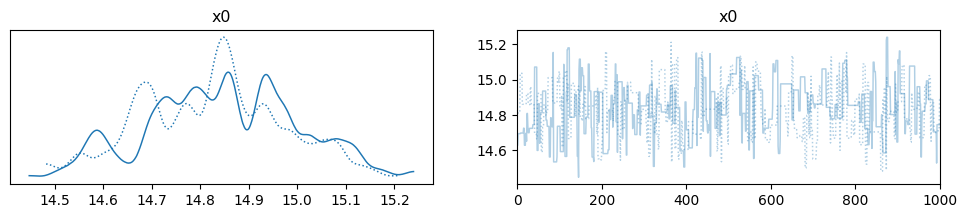

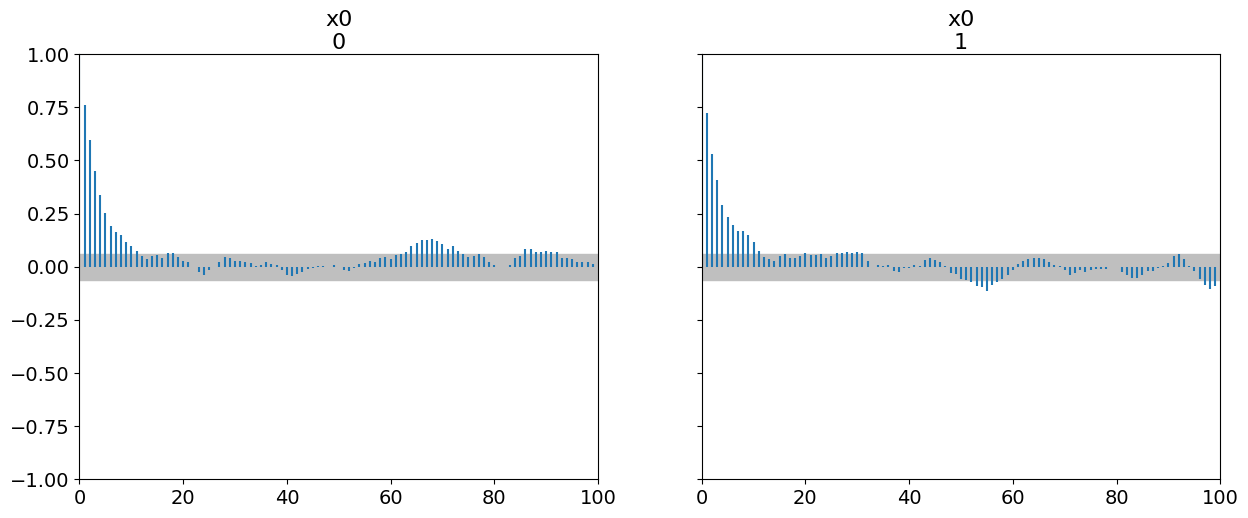

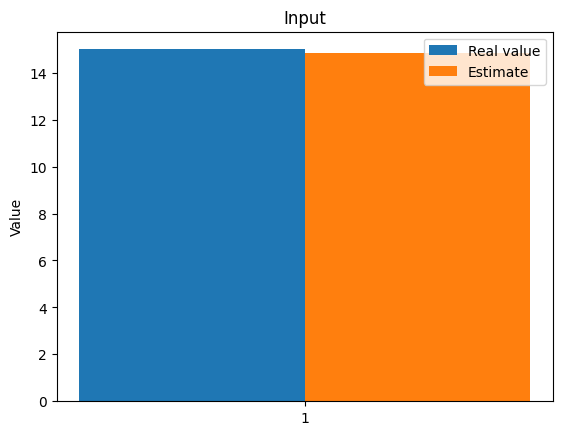

The function param_inverse took 586.9213669300079 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.27:   0%|          | 9/3000 [00:01<04:59,  9.98it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.25: 100%|██████████| 3000/3000 [04:59<00:00, 10.01it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [04:56<00:00, 10.11it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.851]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.851  0.139  14.616   15.121      0.009    0.006     262.0     365.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.149]



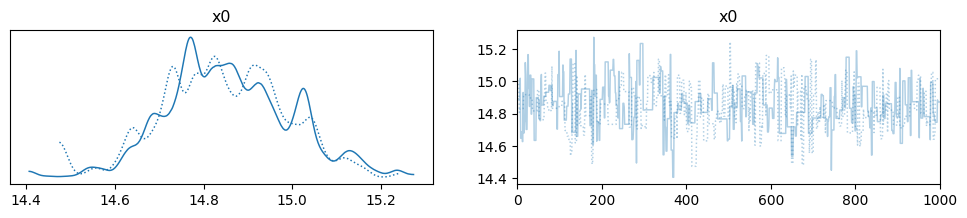

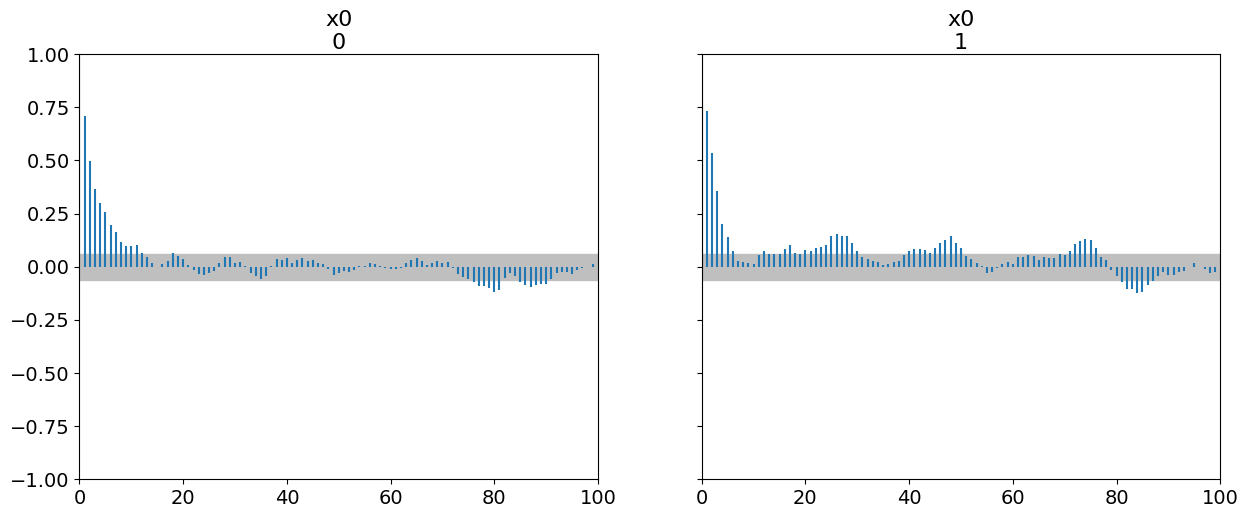

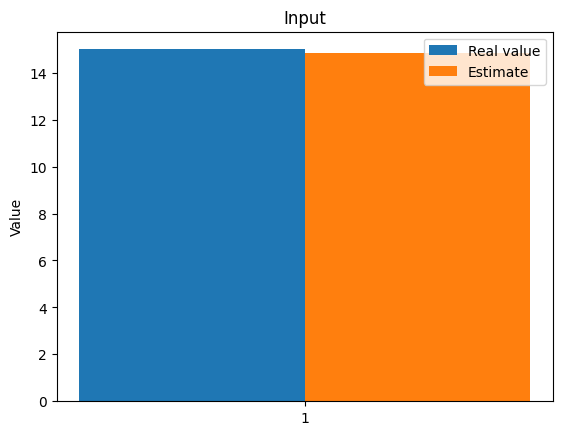

The function param_inverse took 597.2299461364746 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [04:54<00:00, 10.18it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:53<00:00, 10.21it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.371]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.371  0.262  13.884     14.9      0.014     0.01     353.0     337.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [0.629]



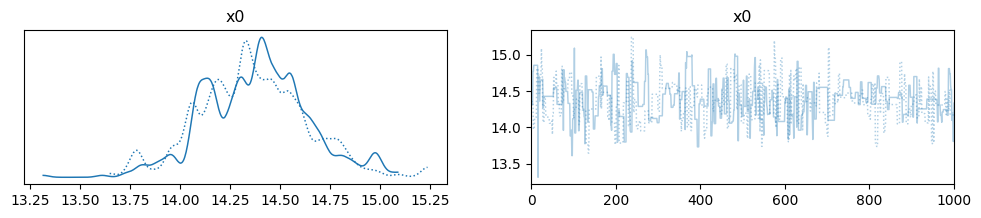

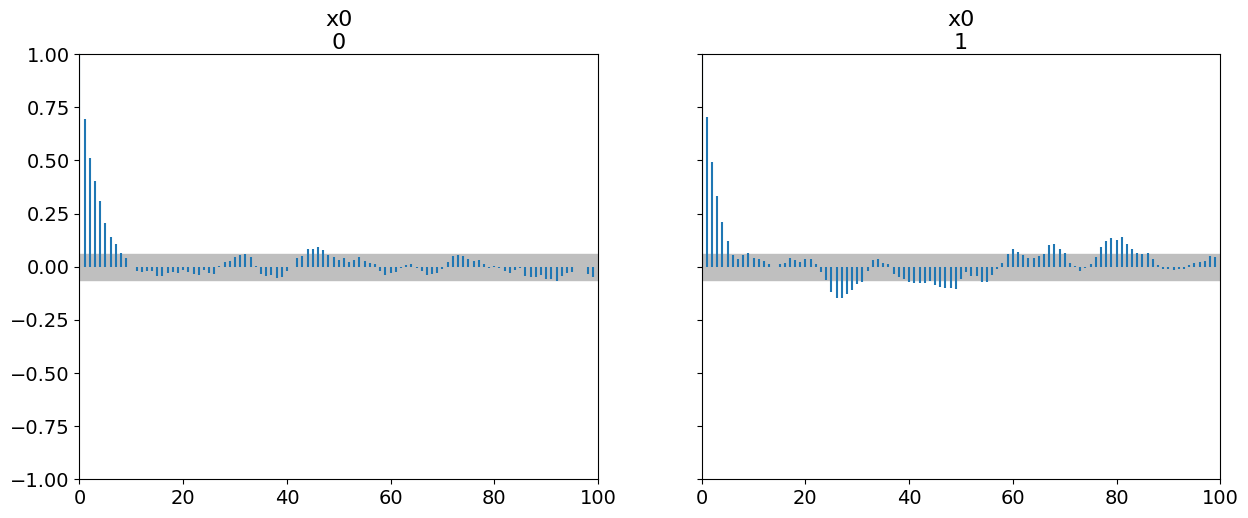

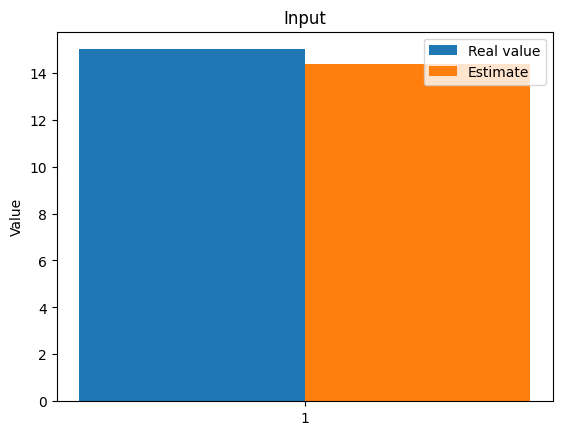

The function param_inverse took 589.3838033676147 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:54<00:00, 10.17it/s]


Sampling chain 2/2


Running chain, α = 0.32: 100%|██████████| 3000/3000 [04:55<00:00, 10.16it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.385]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.385  0.283  13.871   14.878      0.016    0.011     312.0     351.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.615]



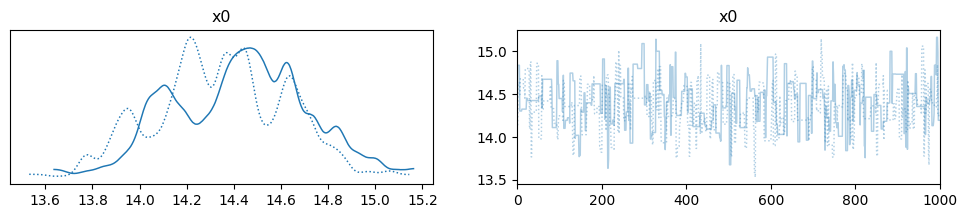

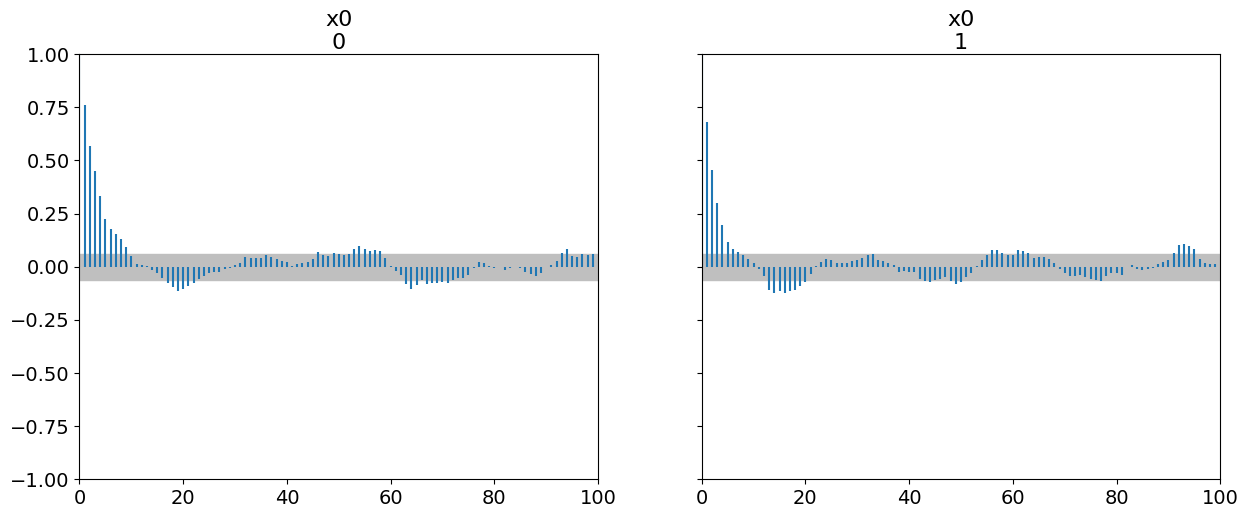

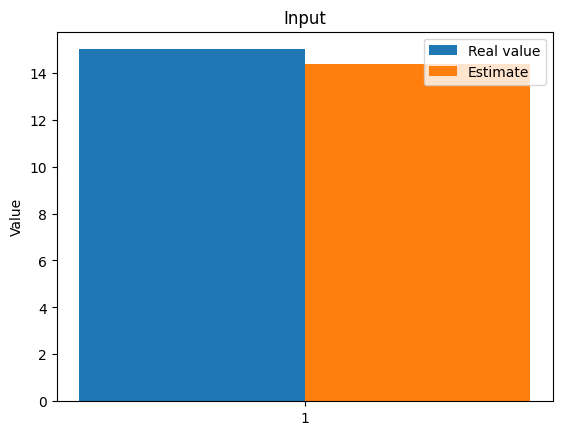

The function param_inverse took 591.0902268886566 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:52<00:00, 10.26it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 3000/3000 [04:49<00:00, 10.37it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.378]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.378  0.269   13.86   14.867      0.017    0.012     250.0     322.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.622]



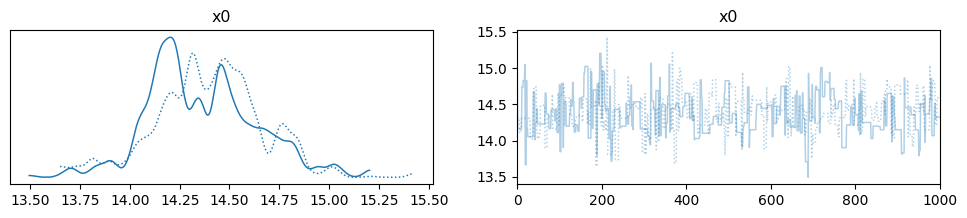

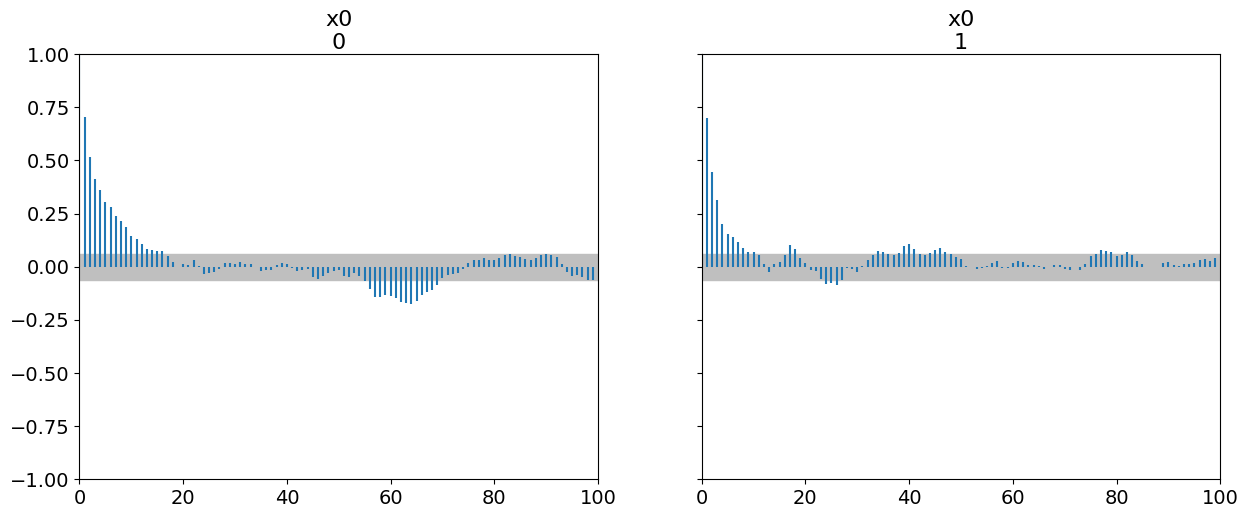

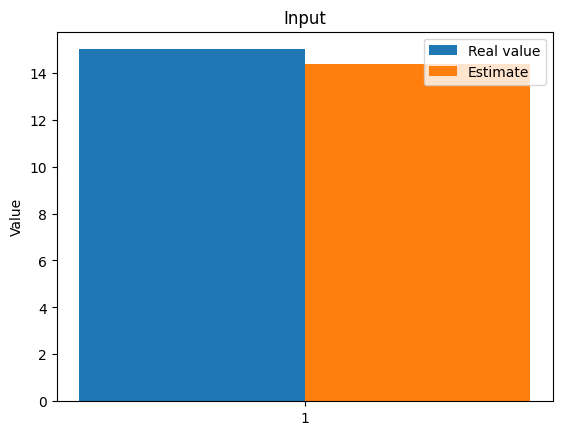

The function param_inverse took 582.4477415084839 seconds.
The best estimate is given by: sigma_noise=0.05, number of data= 30, sigma=2.0, rmwh_scaling=0.5
Noise: 0.05
Number of data: 30
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 3000/3000 [04:44<00:00, 10.53it/s]


Sampling chain 2/2


Running chain, α = 0.31: 100%|██████████| 3000/3000 [05:06<00:00,  9.80it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.741]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.741  0.177  14.418   15.065      0.011    0.008     257.0     326.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.259]



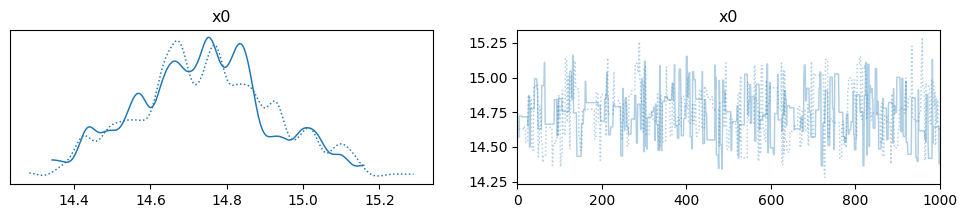

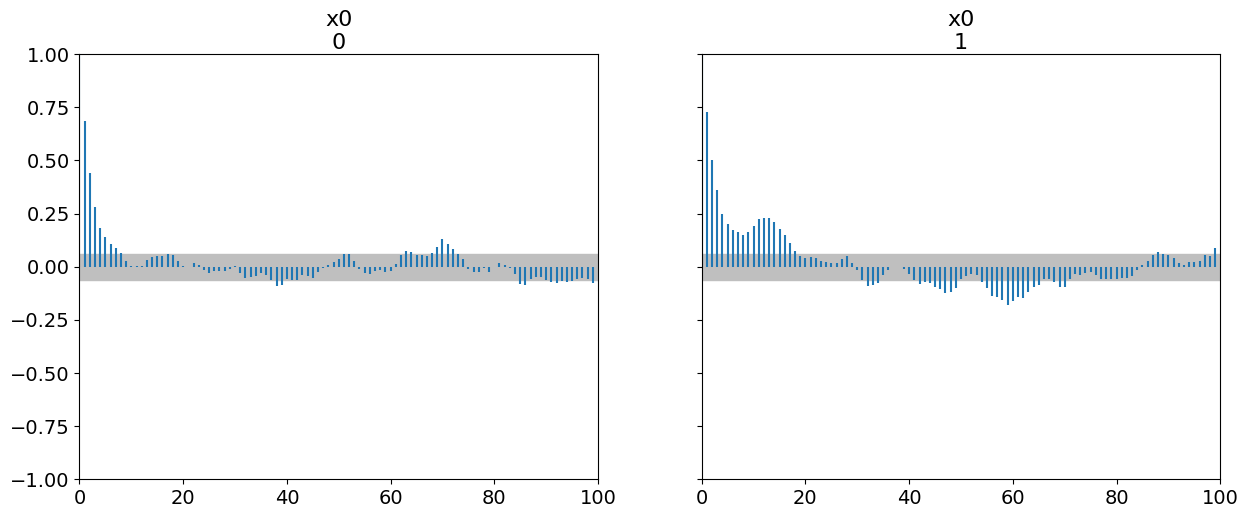

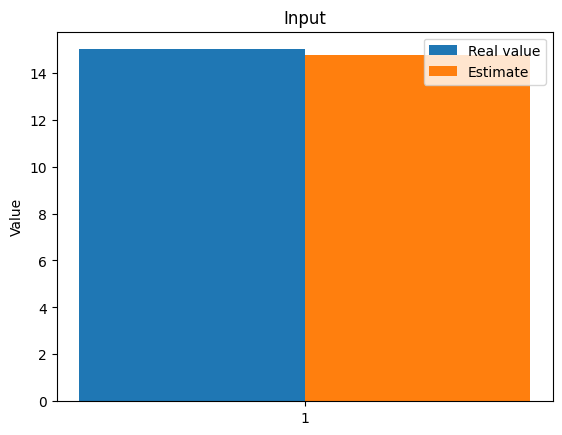

The function param_inverse took 591.7797775268555 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.31: 100%|██████████| 3000/3000 [05:46<00:00,  8.67it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [04:41<00:00, 10.65it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.733]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.733  0.219  14.348   15.138      0.012    0.009     320.0     251.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.267]



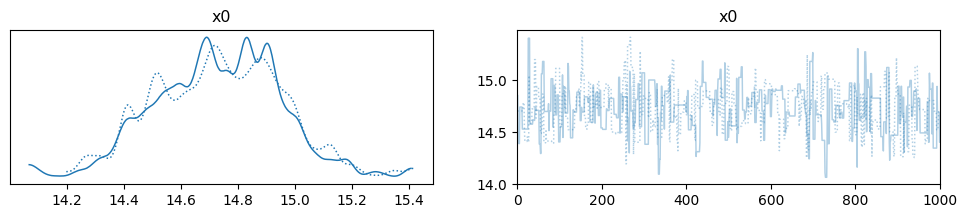

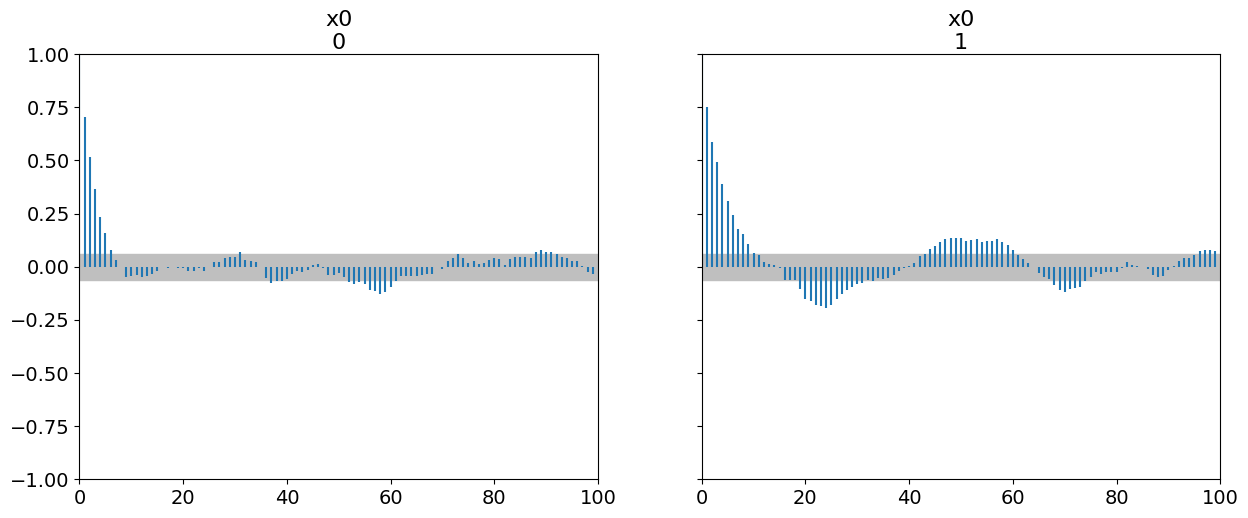

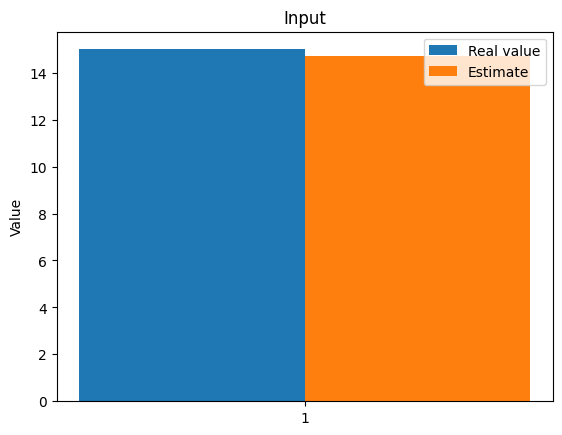

The function param_inverse took 628.6690509319305 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.33: 100%|██████████| 3000/3000 [04:43<00:00, 10.59it/s]


Sampling chain 2/2


Running chain, α = 0.32: 100%|██████████| 3000/3000 [04:40<00:00, 10.69it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.737]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.737  0.179  14.406   15.057       0.01    0.007     356.0     375.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.263]



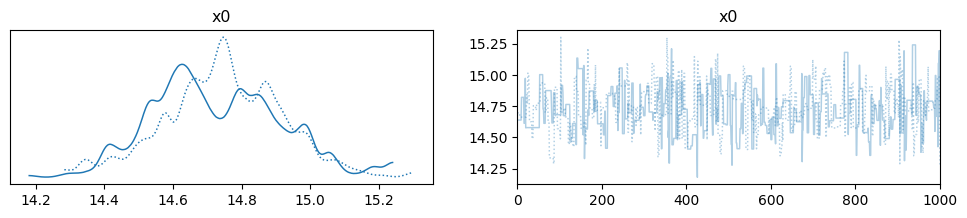

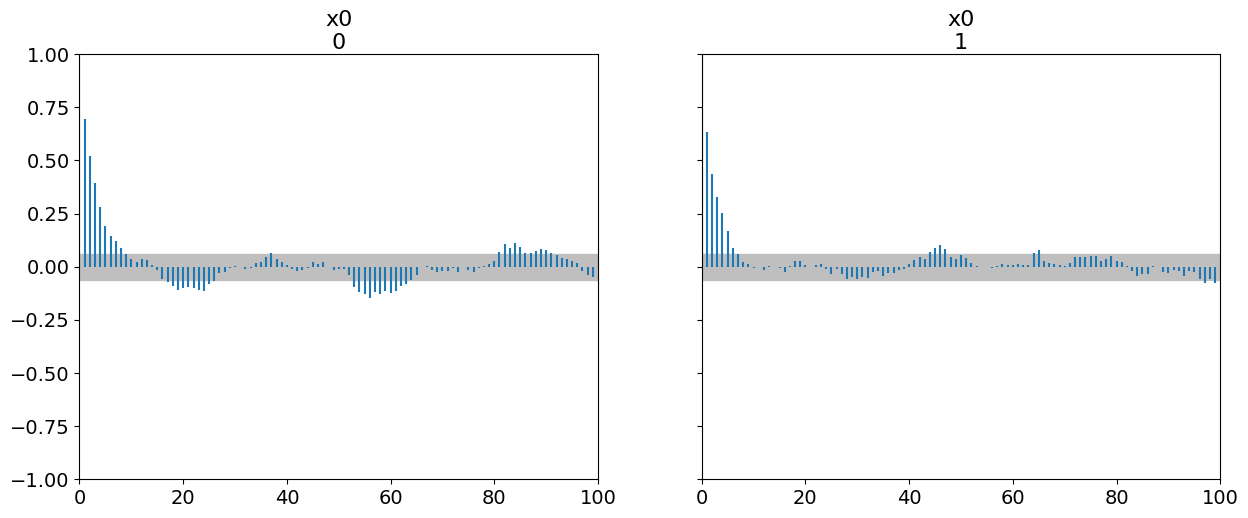

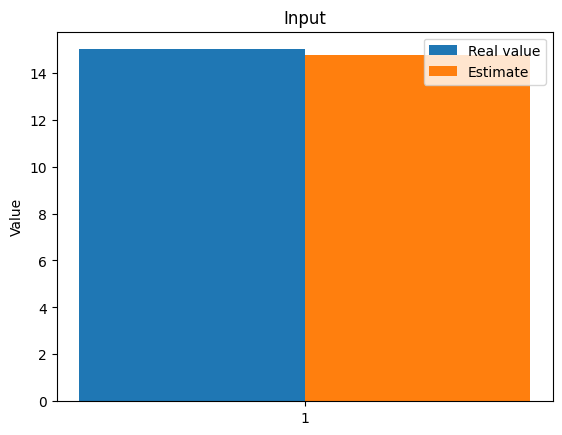

The function param_inverse took 564.7655432224274 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 3000/3000 [04:47<00:00, 10.43it/s]


Sampling chain 2/2


Running chain, α = 0.13: 100%|██████████| 3000/3000 [04:49<00:00, 10.36it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [13.986]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  13.986  0.396  13.282   14.752      0.021    0.015     358.0     275.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.014]



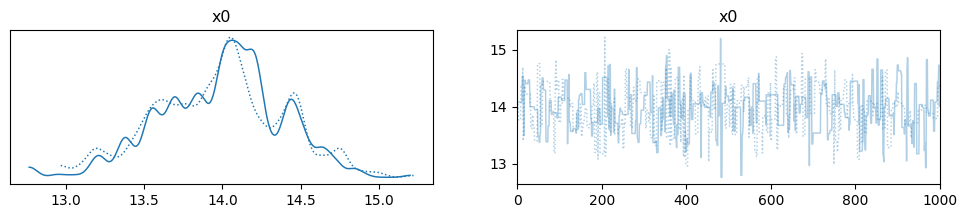

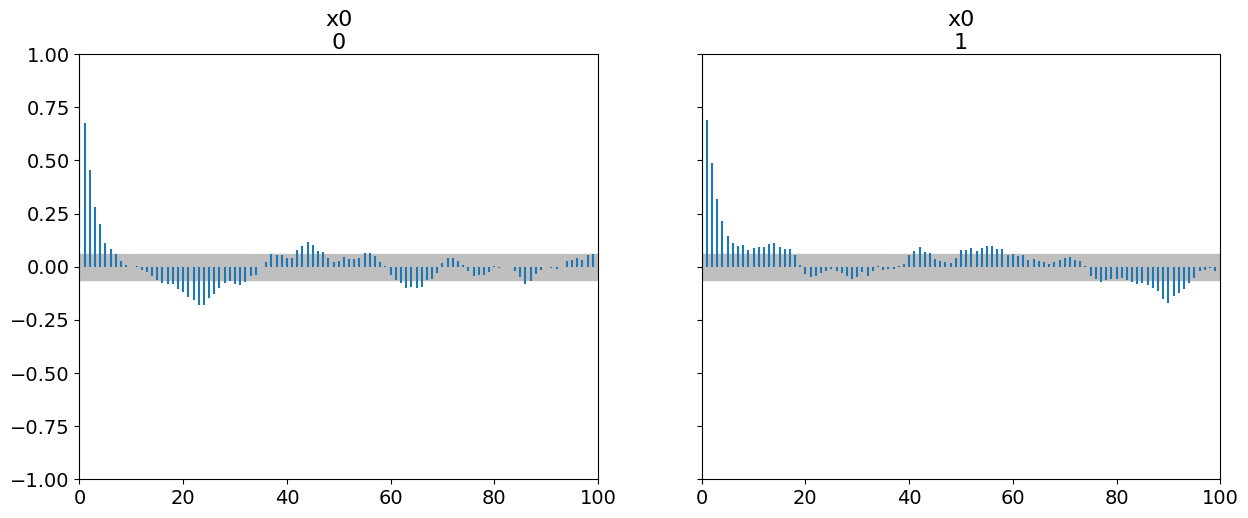

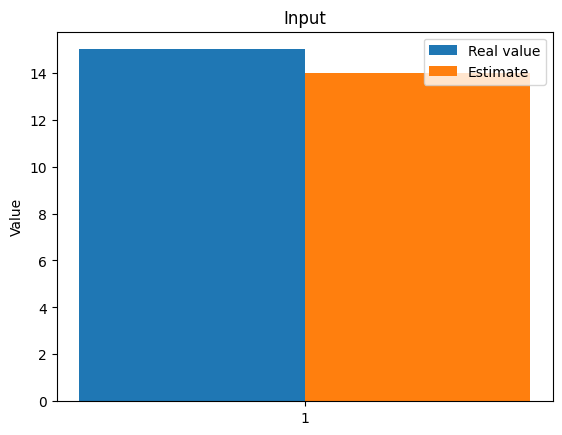

The function param_inverse took 578.0736691951752 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.26: 100%|██████████| 3000/3000 [04:46<00:00, 10.48it/s]


Sampling chain 2/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [06:56<00:00,  7.20it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [13.912]
      mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  13.912  0.4  13.195   14.706       0.02    0.014     397.0     365.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [1.088]



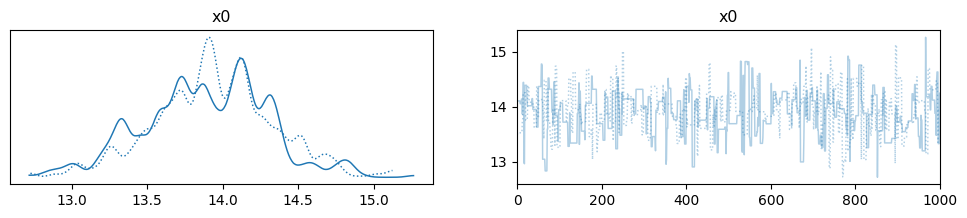

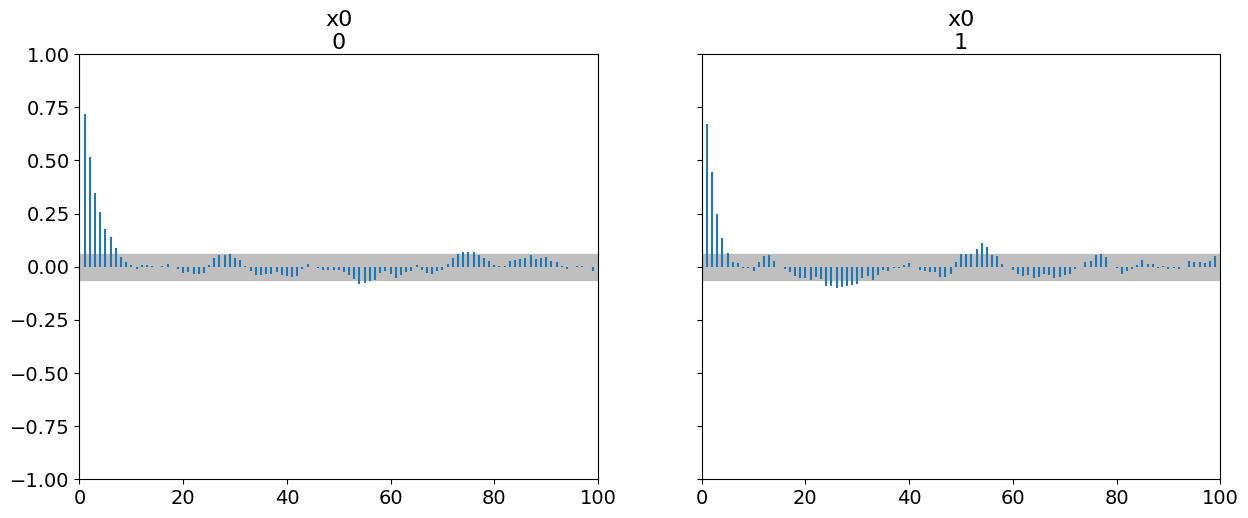

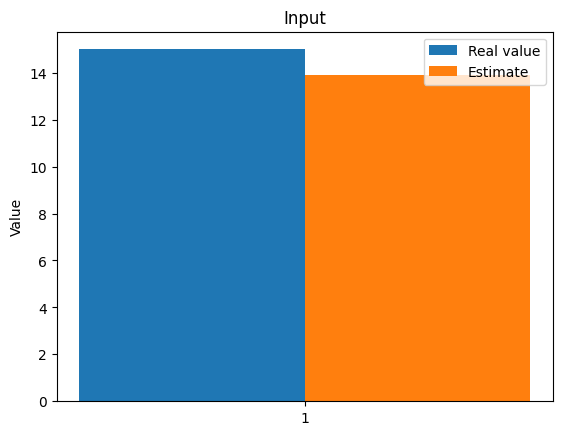

The function param_inverse took 704.1929104328156 seconds.
(30,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [05:40<00:00,  8.81it/s]


Sampling chain 2/2


Running chain, α = 0.09: 100%|██████████| 3000/3000 [05:07<00:00,  9.75it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [13.929]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  13.929  0.373  13.274   14.653      0.022    0.015     303.0     272.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [1.071]



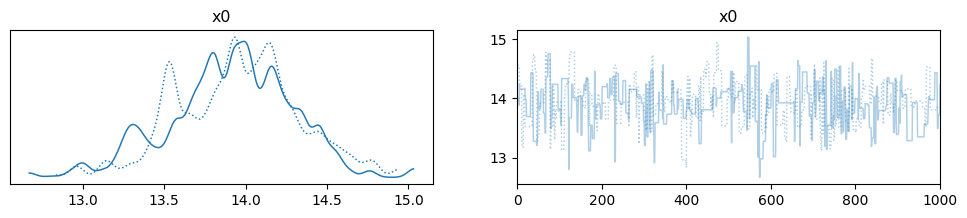

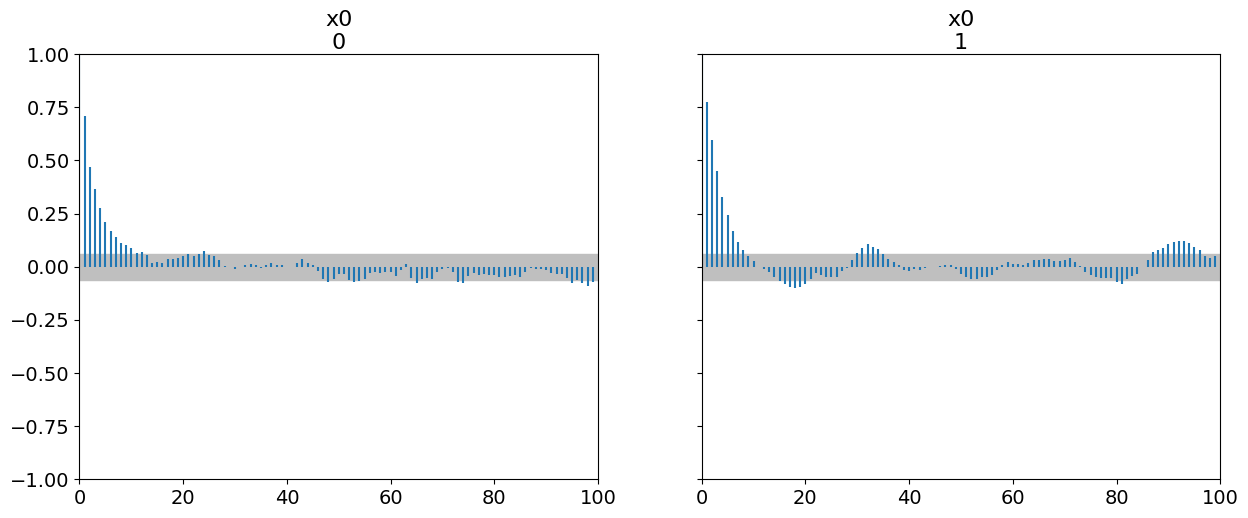

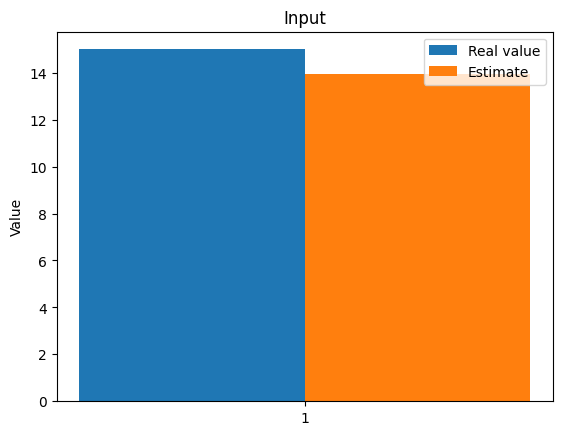

The function param_inverse took 649.1266751289368 seconds.
Number of data: 50
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.28: 100%|██████████| 3000/3000 [05:17<00:00,  9.45it/s]


Sampling chain 2/2


Running chain, α = 0.16: 100%|██████████| 3000/3000 [05:14<00:00,  9.55it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.849]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.849  0.153  14.565   15.144      0.008    0.006     342.0     370.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.151]



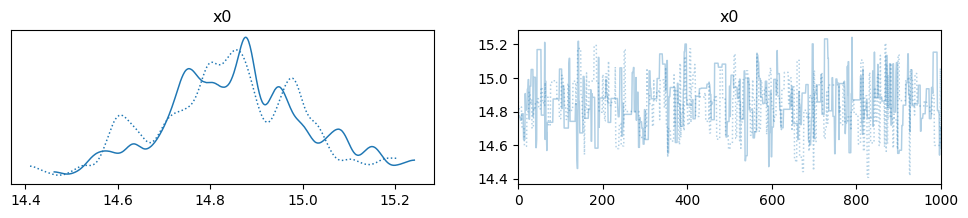

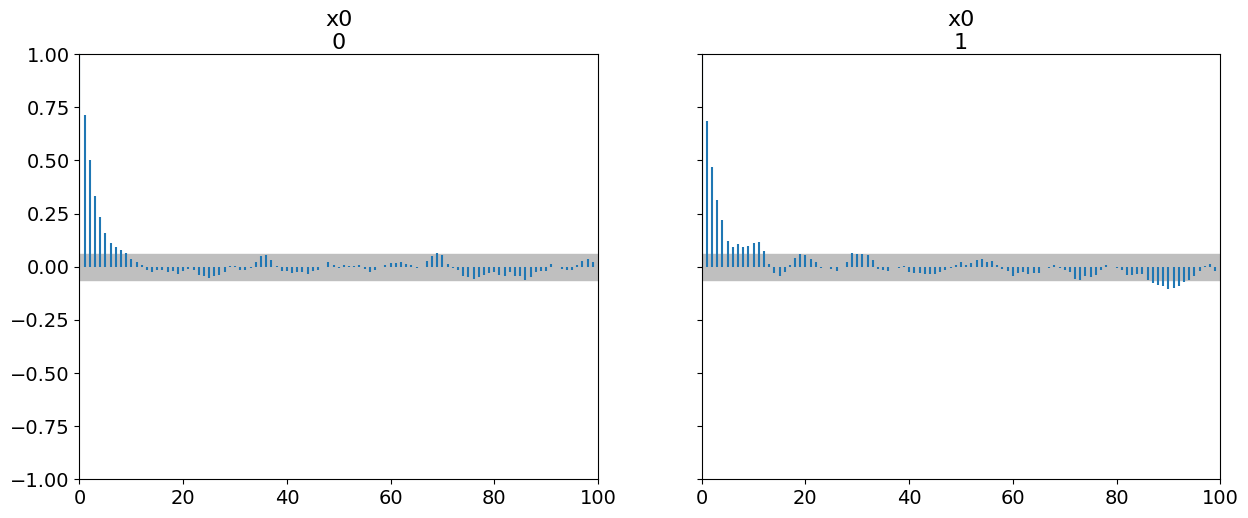

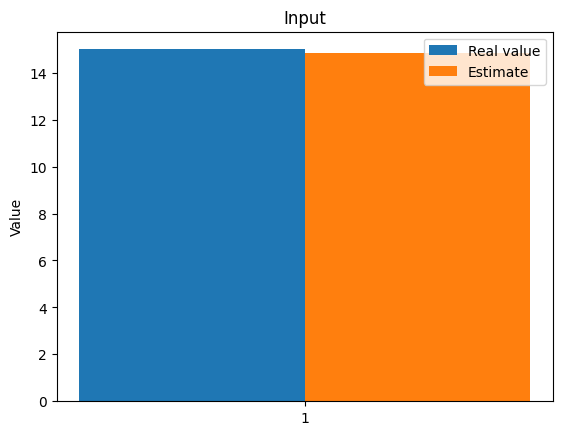

The function param_inverse took 632.4932754039764 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [05:26<00:00,  9.18it/s]


Sampling chain 2/2


Running chain, α = 0.18: 100%|██████████| 3000/3000 [05:13<00:00,  9.56it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.857]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.857  0.143  14.612   15.133      0.009    0.006     275.0     271.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.143]



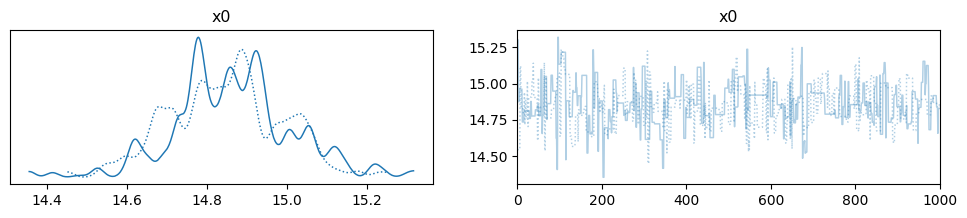

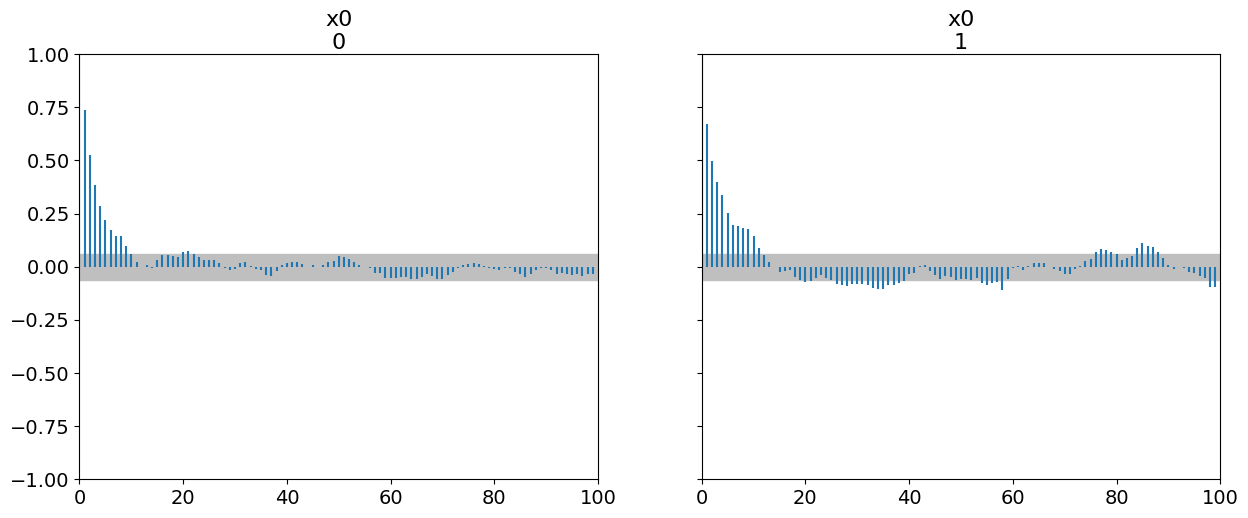

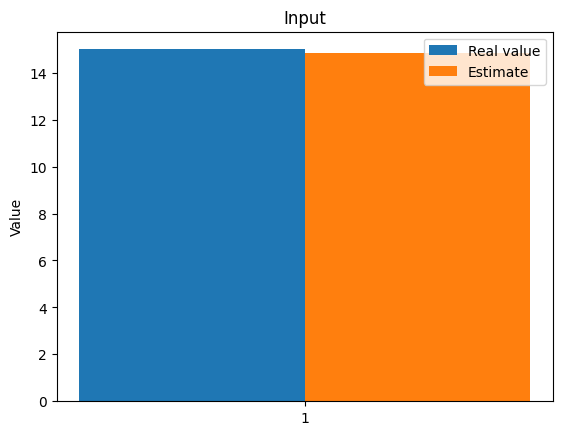

The function param_inverse took 641.7752952575684 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.67:   0%|          | 2/3000 [00:00<15:14,  3.28it/s]C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.20: 100%|██████████| 3000/3000 [05:44<00:00,  8.71it/s]


Sampling chain 2/2


Running chain, α = 0.31: 100%|██████████| 3000/3000 [05:24<00:00,  9.24it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [14.855]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.855  0.142  14.594   15.123      0.008    0.006     297.0     296.0   

    r_hat  
x0   1.02  
Autocorrelation...
the difference between estimated values [0.145]



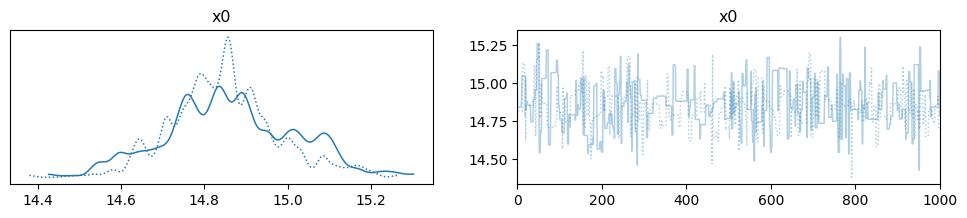

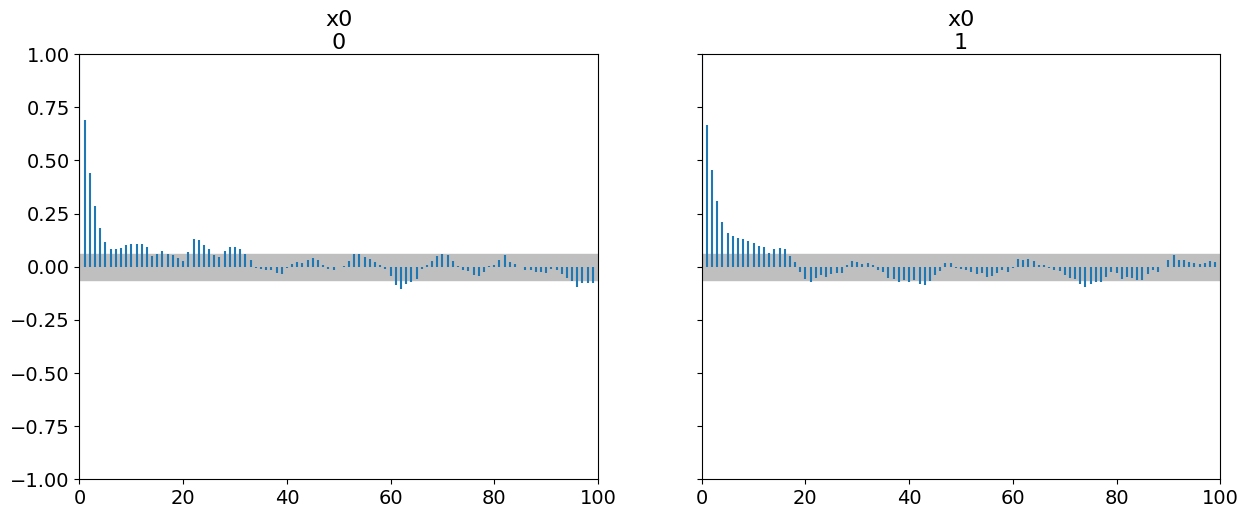

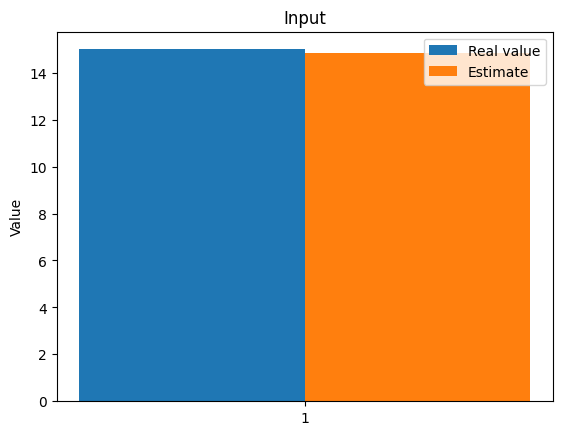

The function param_inverse took 670.2431304454803 seconds.
(50,)
real values are [15.]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 3000/3000 [05:31<00:00,  9.04it/s]


Sampling chain 2/2


Running chain, α = 0.28:  46%|████▌     | 1382/3000 [02:44<03:12,  8.42it/s]


KeyboardInterrupt: 

In [10]:
# true parameters
sigma_noise=[0.1,0.05]
n_data=[30,50]
parameters=np.array([15.])
indices = np.where(datahf[:,1] == parameters)[0]  # useless, delete
mean_prior=np.array([7.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,1.,2.])
rwmh_adaptive = True
iterations =3000
burnin = 2000
n_chains=2

algo="MH"


estimateLF, errorLF= run_simulation(datahf, mean_prior, cov_prior, params["Yhf"], sigma_noise, n_data, parameters, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
estimateHF, errorHF= run_simulation(datahf, mean_prior, cov_prior, params["Yhf"], sigma_noise, n_data, parameters, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)

estimateMF, errorMF= run_simulation(datahf, mean_prior, cov_prior, params["Yhf"], sigma_noise, n_data, parameters, sigma, rmwh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)
